DATA TRANSFORMATION
--------------------

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


billing = pd.read_excel("1_Billing.xlsx")
billing.to_csv("1_Billing.csv", index=False)

resource = pd.read_excel("2_Resource_Inventory.xlsx")
resource.to_csv("2_Resource.csv", index=False)

incidents = pd.read_excel("3_Incidents.xlsx")
incidents.to_csv("3_Incidents.csv", index=False)

tickets = pd.read_excel("4_Support_Tickets.xlsx")
tickets.to_csv("4_Support_Tickets.csv", index=False)

finance = pd.read_excel("5_Customer_Finance.xlsx")
finance.to_csv("5_Customer_Finance.csv", index=False)

security = pd.read_excel("6_Security_Logs.xlsx")
security.to_csv("6_Security_Logs.csv", index=False)




plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

TC 1 : Daily and monthly cost/usage cubes (service, SKU, region).
-----------------------------------------------------------

In [2]:
# Convert timestamps to datetime objects
billing["TS"] = pd.to_datetime(billing["TS"])

In [3]:
billing["Date"] = billing["TS"].dt.date

billing["Month"] = billing["TS"].dt.to_period("M").astype(str)

In [4]:
billing = billing.merge(
    resource[["Resource_ID", "Region"]],
    on="Resource_ID",
    how="left"
)

In [5]:
# Daily cost cube and monthly cost cube
daily_cost_cube = (
    billing
    .groupby(
        ["Date","Service","SKU","Region"],
        as_index=False
    )
    .agg(
        Daily_Cost=("Cost","sum"),
        Daily_Usage=("Usage","sum")
    )
)

monthly_cost_cube = (
    billing
    .groupby(
        ["Month","Service","SKU","Region"],
        as_index=False
    )
    .agg(
        Monthly_Cost=("Cost","sum"),
        Monthly_Usage=("Usage","sum")
    )
)



print(daily_cost_cube.head())

print(monthly_cost_cube.head())


         Date  Service    SKU      Region Daily_Cost  Daily_Usage
0  2026-01-01  Compute  SKU10  ap-south-1    2249.84        28123
1  2026-01-01  Compute  SKU15   eu-west-1    3849.52        48119
2  2026-01-01  Compute   SKU4  ap-south-1       74.8          935
3  2026-01-01  Compute   SKU8   us-east-1     238.88         2986
4  2026-01-01  Network  SKU20   eu-west-1    2149.76        26872
     Month  Service    SKU      Region Monthly_Cost  Monthly_Usage
0  2026-01  Compute   SKU1  ap-south-1      3087.44          38593
1  2026-01  Compute  SKU10  ap-south-1      5578.64          69733
2  2026-01  Compute  SKU10   eu-west-1      3127.68          39096
3  2026-01  Compute  SKU10   us-east-1      3205.28          40066
4  2026-01  Compute  SKU11   us-east-1      3343.44          41793


In [6]:
# Converting cost to numeric values for analysis
billing["Cost"] = ( billing["Cost"].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False))

billing["Cost"] = pd.to_numeric( billing["Cost"],errors="coerce")

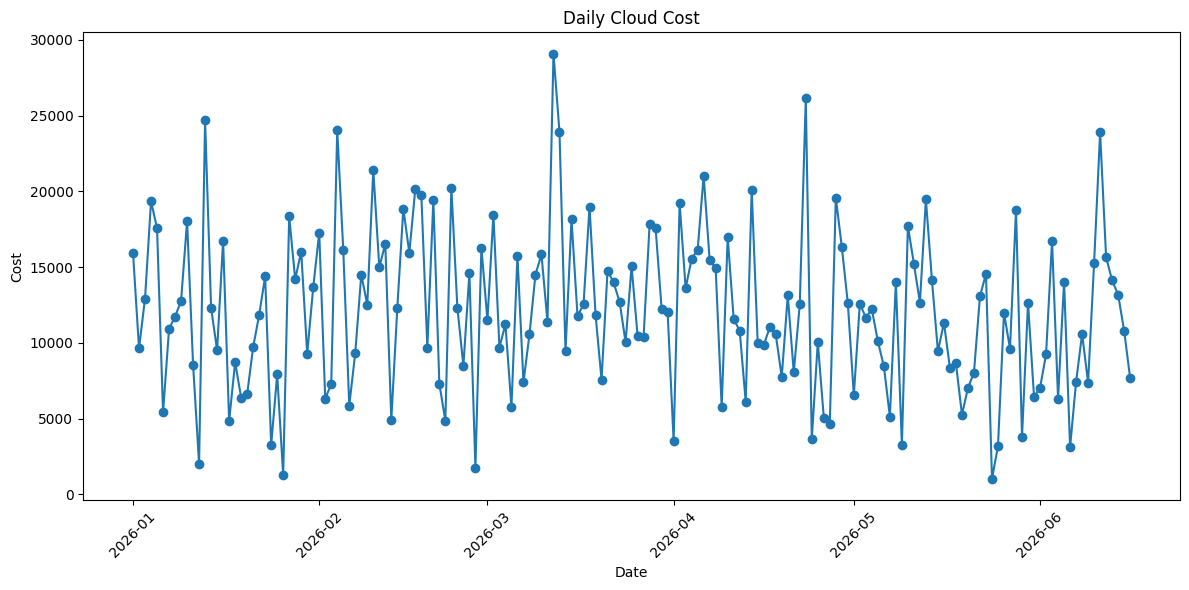

In [7]:
# Daily cost plot

daily_plot = ( billing.groupby("Date")["Cost"].sum() )

plt.figure(figsize=(12,6))

plt.plot( daily_plot.index,daily_plot.values,marker="o" )

plt.title("Daily Cloud Cost")

plt.xlabel("Date")

plt.ylabel("Cost")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [8]:
# Add monthly cost plot
billing["Month"] = pd.to_datetime(billing["TS"]).dt.to_period("M").astype(str)

In [9]:
# Converting cost to numeric values for analysis
billing["Cost"] = ( billing["Cost"].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False))

billing["Cost"] = pd.to_numeric( billing["Cost"],errors="coerce")

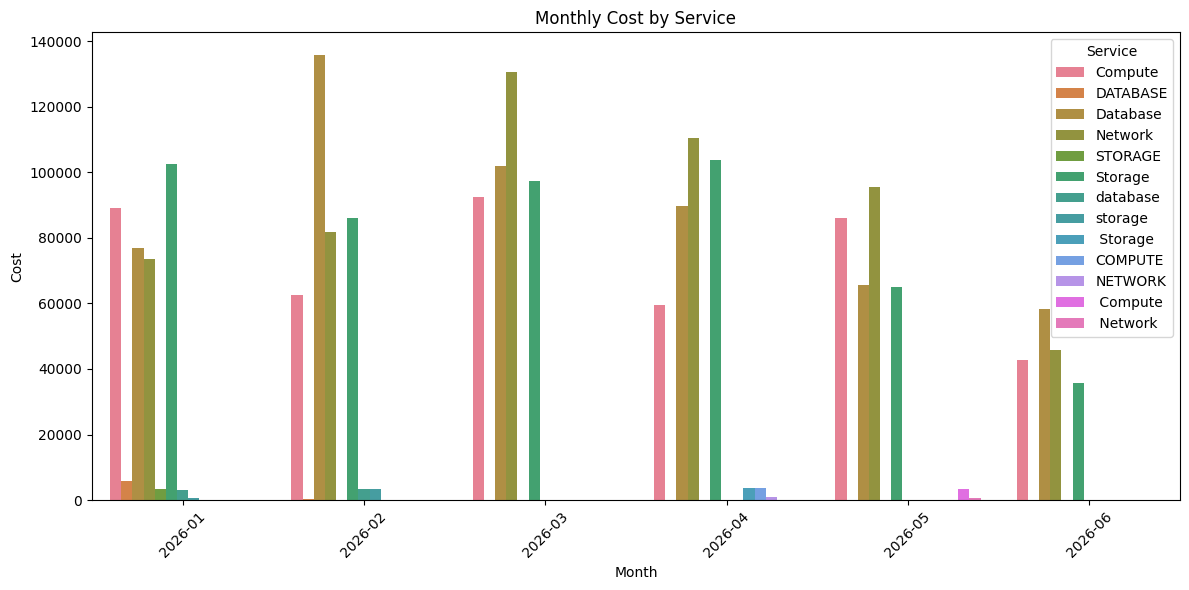

In [10]:
# MOnthly cost plot
monthly_service = ( billing.groupby( ["Month","Service"] )["Cost"].sum().reset_index())

plt.figure(figsize=(12,6))

sns.barplot( data=monthly_service,x="Month",y="Cost",hue="Service")

plt.title("Monthly Cost by Service")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

TC : 3  RI/Savings Plan utilization and coverage metrics.
-----------------------------------------------------------

In [11]:
np.random.seed(42)

billing["Purchase_Option"] = np.random.choice(
    ["On-Demand","Reserved","Savings Plan"],
    size=len(billing),
    p=[0.55,0.25,0.20]
)

In [12]:
billing["Covered_Usage"] = np.where(
    billing["Purchase_Option"]=="On-Demand",
    0,
    billing["Usage"]
)

ri_usage = billing.loc[
    billing["Purchase_Option"]=="Reserved",
    "Usage"
].sum()

sp_usage = billing.loc[
    billing["Purchase_Option"]=="Savings Plan",
    "Usage"
].sum()

total_commitment = ri_usage + sp_usage

In [13]:
# Coverage
total_usage = billing["Usage"].sum()

coverage = ( total_commitment / total_usage) * 100

print(f"Coverage = {coverage:.2f}%")

Coverage = 44.08%


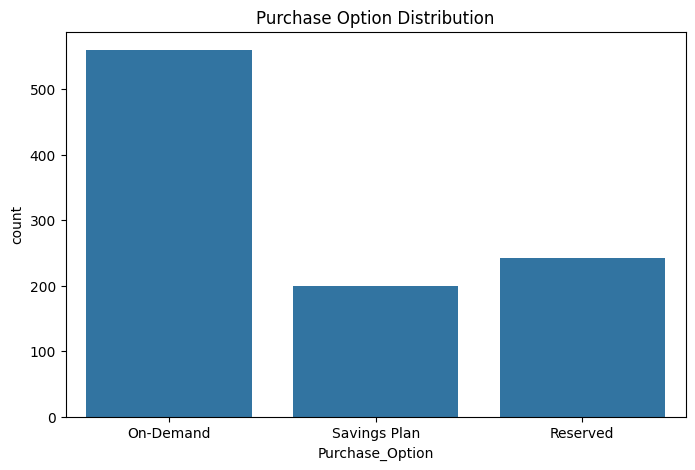

In [14]:
# Vsualizing the coverage.
plt.figure(figsize=(8,5))

sns.countplot( data=billing,x="Purchase_Option")

plt.title("Purchase Option Distribution")

plt.show()

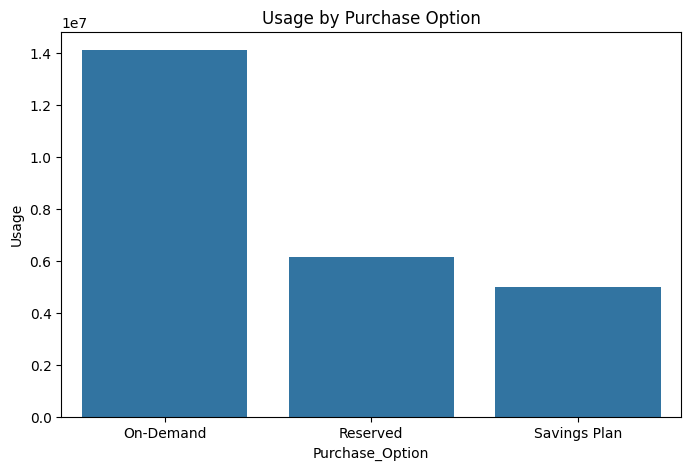

In [15]:
usage = billing.groupby( "Purchase_Option")["Usage"].sum().reset_index()

plt.figure(figsize=(8,5))

sns.barplot( data=usage, x="Purchase_Option", y="Usage" )

plt.title("Usage by Purchase Option")

plt.show()

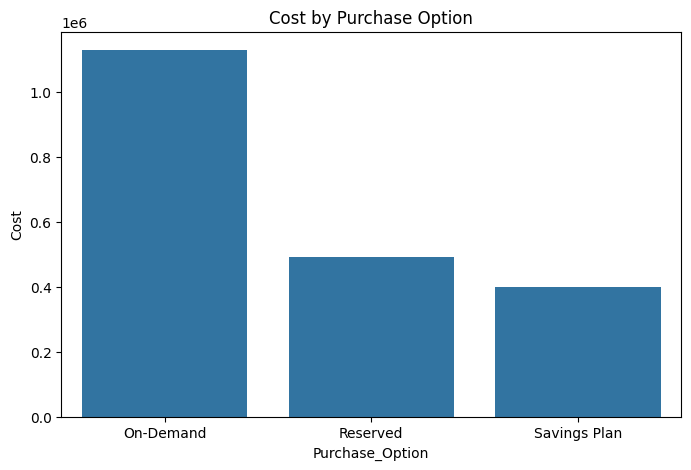

In [16]:
cost = billing.groupby( "Purchase_Option" )["Cost"].sum().reset_index()

plt.figure(figsize=(8,5))

sns.barplot( data=cost, x="Purchase_Option", y="Cost" )

plt.title("Cost by Purchase Option")

plt.show()

TC : 4  Idle/rightsizing recommendations features.
---------------------------------------------------

In [17]:
resource_cost = resource.merge( billing[["Resource_ID", "Cost", "Usage"]],on="Resource_ID",how="left")

In [18]:
required_columns = [ "CPU_Utilization","Memory_Utilization"]

if all(col in resource_cost.columns for col in required_columns):
    print("Utilization metrics available.")
else:
    print("Utilization metrics not available.")

Utilization metrics available.


In [19]:
# Rightsizing logic

if all(col in resource_cost.columns for col in required_columns):

    conditions = [
        resource_cost["CPU_Utilization"] < 5,
        resource_cost["CPU_Utilization"].between(5, 20),
        resource_cost["CPU_Utilization"] >= 20
    ]

    recommendations = [ "Stop / Terminate","Downsize Instance","Keep Current Size"]

    resource_cost["Rightsizing_Recommendation"] = np.select(
        conditions,
        recommendations,
        default="Review"
    )

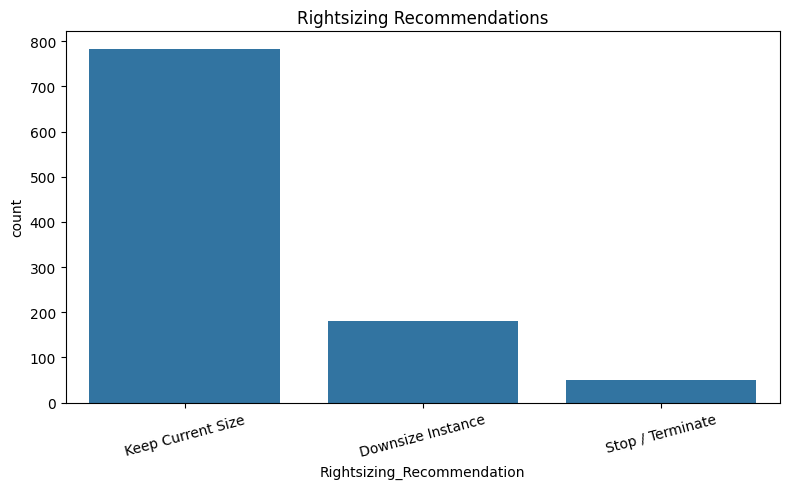

In [20]:
# visualizing the rightsizing.
if "Rightsizing_Recommendation" in resource_cost.columns:

    plt.figure(figsize=(8,5))

    sns.countplot(
        data=resource_cost,
        x="Rightsizing_Recommendation"
    )

    plt.title("Rightsizing Recommendations")

    plt.xticks(rotation=15)

    plt.tight_layout()

    plt.show()

Tc : 5 SRE KPIs: SLO/SLA attainment, error budgets.
----------------------------------------------------

In [21]:
print(incidents.columns)

Index(['Incident_ID', 'Resource_ID', 'Open_Time', 'Close_Time', 'Severity',
       'Status', 'Error_Count', 'SLA_Status'],
      dtype='object')


In [22]:
incidents["Open_Time"] = pd.to_datetime(incidents["Open_Time"])
incidents["Close_Time"] = pd.to_datetime(incidents["Close_Time"])

In [23]:
# Calculate Downtime
incidents["Downtime_Minutes"] = ( incidents["Close_Time"] - incidents["Open_Time"] ).dt.total_seconds() / 60

# Total Downtime 
total_downtime = incidents["Downtime_Minutes"].sum()

print("Total Downtime:", total_downtime)

Total Downtime: 12016.0


In [24]:
TOTAL_MINUTES = 43200               # one month comntains 43200 minutes

availability = ( (TOTAL_MINUTES - total_downtime) / TOTAL_MINUTES ) * 100

print(f"Availability = {availability:.2f}%")

Availability = 72.19%


In [25]:
# SLA Attainment 
SLA_TARGET = 99.9

sla_status = ( "Met" if availability >= SLA_TARGET
                     else "Not Met" )

print("SLA:", sla_status)

SLA: Not Met


In [26]:
# SLO Attainment
SLO_TARGET = 99.5

slo_status = ( "Met" if availability >= SLO_TARGET
                        else "Not Met" )

print("SLO:", slo_status)

SLO: Not Met


In [27]:
# Error Budget
error_budget = TOTAL_MINUTES * (1 - SLA_TARGET / 100)

remaining_budget = error_budget - total_downtime

print("Remaining Error Budget:", remaining_budget)

Remaining Error Budget: -11972.800000000005


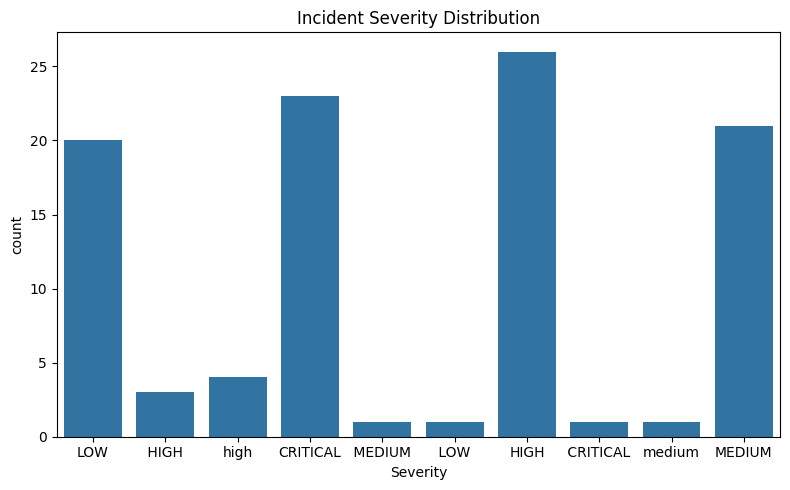

In [28]:
# Incident Severity Analysis
plt.figure(figsize=(8,5))

sns.countplot( data=incidents, x="Severity" )

plt.title("Incident Severity Distribution")

plt.tight_layout()

plt.show()

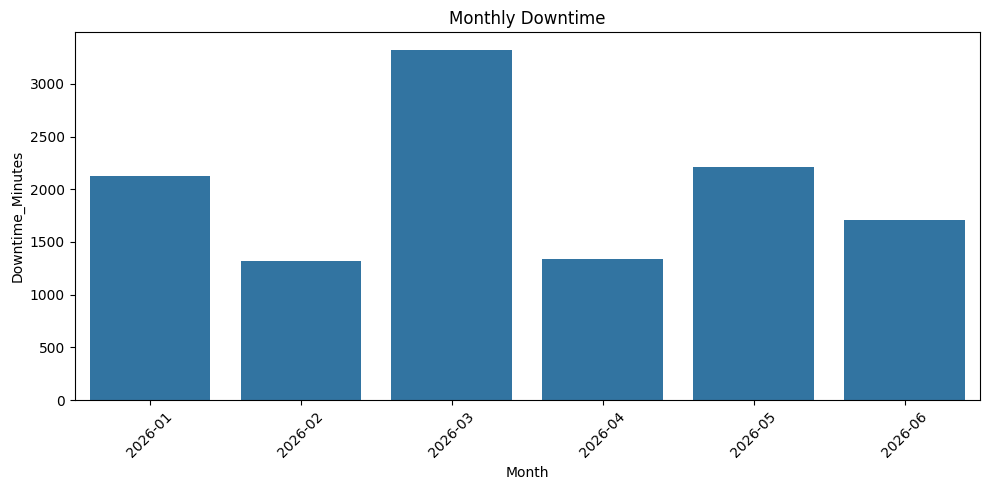

In [30]:
# Monthly Downtime
incidents["Month"] = ( incidents["Open_Time"].dt.to_period("M").astype(str) )

monthly = ( incidents.groupby("Month")["Downtime_Minutes"].sum().reset_index() )

plt.figure(figsize=(10,5))

sns.barplot( data=monthly, x="Month", y="Downtime_Minutes" )

plt.title("Monthly Downtime")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

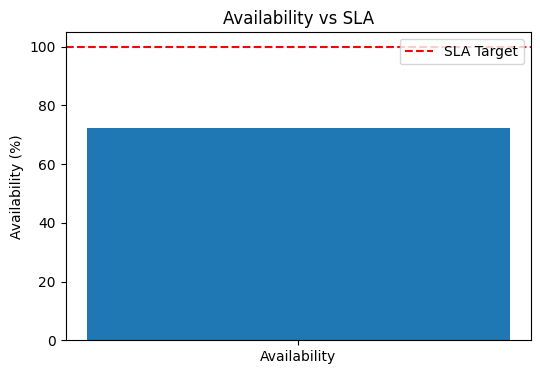

In [31]:
# SLA Gauge
plt.figure(figsize=(6,4))

plt.bar( ["Availability"], [availability] )

plt.axhline( SLA_TARGET, color="red", linestyle="--", label="SLA Target" )

plt.ylabel("Availability (%)")

plt.title("Availability vs SLA")

plt.legend()

plt.show()

In [ ]:
# KPI Summmery

kpi = pd.DataFrame({
    "Metric": [
        "Availability",
        "SLA Target",
        "SLO Target",
        "Total Downtime (Minutes)",
        "Remaining Error Budget"
    ],
    "Value": [
        round(availability, 2),
        SLA_TARGET,
        SLO_TARGET,
        round(total_downtime, 2),
        round(remaining_budget, 2)
    ]
})

print(kpi)

                     Metric     Value
0              Availability     72.19
1                SLA Target     99.90
2                SLO Target     99.50
3  Total Downtime (Minutes)  12016.00
4    Remaining Error Budget -11972.80


TC : 6  Incident MTTA/MTTR metrics and trend.
-----------------------------------------------

In [37]:
# Converting to datetime otherwise it will show type error while using it into other datatype
incidents["Open_Time"] = pd.to_datetime(incidents["Open_Time"])
incidents["Close_Time"] = pd.to_datetime(incidents["Close_Time"])

In [34]:
# Normalize Severity And Status
incidents["Severity"] = ( incidents["Severity"].str.strip().str.title() )

incidents["Status"] = ( incidents["Status"].str.strip().str.upper() )

In [40]:
# Calculating the resolution time.
incidents["MTTR_Minutes"] = ( incidents["Close_Time"] - incidents["Open_Time"] ).dt.total_seconds() / 60

In [42]:
# Overall MTTR
overall_mttr = incidents["MTTR_Minutes"].mean()

print(f"Overall MTTR : {overall_mttr:.2f} Minutes")

Overall MTTR : 121.37 Minutes


In [43]:
# MTTR by severity
severity_mttr = ( incidents.groupby("Severity", as_index=False).agg( Average_MTTR=("MTTR_Minutes", "mean"),
        Incident_Count=("Incident_ID", "count") ) )

print(severity_mttr)

   Severity  Average_MTTR  Incident_Count
0  Critical    106.750000              24
1      High    129.500000              33
2       Low    131.650000              21
3    Medium    116.391304              23


In [44]:
# Monthly MTTR Trend
incidents["Month"] = ( incidents["Open_Time"].dt.to_period("M").astype(str) )

monthly_mttr = ( incidents.groupby("Month", as_index=False).agg( Average_MTTR=("MTTR_Minutes", "mean")))

print(monthly_mttr)

     Month  Average_MTTR
0  2026-01    117.944444
1  2026-02    101.384615
2  2026-03    151.000000
3  2026-04     95.357143
4  2026-05    122.833333
5  2026-06    121.928571


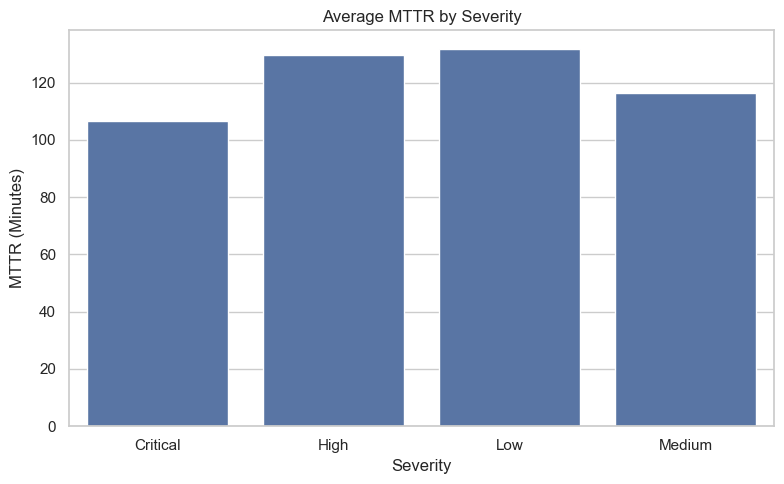

In [45]:
# Visualisation
plt.figure(figsize=(8,5))

sns.barplot( data=severity_mttr, x="Severity", y="Average_MTTR" )

plt.title("Average MTTR by Severity")

plt.xlabel("Severity")

plt.ylabel("MTTR (Minutes)")

plt.tight_layout()

plt.show()

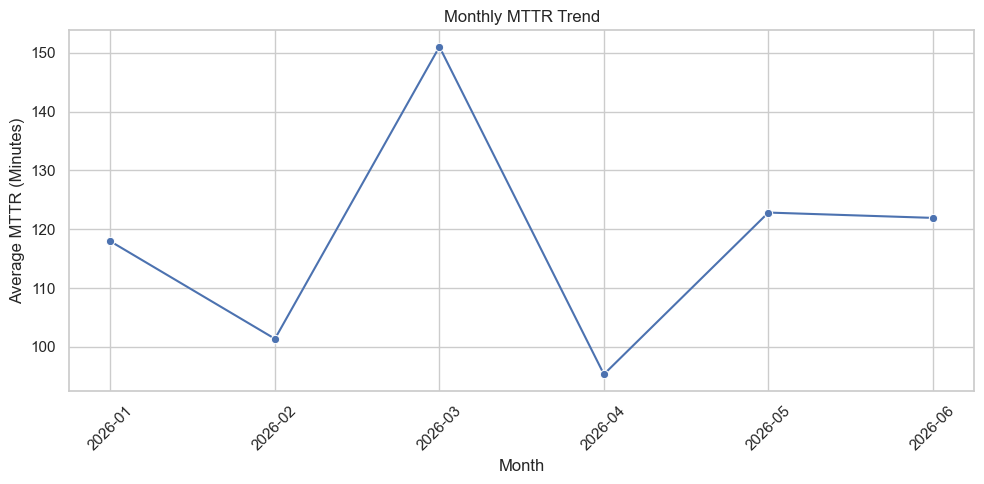

In [46]:
# Monthly MTTR Trend
plt.figure(figsize=(10,5))

sns.lineplot( data=monthly_mttr, x="Month", y="Average_MTTR", marker="o" )

plt.title("Monthly MTTR Trend")

plt.xlabel("Month")

plt.ylabel("Average MTTR (Minutes)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

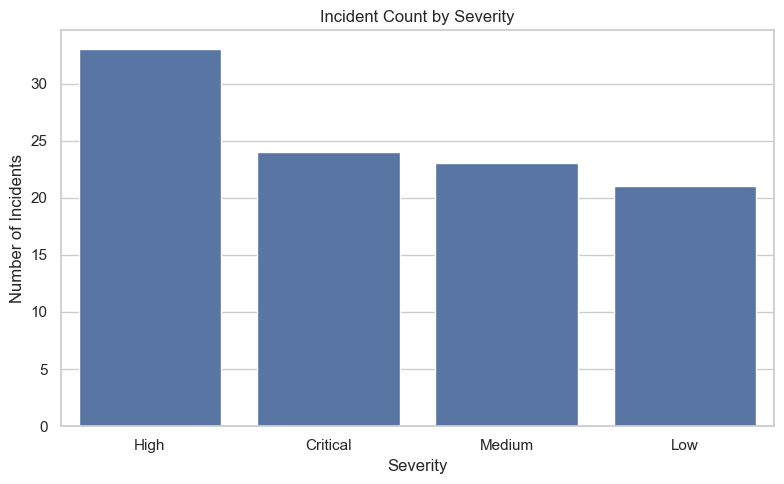

In [47]:
# Incident Count by Severity
plt.figure(figsize=(8,5))

sns.countplot( data=incidents, x="Severity", order=incidents["Severity"].value_counts().index )

plt.title("Incident Count by Severity")

plt.xlabel("Severity")

plt.ylabel("Number of Incidents")

plt.tight_layout()

plt.show()

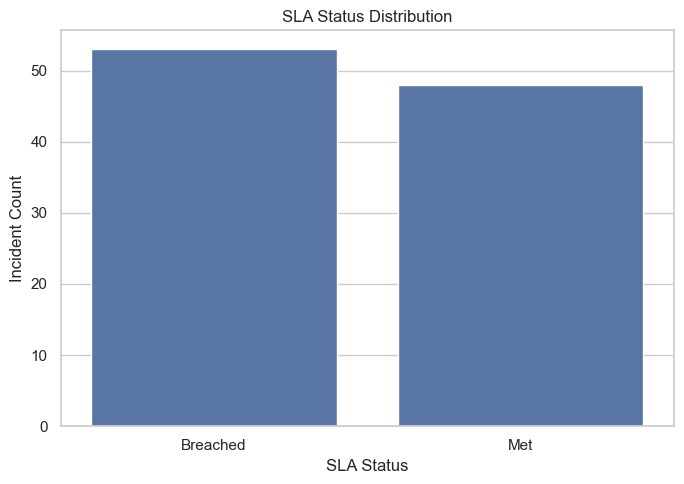

In [48]:
# SLA Status Distribution
plt.figure(figsize=(7,5))

sns.countplot( data=incidents, x="SLA_Status" )

plt.title("SLA Status Distribution")

plt.xlabel("SLA Status")

plt.ylabel("Incident Count")

plt.tight_layout()

plt.show()

TC : 7 Anomaly detection features for cost spikes.
---------------------------------------------------

In [49]:
billing["TS"] = pd.to_datetime(billing["TS"])

In [50]:
billing["Date"] = billing["TS"].dt.date

billing["Month"] = billing["TS"].dt.to_period("M").astype(str)

billing["Day"] = billing["TS"].dt.day

billing["Hour"] = billing["TS"].dt.hour

In [53]:
# Daily cost per account 
daily_cost = ( billing.groupby(["Account", "Date"], as_index=False).agg(Daily_Cost=("Cost", "sum"),
        Daily_Usage=("Usage", "sum") ) )

In [57]:
print(daily_cost["Daily_Cost"].dtype)

object


In [58]:
# Removiing the symbol to avoid error
daily_cost["Daily_Cost"] = (
    daily_cost["Daily_Cost"].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False)
)

daily_cost["Daily_Cost"] = pd.to_numeric( daily_cost["Daily_Cost"], errors="coerce")

In [61]:
daily_cost = daily_cost.sort_values(["Account", "Date"])

daily_cost["Rolling_Avg_Cost"] = (
    daily_cost
    .groupby("Account")["Daily_Cost"]
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

# Daily cost Spike

daily_cost["Cost_Spike_%"] = (
    ( daily_cost["Daily_Cost"] - daily_cost["Rolling_Avg_Cost"] ) / daily_cost["Rolling_Avg_Cost"] ) * 100

# Cost Z-Score
daily_cost["Cost_ZScore"] = (
    daily_cost
    .groupby("Account")["Daily_Cost"]
    .transform( lambda x: (x - x.mean()) / x.std() ) )

In [70]:
# Cost Anomalies
daily_cost["Cost_Anomaly"] = np.where( daily_cost["Cost_ZScore"] > 3, "Spike", "Normal" )

# View Anomalies
cost_spikes = daily_cost[ daily_cost["Cost_Anomaly"] == "Spike"]

print(cost_spikes)

Empty DataFrame
Columns: [Account, Date, Daily_Cost, Daily_Usage, Rolling_Avg_Cost, Cost_Spike_%, Cost_ZScore, Cost_Anomaly]
Index: []


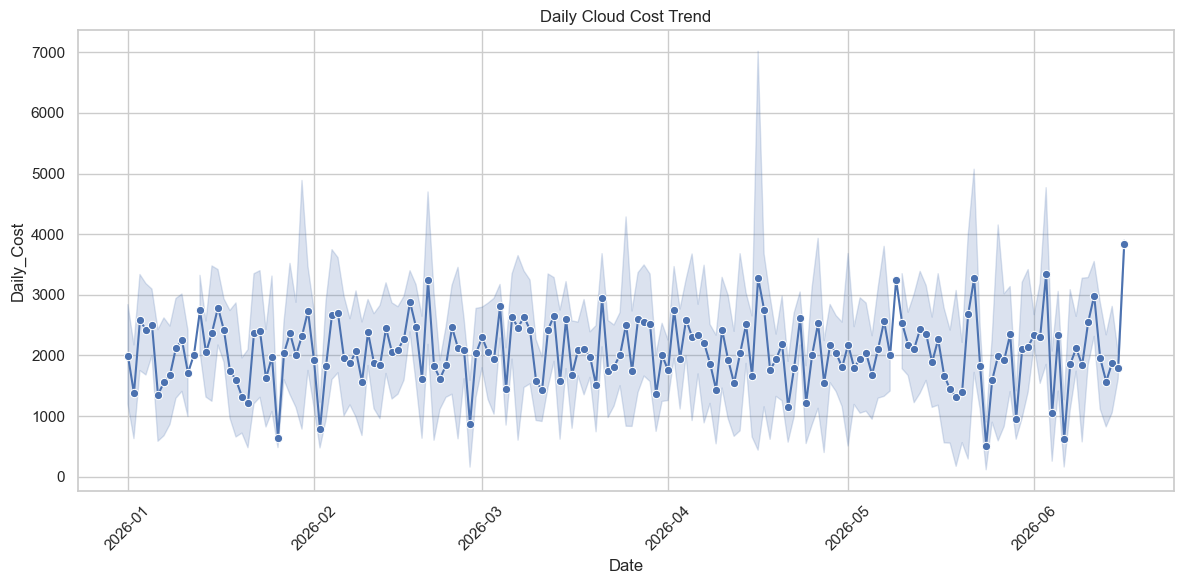

In [62]:
# Daily Cost Trend
plt.figure(figsize=(12,6))

sns.lineplot( data=daily_cost, x="Date", y="Daily_Cost", marker="o" )

plt.title("Daily Cloud Cost Trend")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

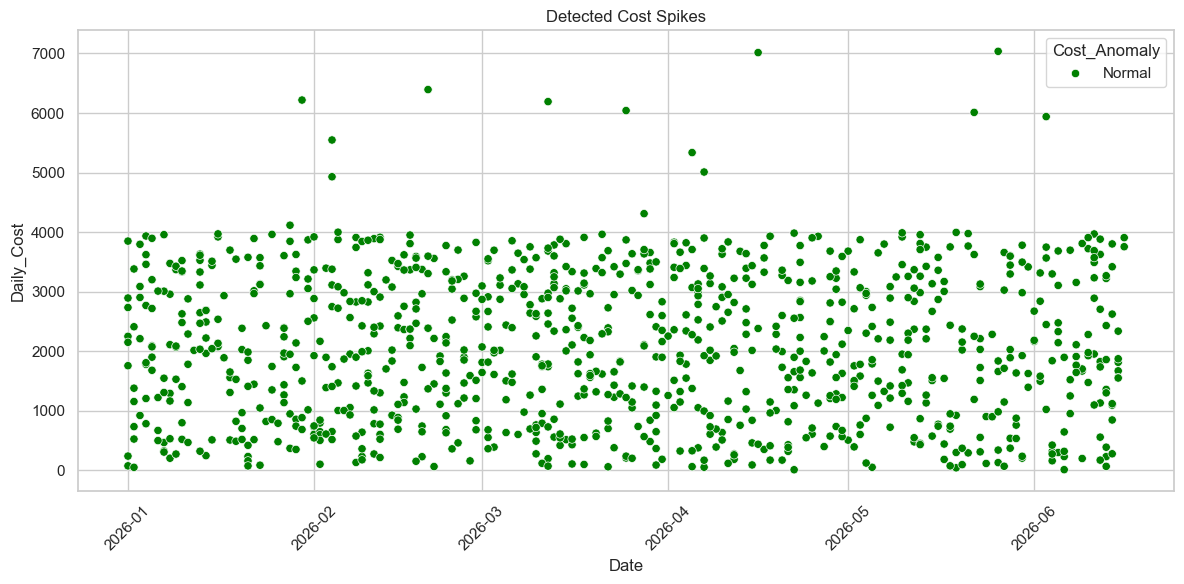

In [67]:
# Cost Spike detection
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=daily_cost,
    x="Date",
    y="Daily_Cost",
    hue="Cost_Anomaly",
    palette={
        "Normal":"green",
        "Spike":"red"
    }
)

plt.title("Detected Cost Spikes")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

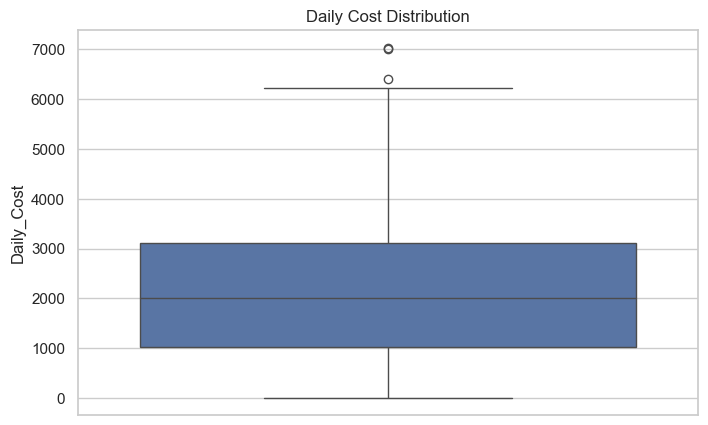

In [68]:
# Cost Detection
plt.figure(figsize=(8,5))

sns.boxplot( y=daily_cost["Daily_Cost"] )

plt.title("Daily Cost Distribution")

plt.show()

In [72]:
# Cleaning the cost column
billing["Cost"] = ( billing["Cost"].astype(str).str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

billing["Cost"] = pd.to_numeric(
    billing["Cost"],
    errors="coerce"
)

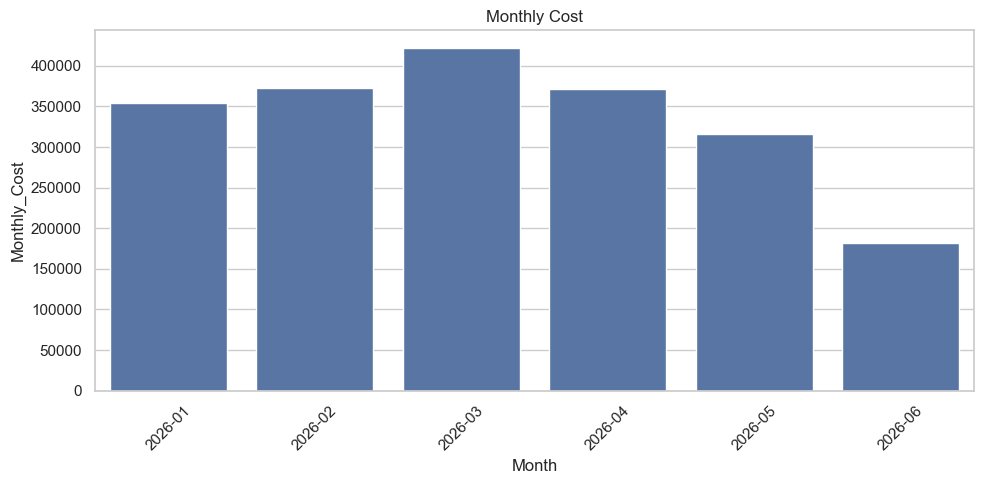

In [73]:
# Monthly Cost Trend
monthly = ( billing.groupby("Month", as_index=False).agg( Monthly_Cost=("Cost", "sum") ) )

plt.figure(figsize=(10,5))

sns.barplot(
    data=monthly,
    x="Month",
    y="Monthly_Cost"
)

plt.title("Monthly Cost")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

TC : 8 Unit cost (₹/vCPU‑hr, ₹/GB‑mo) normalization.
-----------------------------------------------------

In [76]:
# Merging the billing and resource dataset
billing_resource = billing.merge( resource, on=["Resource_ID", "Account"], how="left" )

# Normalize the usage to hours
unit_factor = { "sec": 1 / 3600, "min": 1 / 60, "hrs": 1 }

billing_resource["Usage_Hours"] = (
    billing_resource["Usage"] *
    billing_resource["Unit"].map(unit_factor)
)

In [78]:
# Calculate the rupees per hour
billing_resource["Cost_Per_Hour"] = ( billing_resource["Cost"] / billing_resource["Usage_Hours"] )

billing_resource["Cost_Per_Hour"] = ( billing_resource["Cost_Per_Hour"].replace([np.inf, -np.inf], np.nan) )

# Estimate ₹ per vCPU-Hour
billing_resource["Cost_Per_CPU_Util"] = ( billing_resource["Cost"] / billing_resource["CPU_Utilization"]
)

billing_resource["Cost_Per_CPU_Util"] = ( billing_resource["Cost_Per_CPU_Util"].replace([np.inf, -np.inf], np.nan)
)

In [80]:
# Estimate rupees per GB
billing_resource["Cost_Per_Memory_Util"] = ( billing_resource["Cost"] / billing_resource["Memory_Utilization"]
)

billing_resource["Cost_Per_Memory_Util"] = ( billing_resource["Cost_Per_Memory_Util"].replace([np.inf, -np.inf], np.nan)
)

# Summery by Service 
service_cost = ( billing_resource.groupby("Service", as_index=False).agg( Average_Cost=("Cost", "mean"),
        Average_Cost_Per_Hour=("Cost_Per_Hour", "mean"),
        Average_CPU_Cost=("Cost_Per_CPU_Util", "mean"),
        Average_Memory_Cost=("Cost_Per_Memory_Util", "mean")
    ))

print(service_cost)

      Service  Average_Cost  Average_Cost_Per_Hour  Average_CPU_Cost  \
0    Compute    1169.120000                  288.0               NaN   
1    Network     537.520000                  288.0               NaN   
2    Storage    1936.360000                  288.0               NaN   
3     COMPUTE   3591.680000                  288.0               NaN   
4     Compute   1955.081629                  288.0           4.09641   
5    DATABASE   1987.386667                  288.0               NaN   
6    Database   2104.579124                  288.0         197.32200   
7     NETWORK   1050.480000                  288.0               NaN   
8     Network   2124.228300                  288.0               NaN   
9     STORAGE   3474.880000                  288.0               NaN   
10    Storage   1892.557838                  288.0               NaN   
11   database   2129.813333                  288.0               NaN   
12    storage   1931.320000                  288.0              

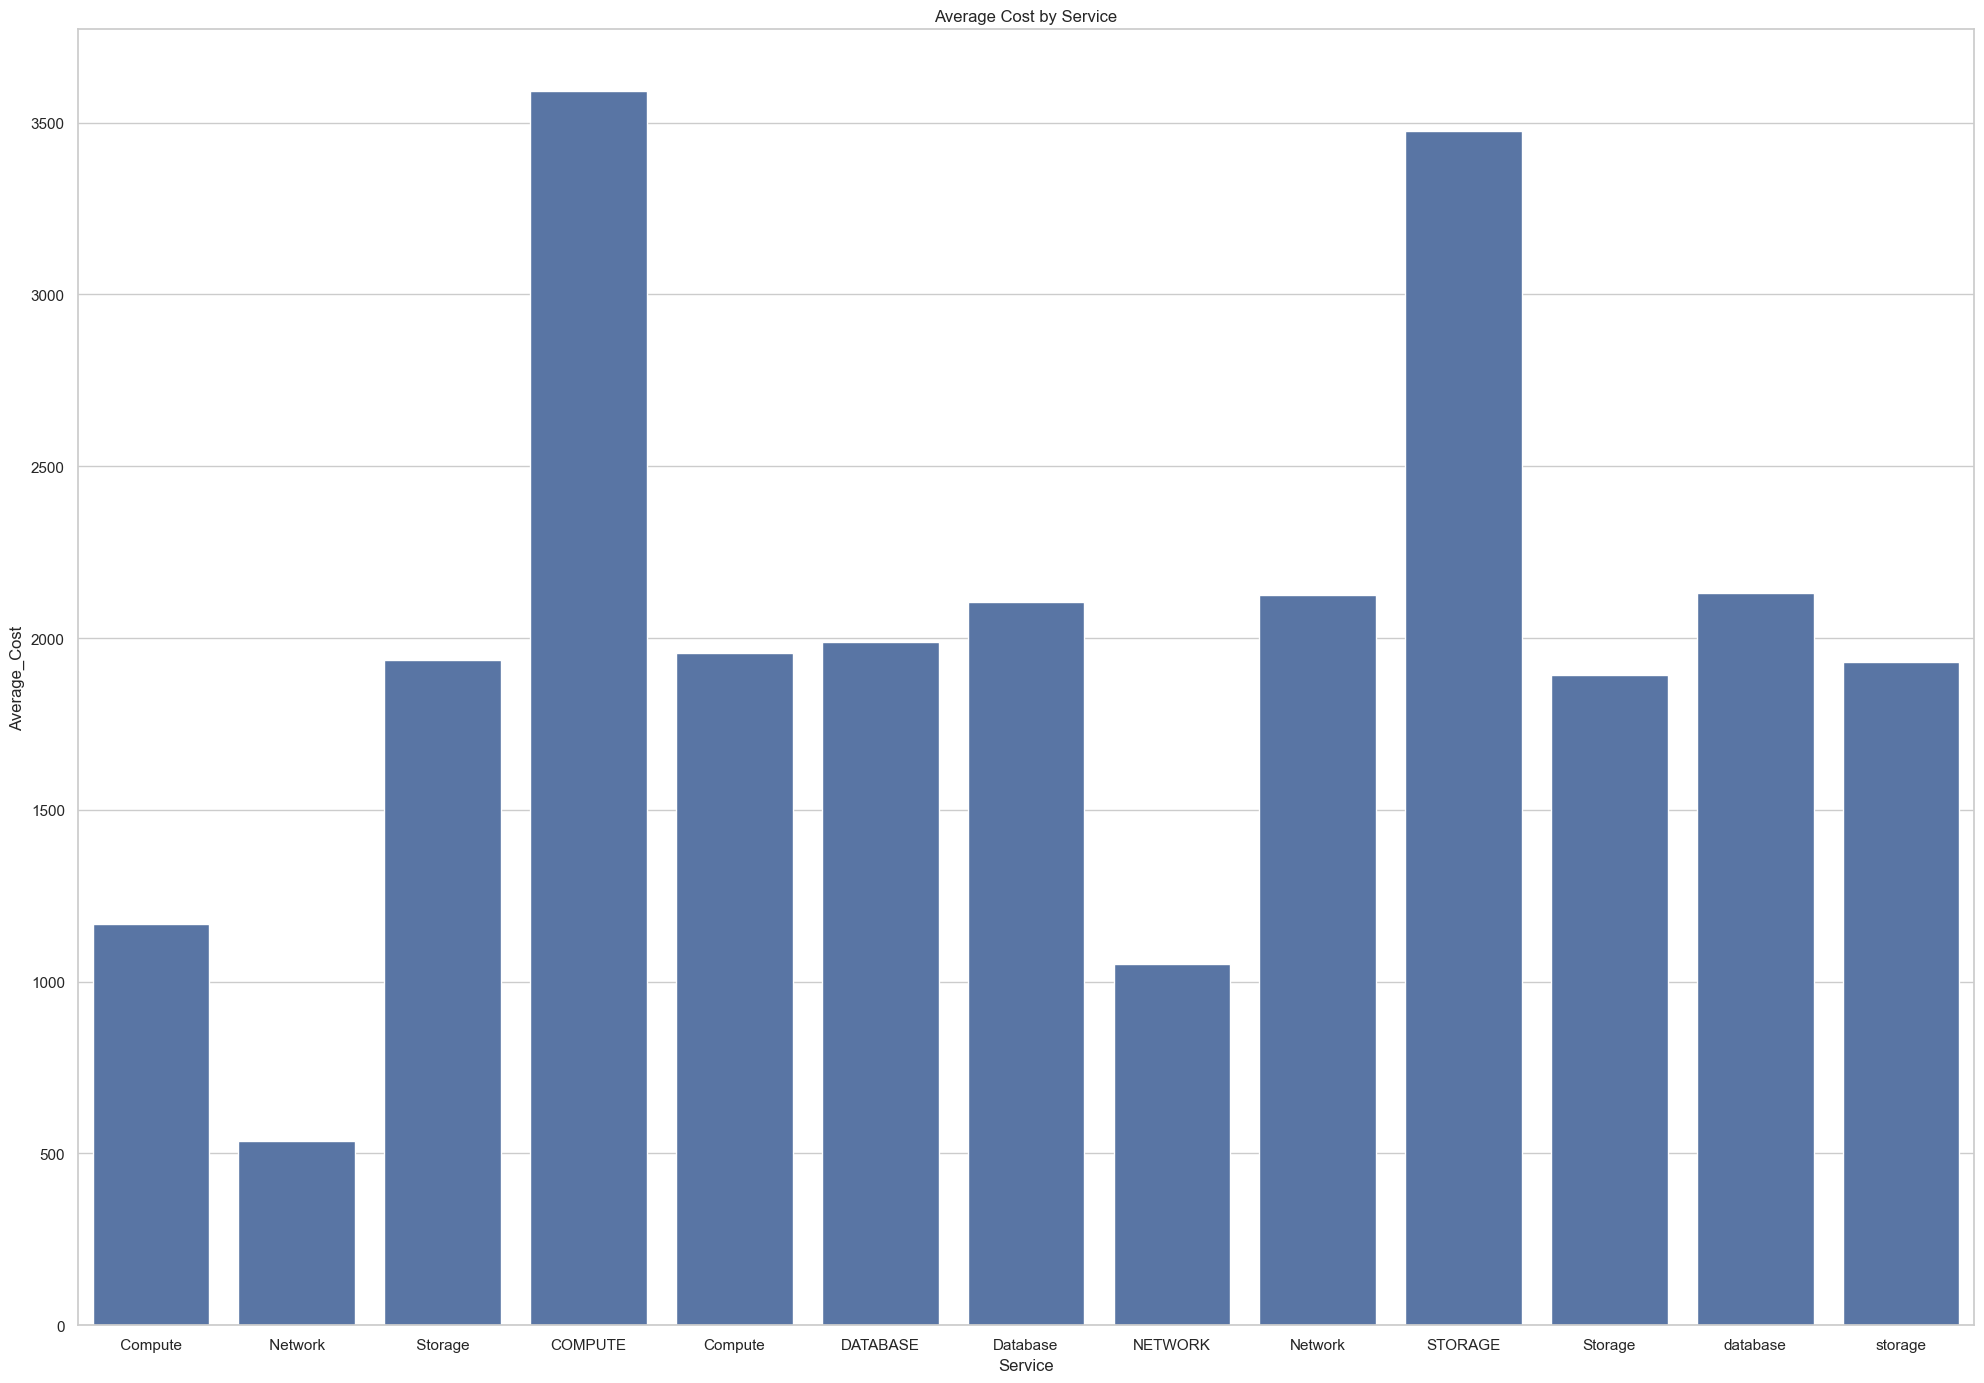

In [83]:
# Average Cost by Service
plt.figure(figsize=(20,14))

sns.barplot( data=service_cost, x="Service", y="Average_Cost" )

plt.title("Average Cost by Service")

plt.tight_layout()

plt.show()

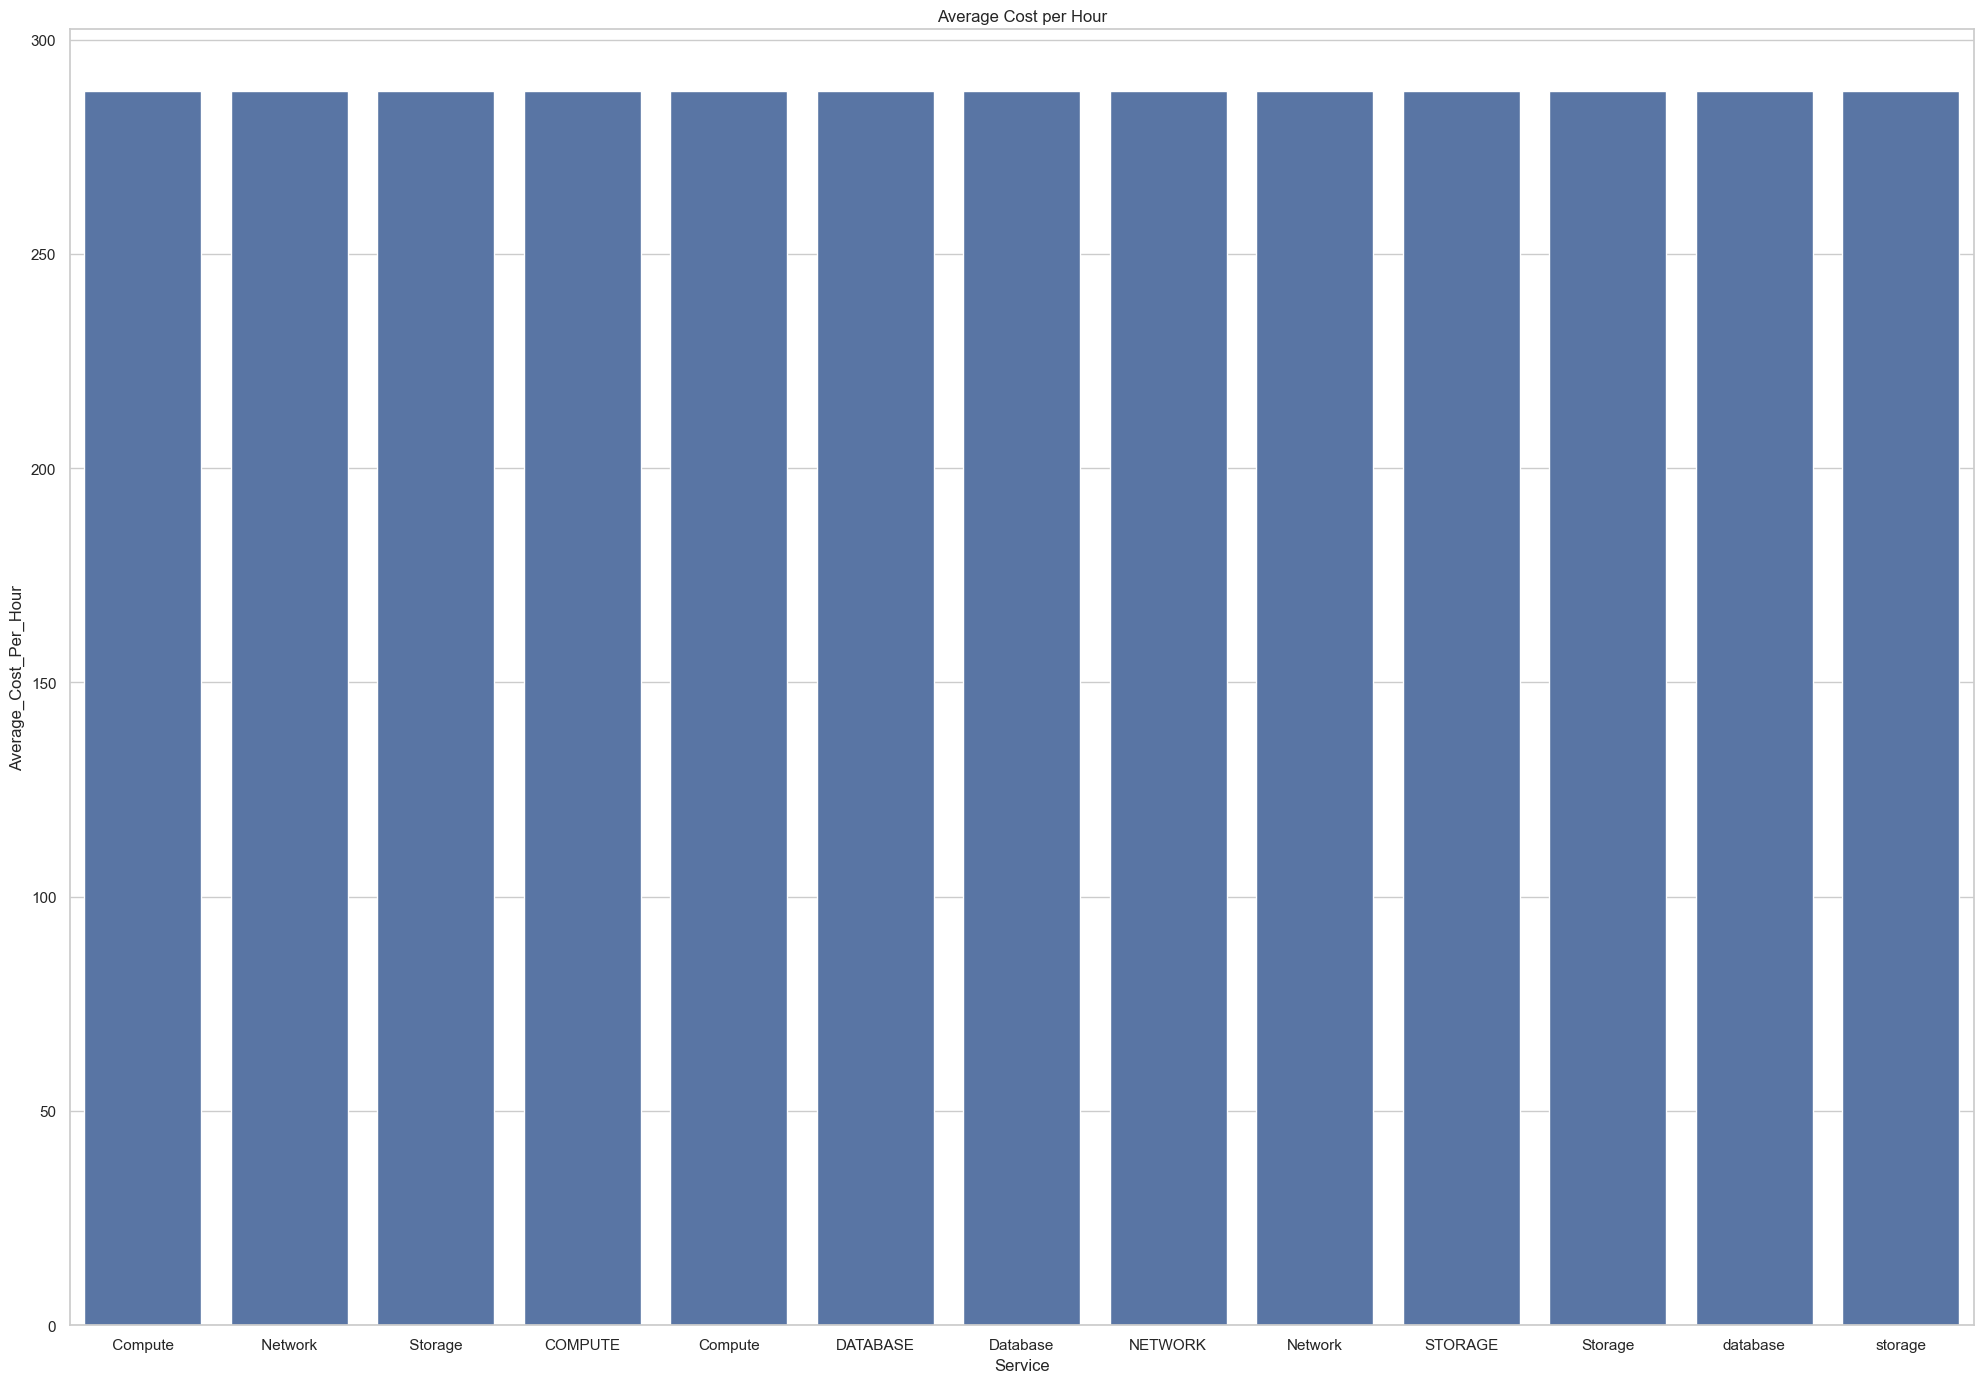

In [85]:
# Cost per Hour by Service
plt.figure(figsize=(20, 14))

sns.barplot( data=service_cost, x="Service", y="Average_Cost_Per_Hour" )

plt.title("Average Cost per Hour")

plt.tight_layout()

plt.show()

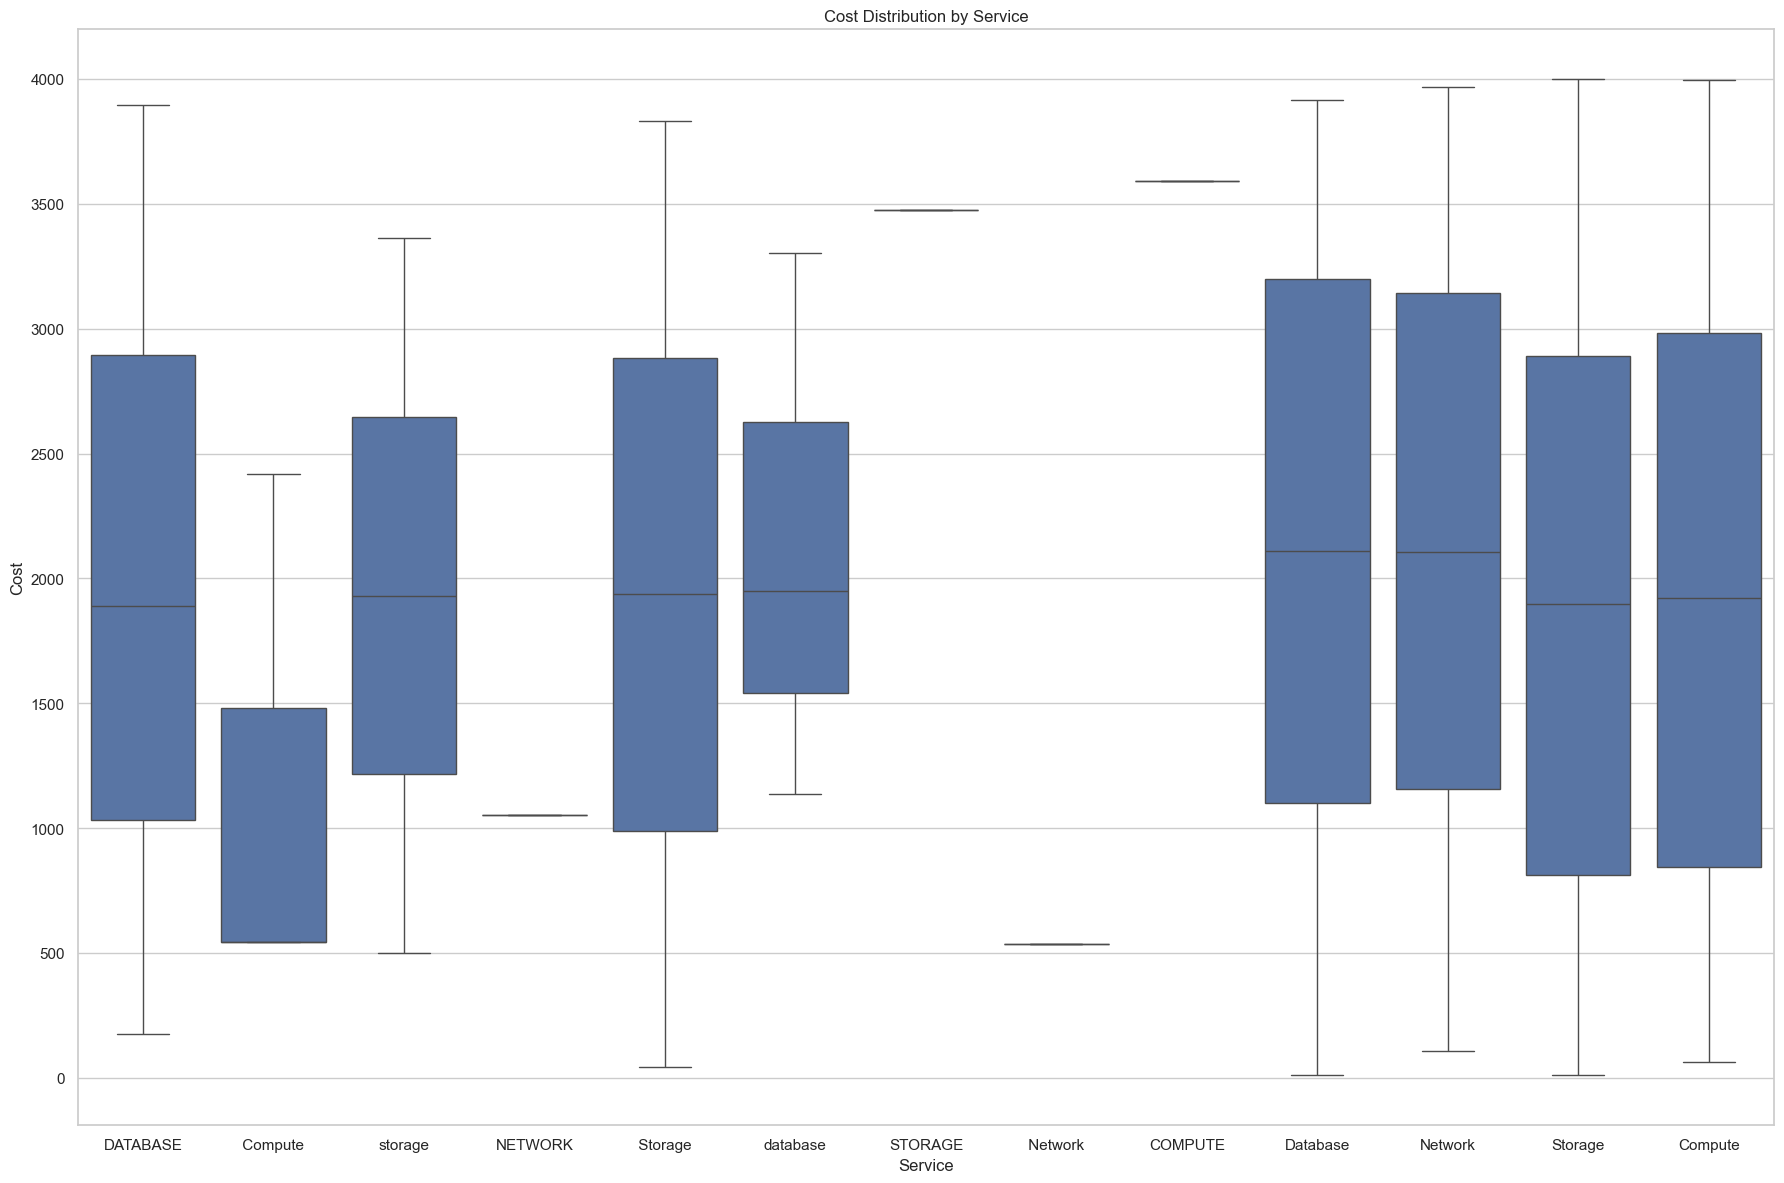

In [87]:
# Cost Distribution
plt.figure(figsize=(18,12))

sns.boxplot( data=billing_resource, x="Service", y="Cost" )

plt.title("Cost Distribution by Service")

plt.tight_layout()

plt.show()

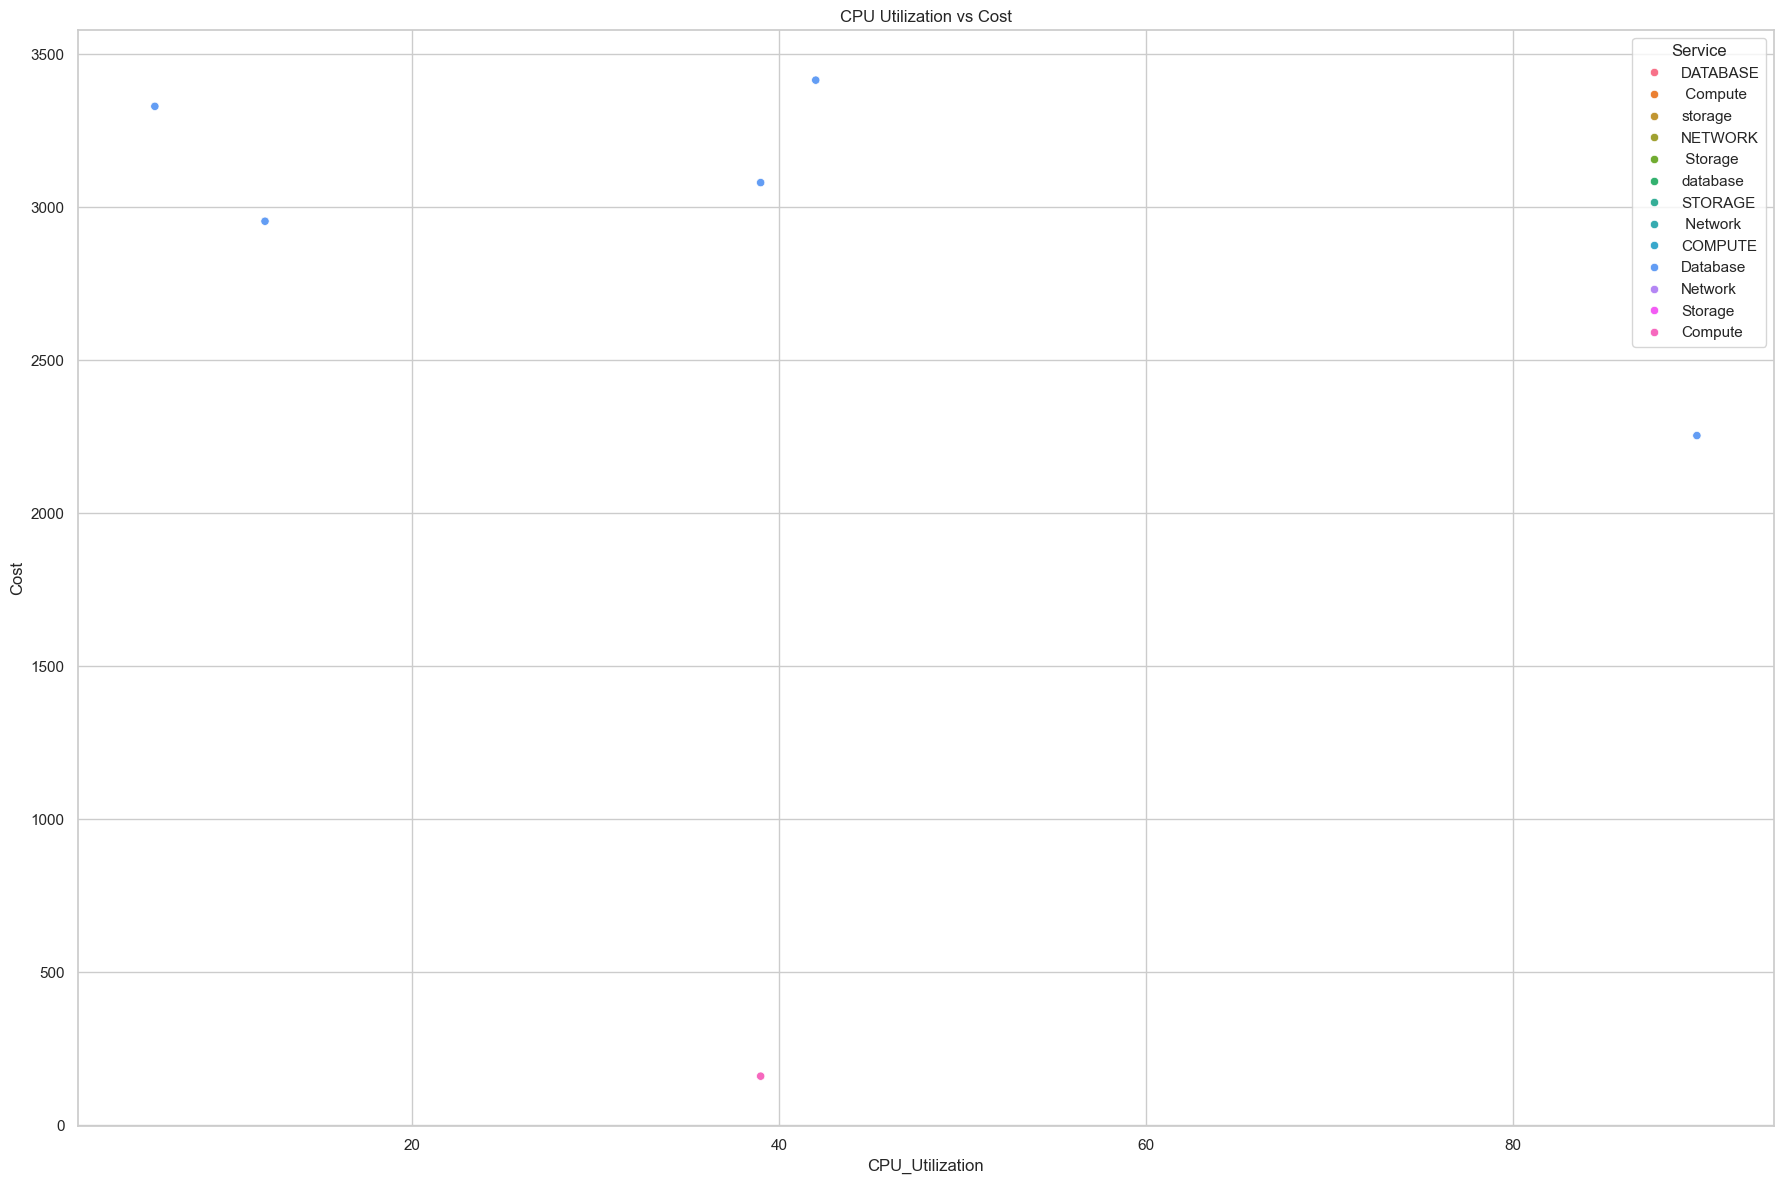

In [105]:
# CPU Utilization vs Cost
plt.figure(figsize=(18,12))

sns.scatterplot( data=billing_resource, x="CPU_Utilization", y="Cost", hue="Service" )

plt.title("CPU Utilization vs Cost")

plt.tight_layout()

plt.show()

TC : 9  Carbon footprint estimates per region and service.
-----------------------------------------------------------

In [91]:
# Merging the billing with resource
carbon = billing.merge( resource[ ["Resource_ID", "Region"] ], on="Resource_ID", how="left" )

# Merge carbin factor
carbon = carbon.merge( security[["Resource_ID", "Carbon_Factor"]],on="Resource_ID",how="left" )

In [93]:
# Calculate carbon factor
carbon["Carbon_Emission"] = ( carbon["Usage"] * carbon["Carbon_Factor"] ).round(2)

# Region-wise Carbon Footprint
region_carbon = (
    carbon
    .groupby("Region", as_index=False)
    .agg( Total_Carbon=("Carbon_Emission", "sum"), Total_Usage=("Usage", "sum") ) )

print(region_carbon)

         Region  Total_Carbon  Total_Usage
0   ap-south-1      155310.87       369963
1    us-east-1       64967.24       140370
2    AP-SOUTH-1      67501.47       184966
3     EU-WEST-1      99210.24       216768
4     US-EAST-1     106324.50       391407
5    ap-south-1    4169567.91     12298868
6     eu-west-1    5631993.38     15415956
7     us-east-1    6563369.00     18023447


In [94]:
# Service wise carbon footprint
service_carbon = ( carbon.groupby("Service", as_index=False).agg(
        Total_Carbon=("Carbon_Emission", "sum"),
        Total_Cost=("Cost", "sum") ) )

print(service_carbon)

      Service  Total_Carbon  Total_Cost
0    Compute       11725.24     4598.08
1    Network        2486.03      537.52
2    Storage       26603.95     7703.44
3     COMPUTE      56568.96    10775.04
4     Compute    3331031.44   768125.60
5    DATABASE      49121.24     9742.32
6    Database    4592319.34  1023041.28
7     NETWORK       4727.16     1050.48
8     Network    4367692.44   983946.88
9     STORAGE          0.00     3474.88
10    Storage    4304867.43   925664.48
11   database      61606.20    13590.88
12    storage      49495.18    11088.72


In [95]:
# Region + Service Carbon Cube
carbon_cube = (carbon.groupby(["Region", "Service"],as_index=False )
    .agg( Carbon_Emission=("Carbon_Emission", "sum"),Total_Cost=("Cost", "sum"), Total_Usage=("Usage", "sum")))

print(carbon_cube)

          Region    Service  Carbon_Emission  Total_Cost  Total_Usage
0    ap-south-1     Compute         58962.66    11072.80       138410
1    ap-south-1    Database         65542.98    12321.84       154023
2    ap-south-1     NETWORK          4727.16     1050.48        13131
3    ap-south-1     Network          7395.84     1643.52        20544
4    ap-south-1     Storage         18682.23     3508.40        43855
5     us-east-1     Compute          4016.96     1004.24        12553
6     us-east-1    Database          4586.56     1146.64        14333
7     us-east-1     Network         56363.72     9078.72       113484
8     AP-SOUTH-1    Storage         67501.47    14797.28       184966
9      EU-WEST-1   Database         12759.12     3780.48        47256
10     EU-WEST-1    Network         86451.12    13560.96       169512
11     US-EAST-1    Compute         25071.85     5495.20        68690
12     US-EAST-1   Database         31760.84    13678.16       170977
13     US-EAST-1    

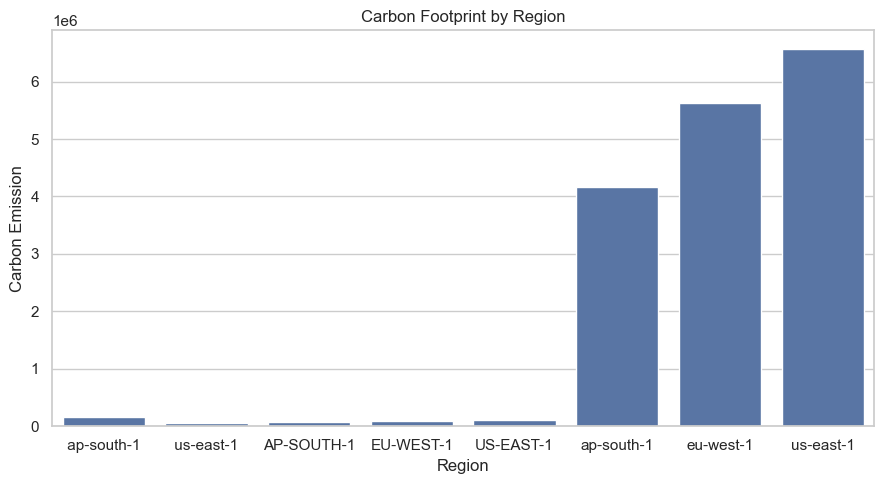

In [96]:
# Carbon Emission by Region
plt.figure(figsize=(9,5))

sns.barplot( data=region_carbon, x="Region", y="Total_Carbon" )

plt.title("Carbon Footprint by Region")

plt.xlabel("Region")

plt.ylabel("Carbon Emission")

plt.tight_layout()

plt.show()

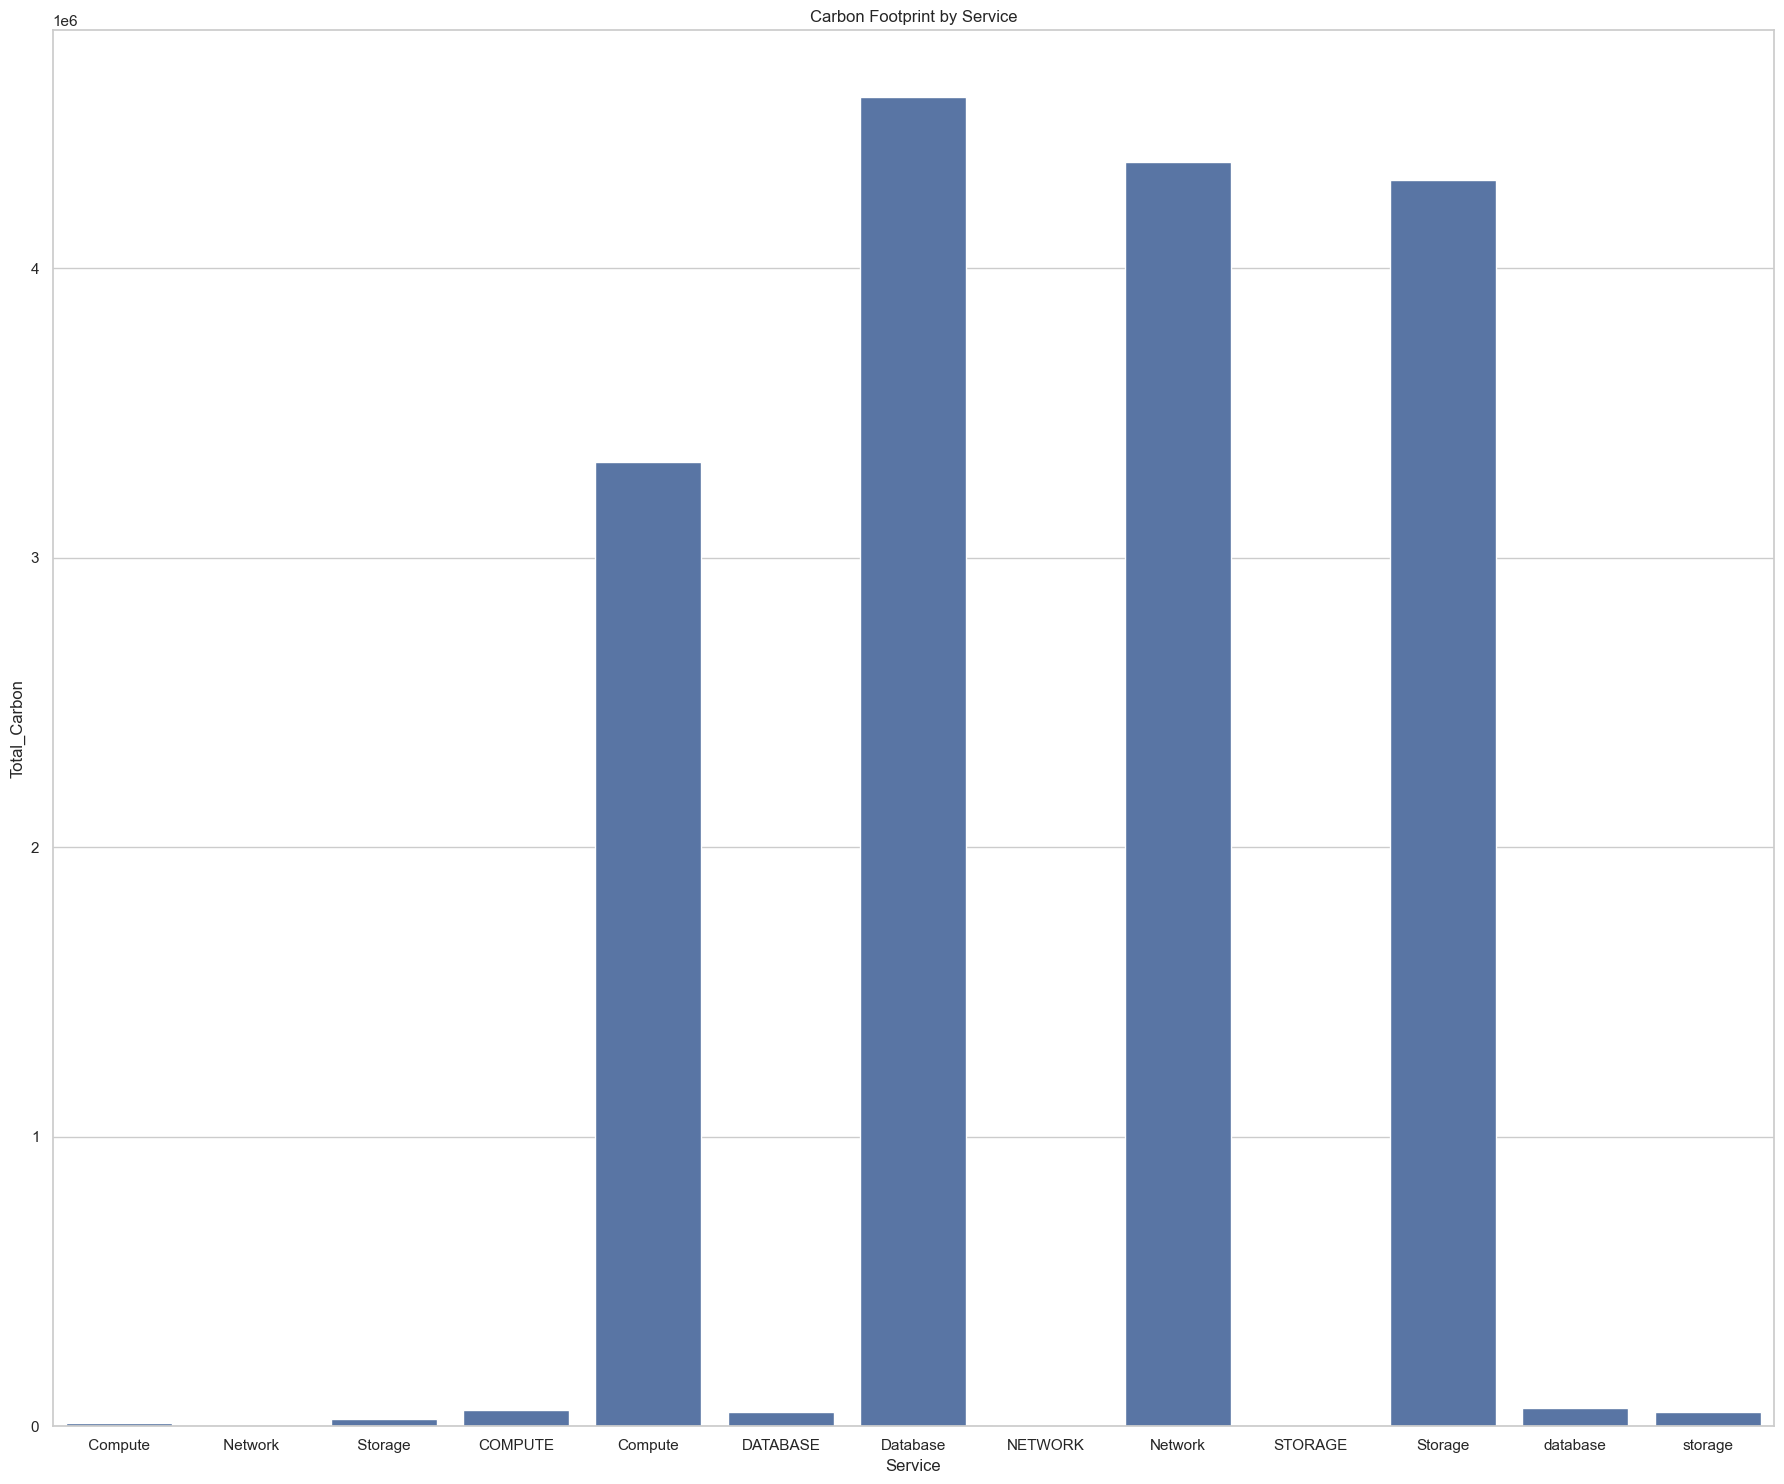

In [99]:
# Carbon Emission by Service
plt.figure(figsize=(18,15))

sns.barplot( data=service_carbon, x="Service", y="Total_Carbon" )

plt.title("Carbon Footprint by Service")

plt.tight_layout()

plt.show()

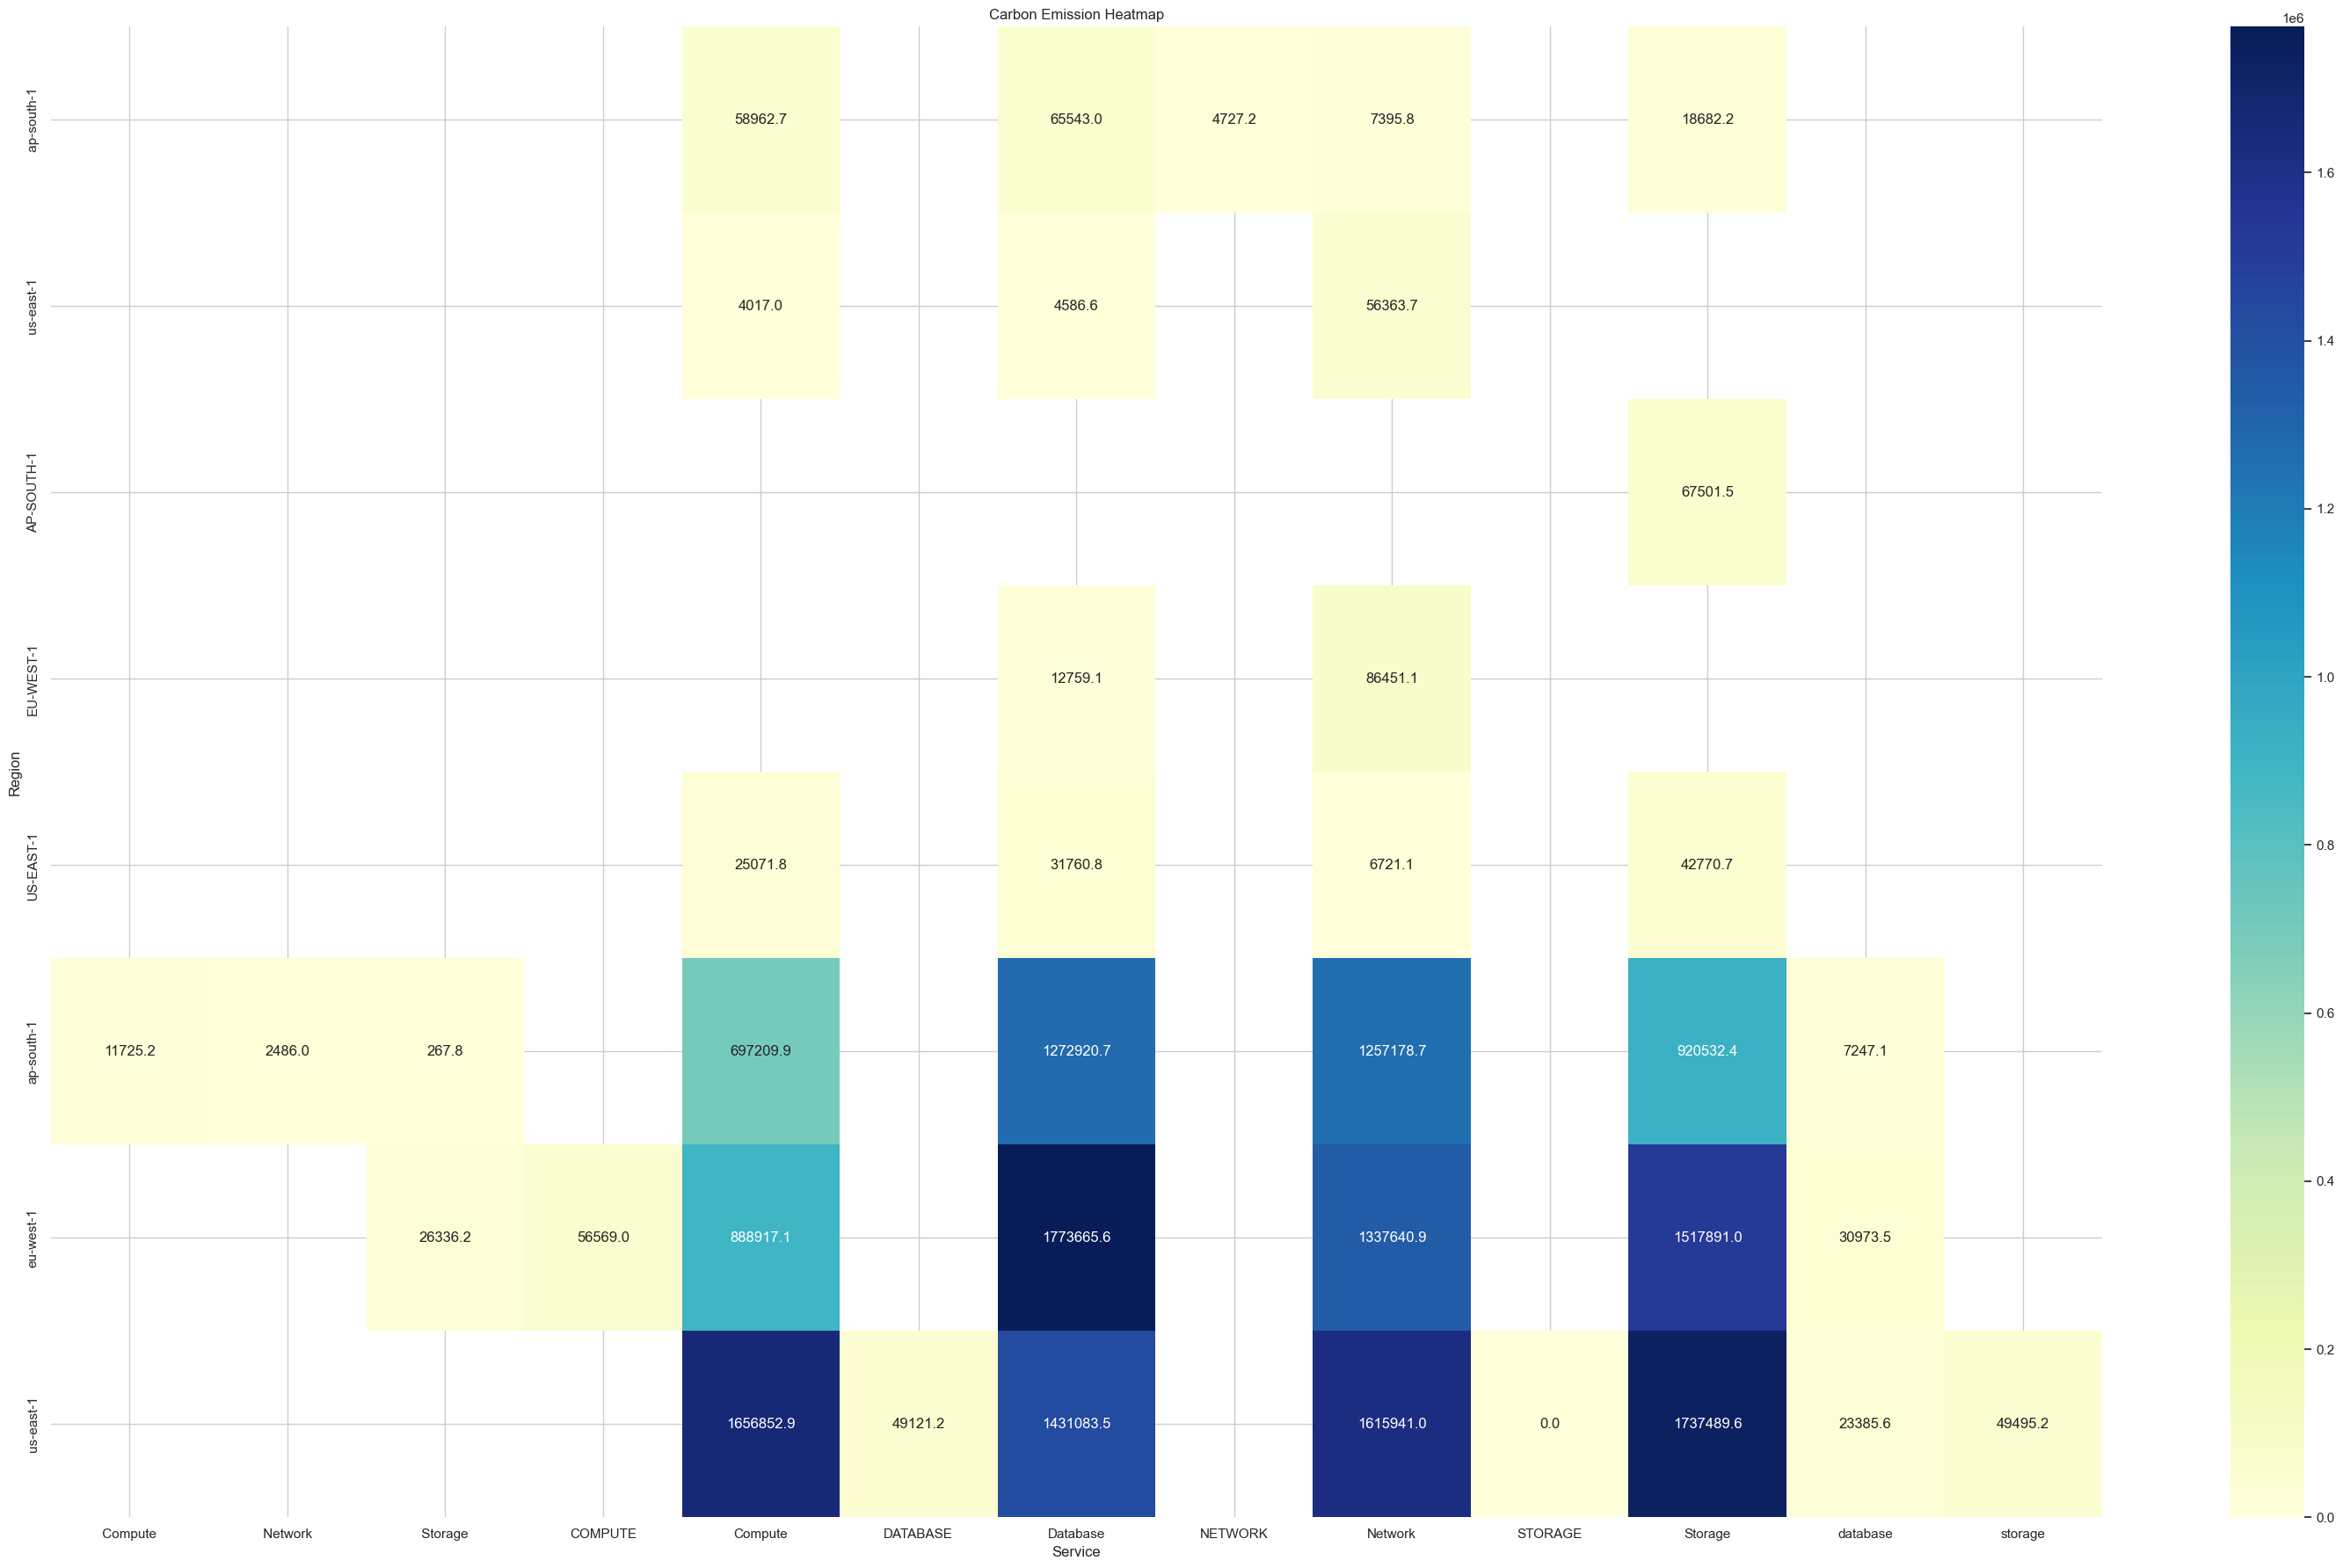

In [102]:
# Region-Service Heatmap
pivot = carbon_cube.pivot_table(index="Region", columns="Service", values="Carbon_Emission", aggfunc="sum" )

plt.figure(figsize=(30,18))

sns.heatmap( pivot, annot=True, cmap="YlGnBu", fmt=".1f" )

plt.title("Carbon Emission Heatmap")

plt.tight_layout()

plt.show()

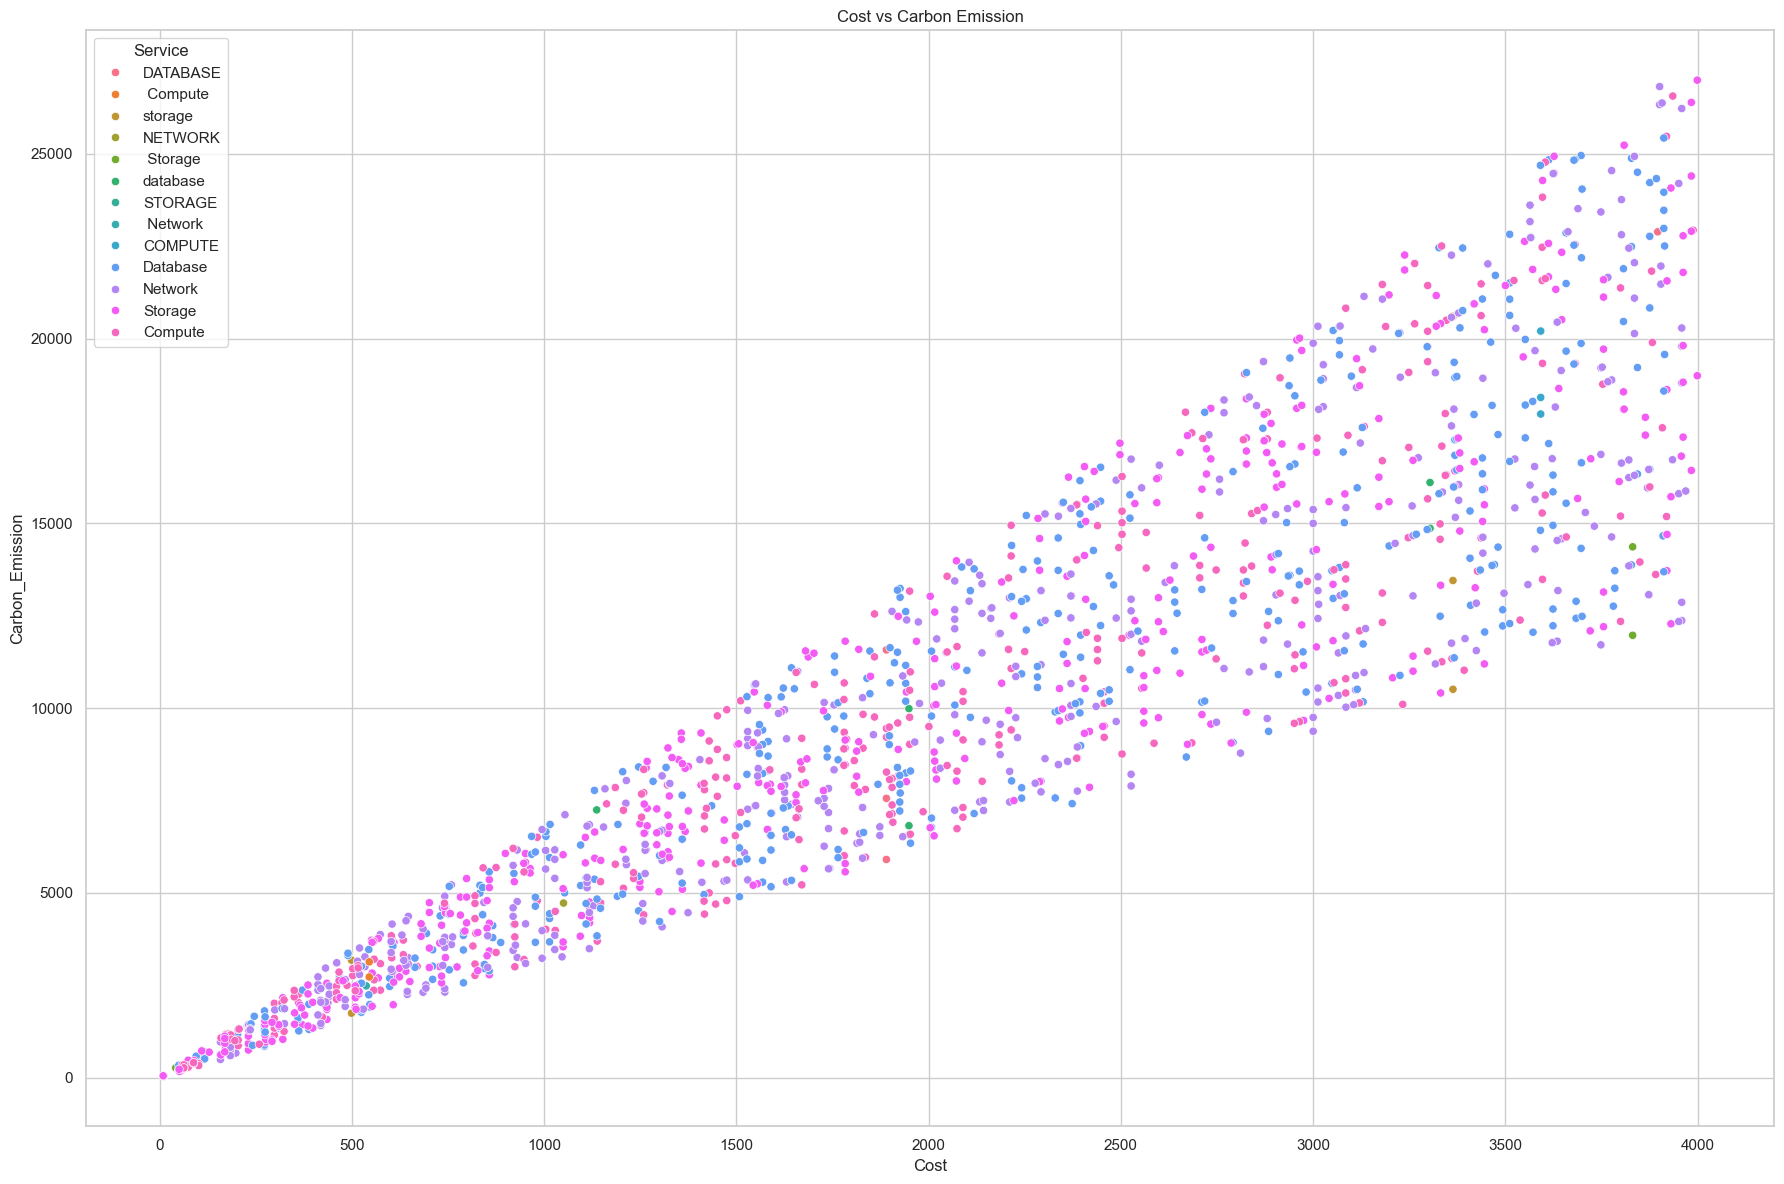

In [104]:
# Cost vs Carbon Emission
plt.figure(figsize=(18,12))

sns.scatterplot( data=carbon, x="Cost", y="Carbon_Emission", hue="Service" )

plt.title("Cost vs Carbon Emission")

plt.tight_layout()

plt.show()

In [106]:
region_carbon.to_csv(
    "Region_Carbon_Report.csv",
    index=False
)

service_carbon.to_csv(
    "Service_Carbon_Report.csv",
    index=False
)

carbon_cube.to_csv(
    "Carbon_Cube.csv",
    index=False
)

TC : 10 Cost forecast with seasonality and growth.
---------------------------------------------------

In [109]:
billing["TS"] = pd.to_datetime(billing["TS"])

# Creating the month column
billing["Month"] = billing["TS"].dt.to_period("M").astype(str)

# Monthly Cost 
monthly_cost = ( billing.groupby("Month", as_index=False).agg(
        Monthly_Cost=("Cost", "sum"),
        Monthly_Usage=("Usage", "sum")
    ) )

print(monthly_cost)

     Month  Monthly_Cost  Monthly_Usage
0  2026-01     354418.96        4430237
1  2026-02     373021.76        4662772
2  2026-03     422513.76        5281422
3  2026-04     371612.72        4645159
4  2026-05     316228.24        3952853
5  2026-06     182378.08        2279726


In [112]:
# Create Trend Feature
monthly_cost["Month_No"] = np.arange(1, len(monthly_cost) + 1)

# Calculate Monthly Growth Rate
monthly_cost["Growth_%"] = ( monthly_cost["Monthly_Cost"].pct_change() * 100 ).round(2)

# Calculate the avg growth
avg_growth = ( monthly_cost["Growth_%"].dropna().mean() )

print(f"Average Growth Rate: {avg_growth:.2f}%")

Average Growth Rate: -10.15%


In [113]:
# Forcast for next 3 months 
forecast = monthly_cost.copy()

last_cost = forecast.iloc[-1]["Monthly_Cost"]

future = []

for i in range(1, 4):

    last_cost = last_cost * (1 + avg_growth / 100)

    future.append(last_cost)

future_months = pd.date_range(
    start=pd.to_datetime(monthly_cost.iloc[-1]["Month"]) + pd.offsets.MonthBegin(),
    periods=3,
    freq="MS"
).strftime("%Y-%m")

forecast_df = pd.DataFrame({
    "Month": future_months,
    "Forecast_Cost": future
})

print(forecast_df)

     Month  Forecast_Cost
0  2026-07  163863.057318
1  2026-08  147227.679739
2  2026-09  132281.125692


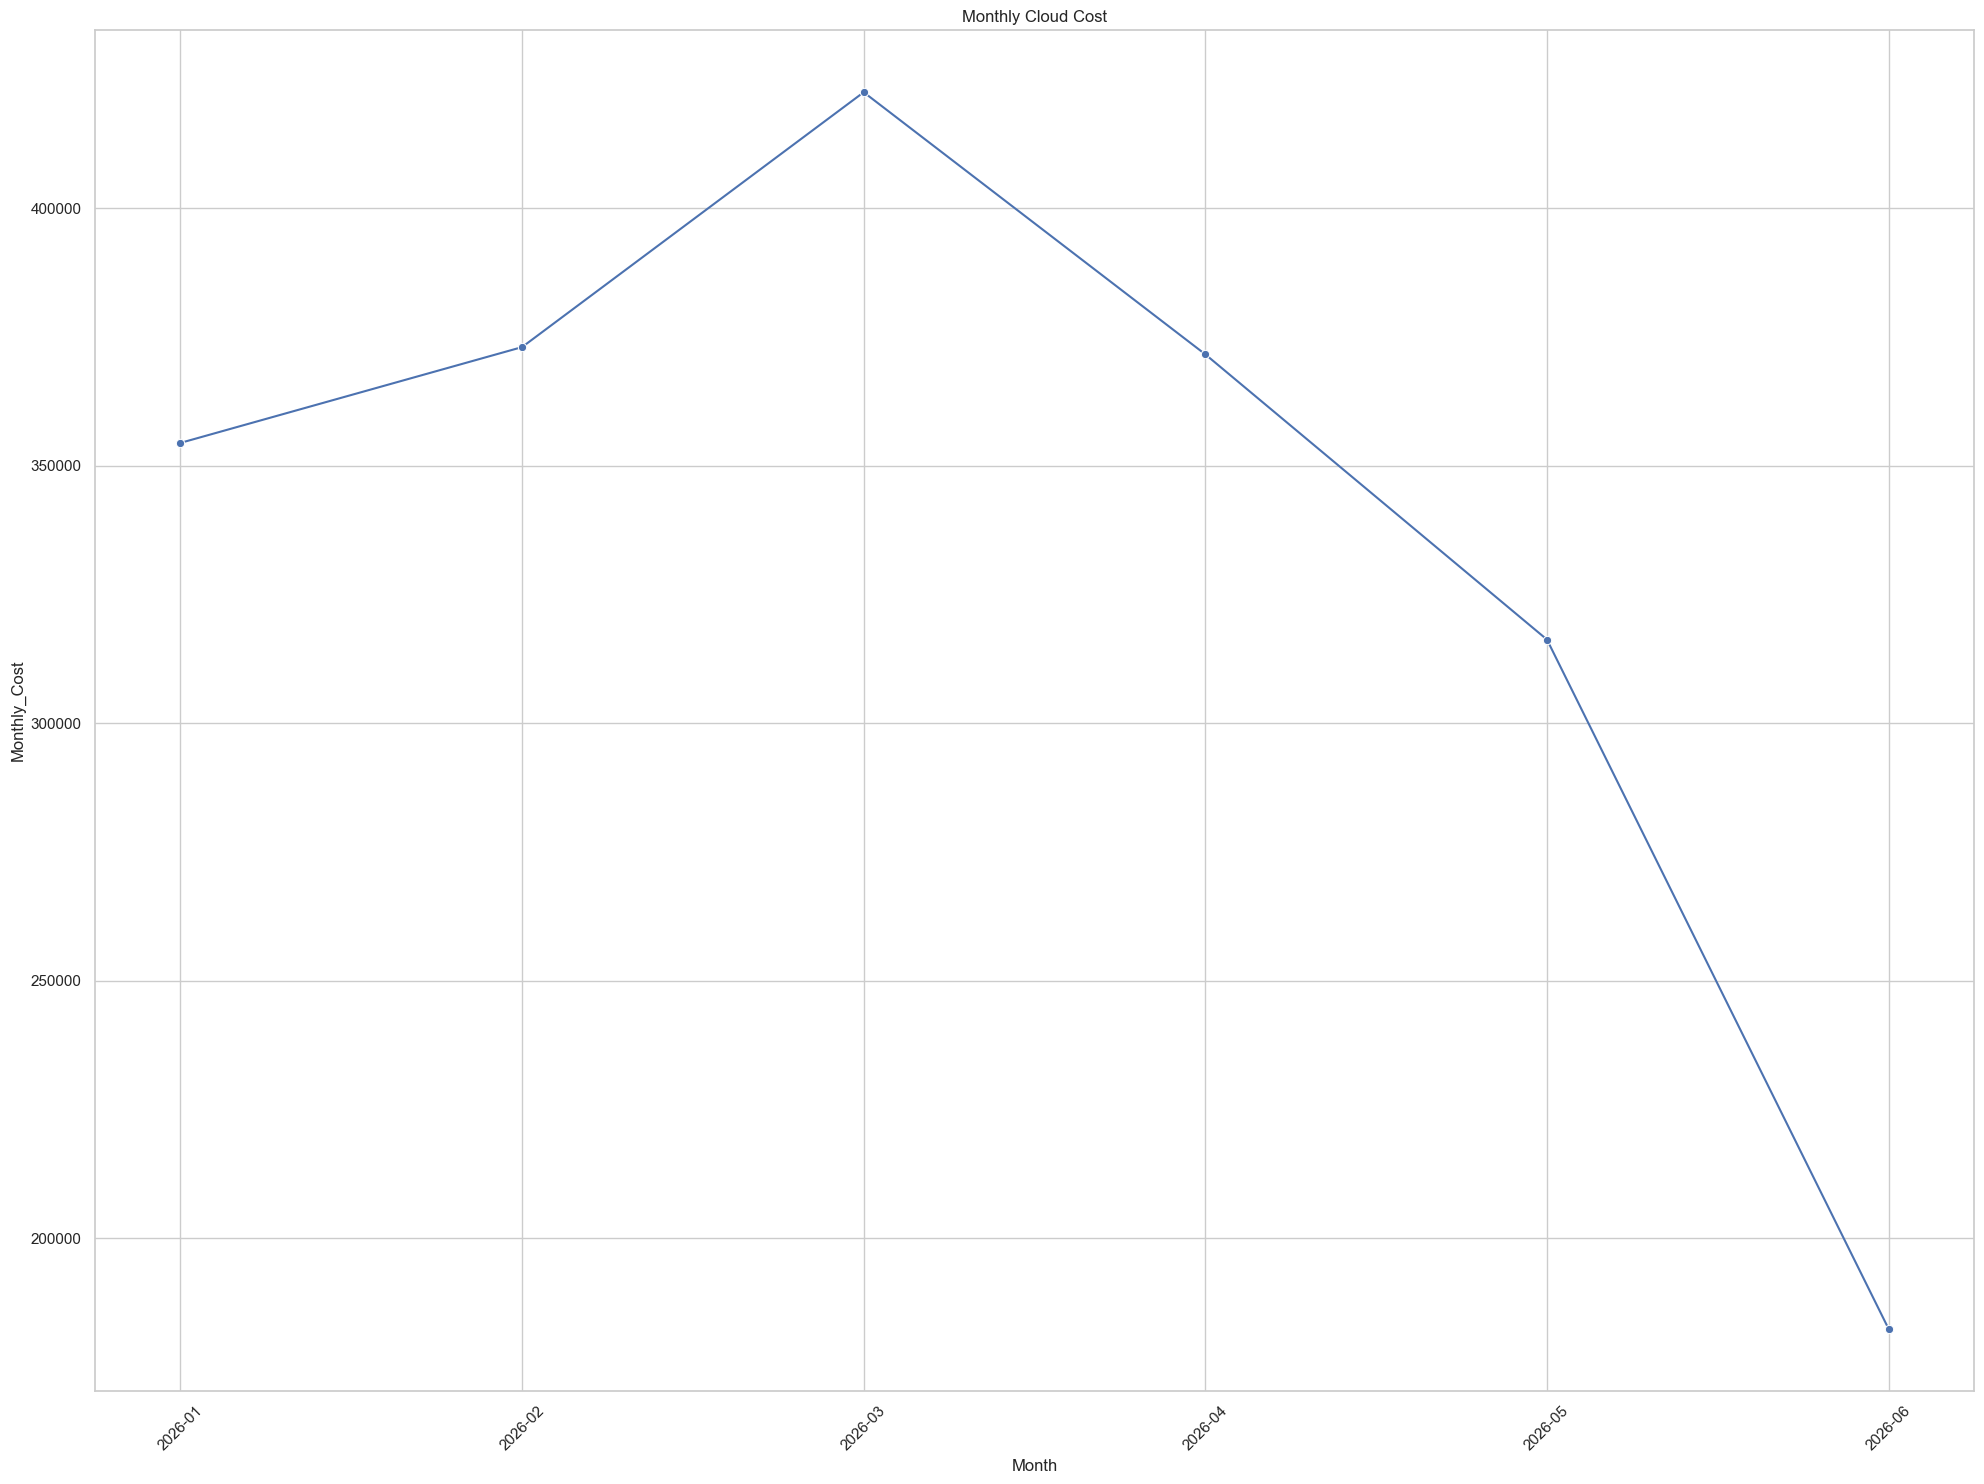

In [116]:
# Monthly Cost Trend
plt.figure(figsize=(20,15))

sns.lineplot( data=monthly_cost, x="Month", y="Monthly_Cost", marker="o" )

plt.title("Monthly Cloud Cost")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

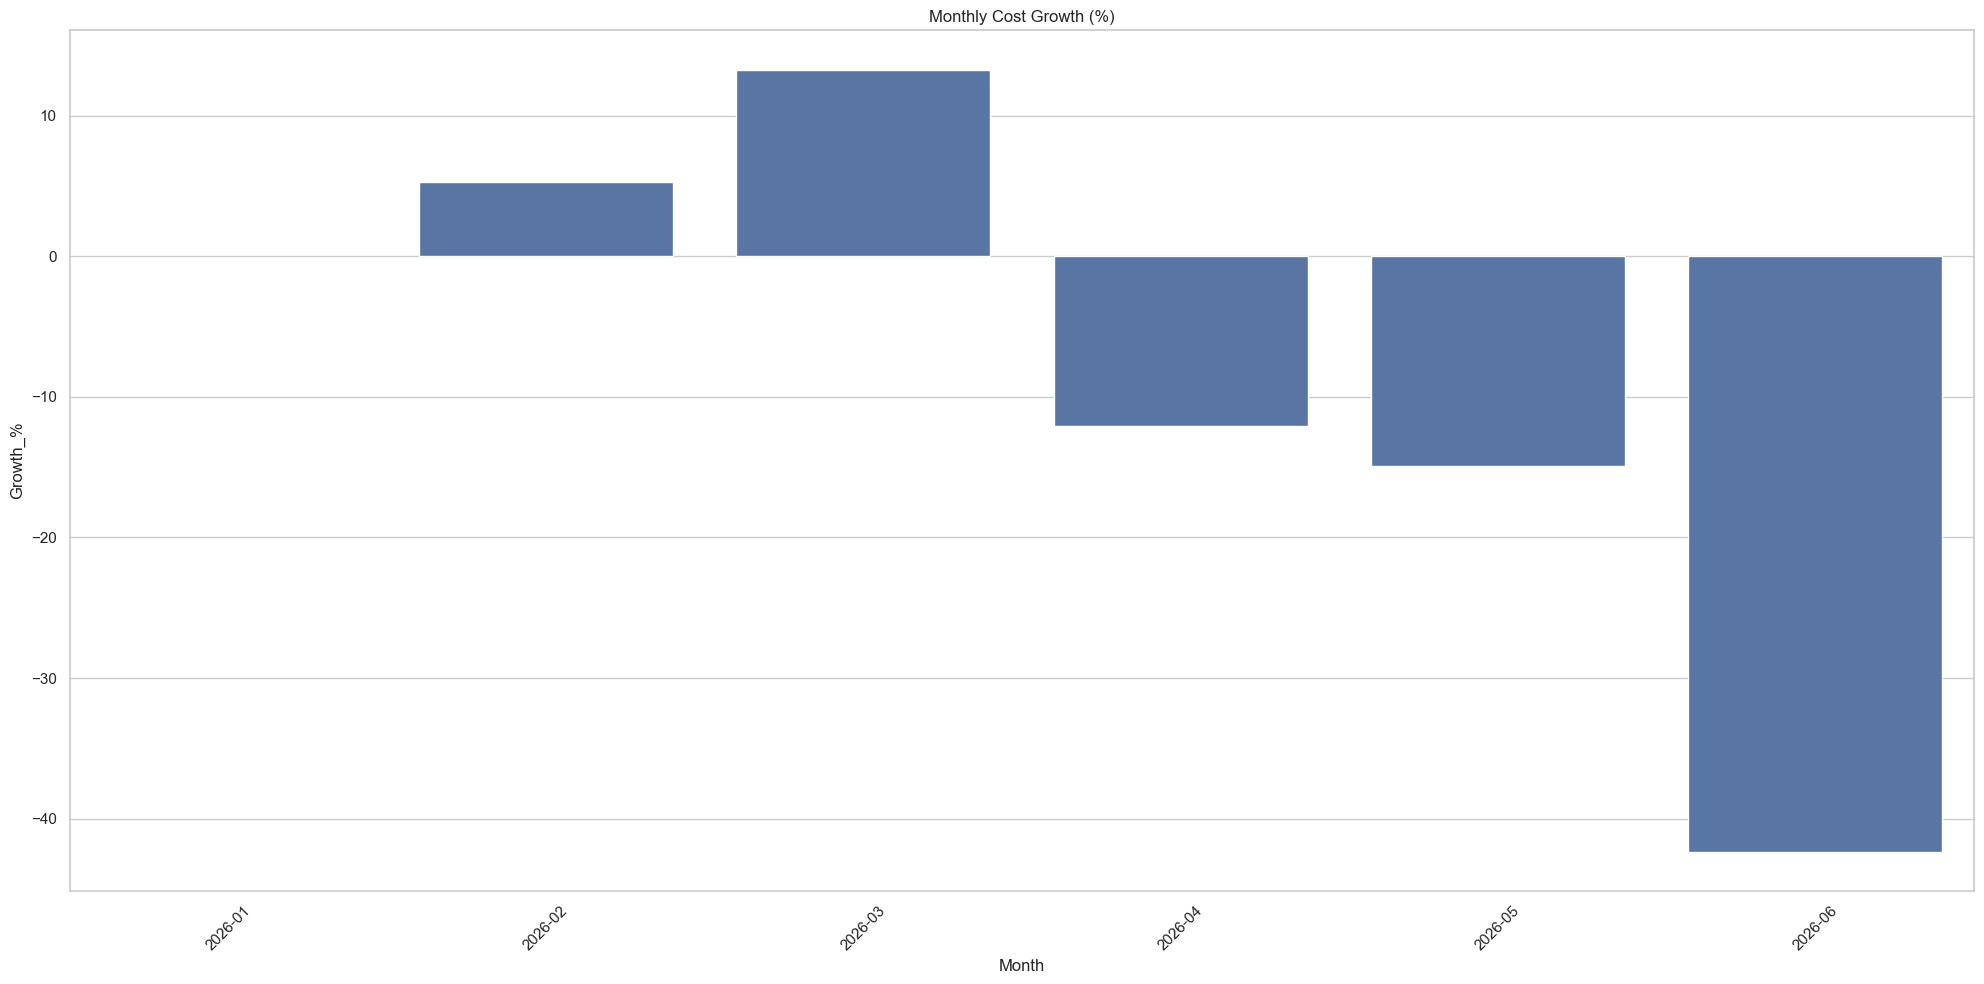

In [117]:
# Growth Percentage
plt.figure(figsize=(20,10))

sns.barplot( data=monthly_cost, x="Month", y="Growth_%" )

plt.title("Monthly Cost Growth (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

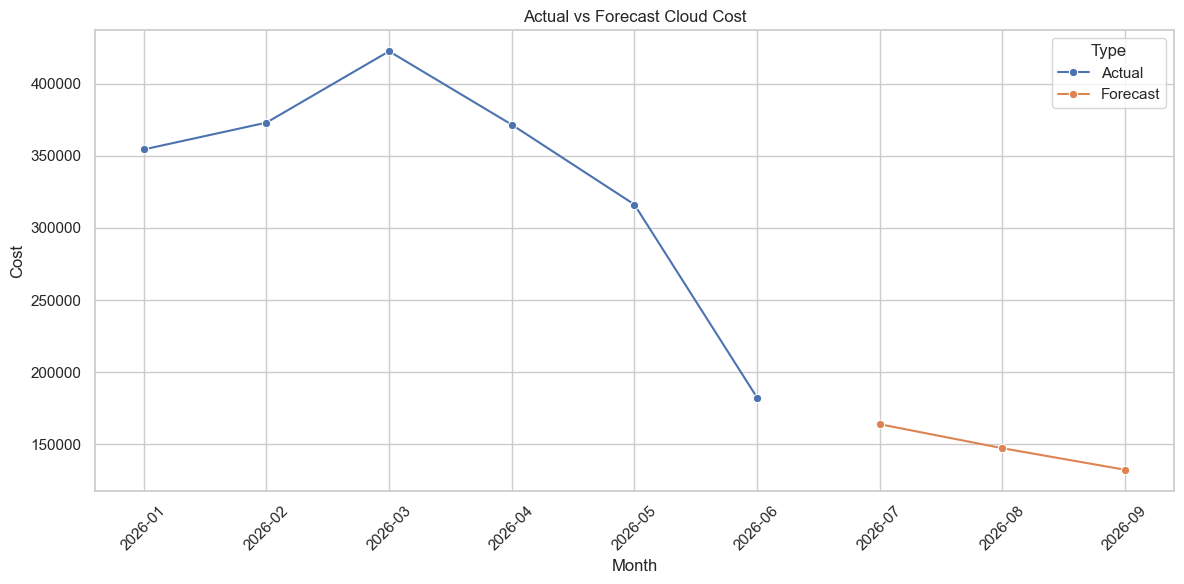

In [118]:
# Actual vs Forecast
forecast_plot = pd.concat([
    monthly_cost[["Month", "Monthly_Cost"]].rename(
        columns={"Monthly_Cost": "Cost"}
    ),
    forecast_df.rename(
        columns={"Forecast_Cost": "Cost"}
    )
])

forecast_plot["Type"] = ( ["Actual"] * len(monthly_cost) + ["Forecast"] * len(forecast_df) )

plt.figure(figsize=(12,6))

sns.lineplot( data=forecast_plot, x="Month", y="Cost", hue="Type", marker="o" )

plt.title("Actual vs Forecast Cloud Cost")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

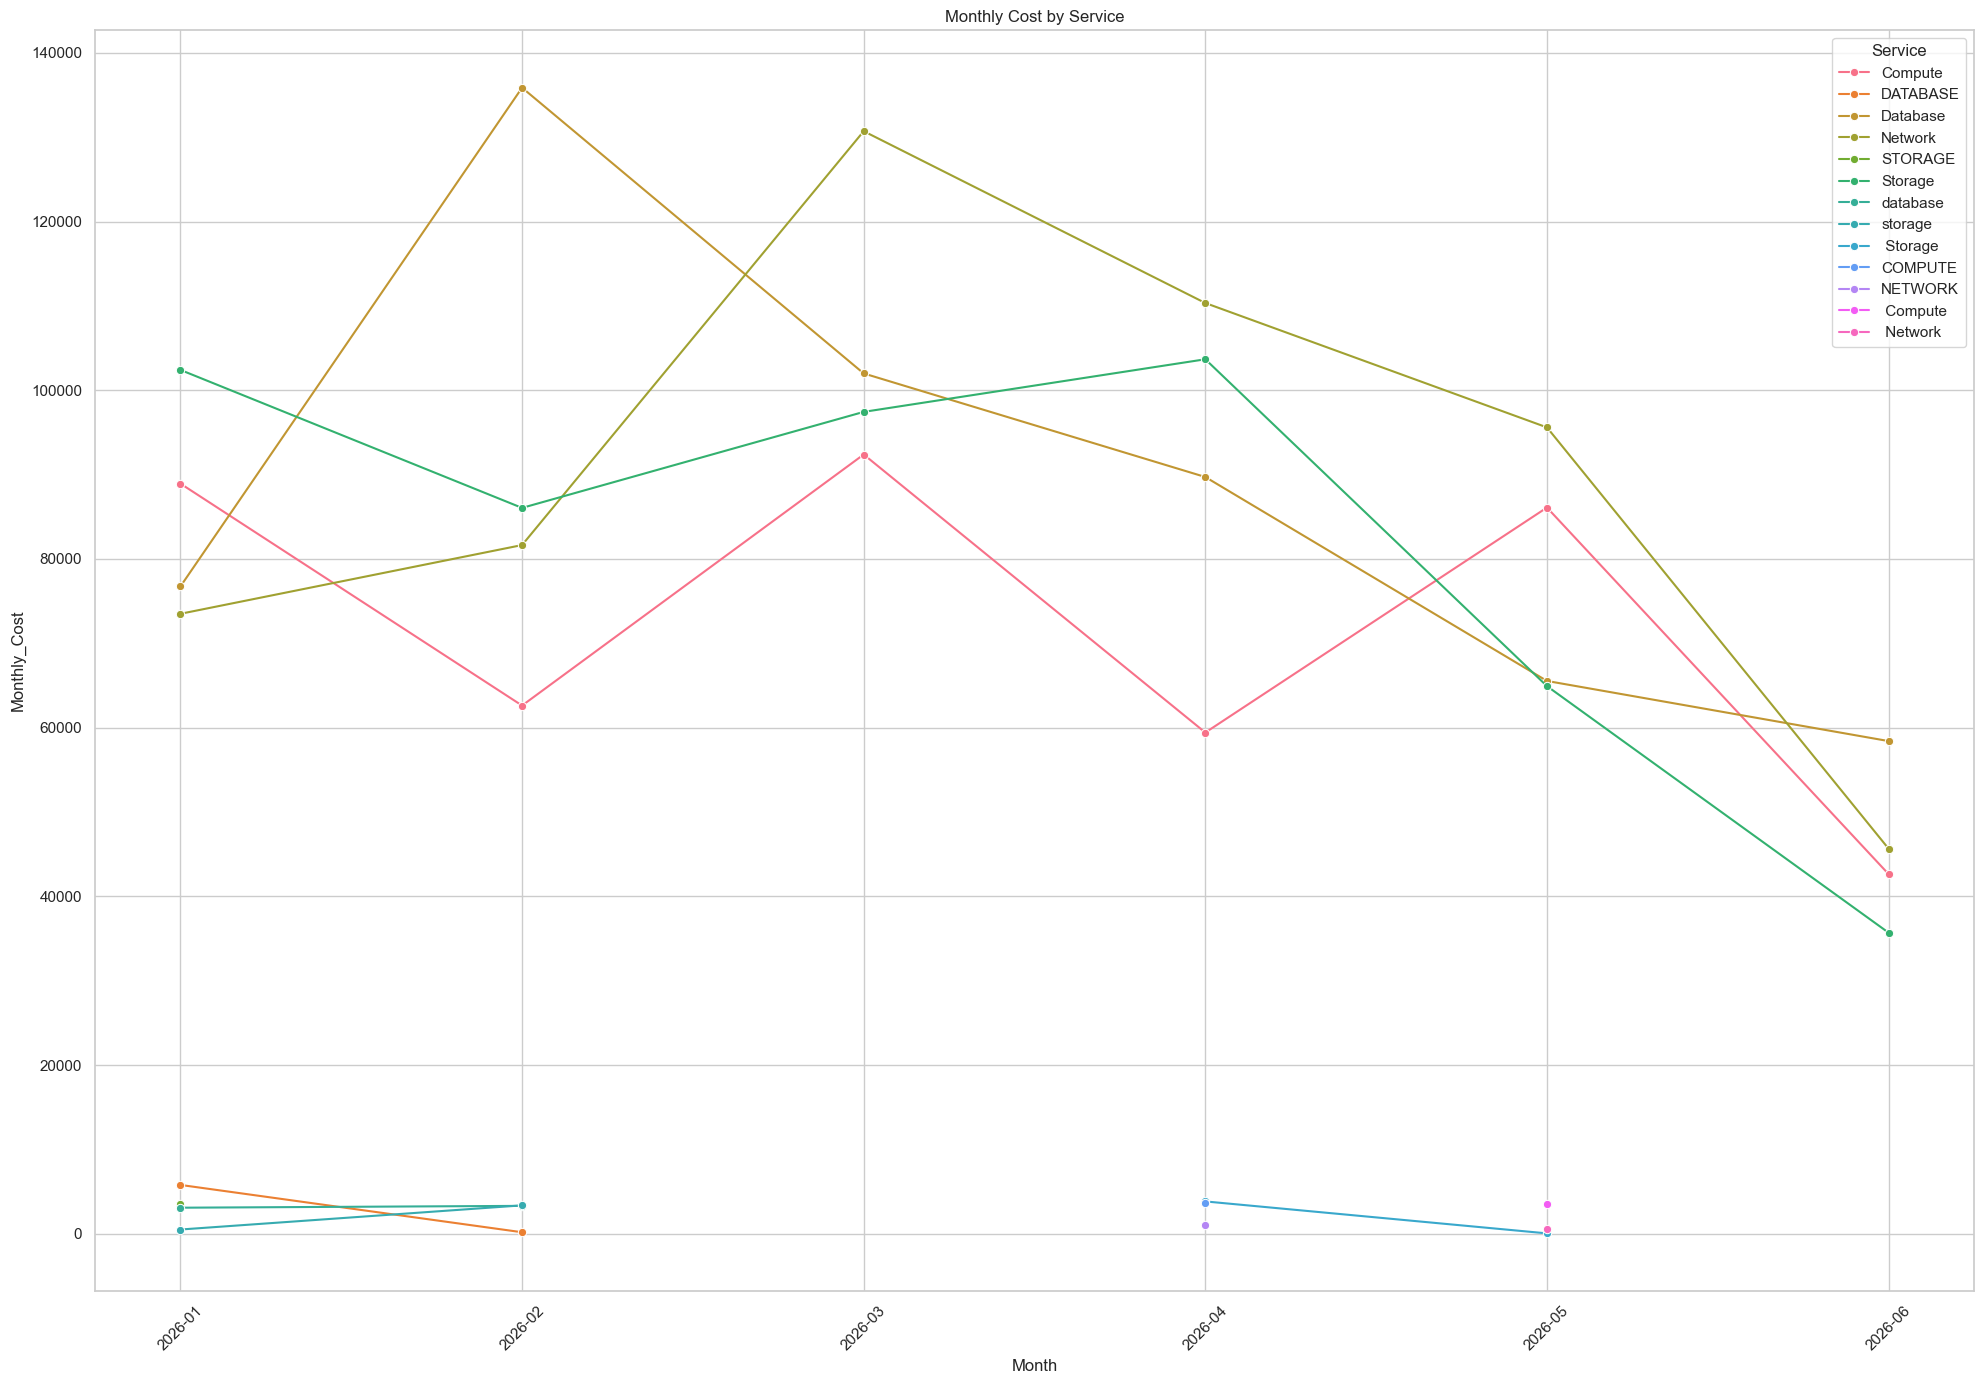

In [120]:
# Service-wise Monthly Cost
service_month = (
    billing
    .groupby(
        ["Month", "Service"],
        as_index=False
    )
    .agg(
        Monthly_Cost=("Cost", "sum")
    )
)

plt.figure(figsize=(20,14))

sns.lineplot( data=service_month, x="Month", y="Monthly_Cost", hue="Service", marker="o" )

plt.title("Monthly Cost by Service")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

TC : 11 Tag completeness scorecards.
-------------------------------------

In [121]:
tag_columns = [ "Account", "Region", "Owner", "Environment", "Purchase_Type", "Status" ]

In [122]:
# Calculate Tag Completeness Score
resource["Tags_Present"] = ( resource[tag_columns].notna().sum(axis=1) )

resource["Tag_Completeness_%"] = ( resource["Tags_Present"] / len(tag_columns) ) * 100

In [123]:
# Storage Category
def scorecard(score):

    if score == 100:
        return "Excellent"

    elif score >= 80:
        return "Good"

    elif score >= 60:
        return "Average"

    else:
        return "Poor"

resource["Tag_Status"] = ( resource["Tag_Completeness_%"].apply(scorecard) )

In [124]:
print(
    resource[
        [
            "Resource_ID",
            "Tag_Completeness_%",
            "Tag_Status"
        ]
    ].head()
)

  Resource_ID  Tag_Completeness_% Tag_Status
0    VM100001          100.000000  Excellent
1    VM100002          100.000000  Excellent
2    VM100003           83.333333       Good
3    VM100004          100.000000  Excellent
4    VM100005          100.000000  Excellent


In [125]:
# Overall Tag Scorecard

scorecard_summary = (
    resource
    .groupby("Tag_Status", as_index=False)
    .agg(
        Resource_Count=("Resource_ID", "count")
    )
)

print(scorecard_summary)

  Tag_Status  Resource_Count
0  Excellent             299
1       Good               2


In [132]:
# Region-wise Tag Completeness
region_score = (
    resource
    .groupby("Region", as_index=False)
    .agg(
        Average_Tag_Score=("Tag_Completeness_%", "mean")
    )
)

# Environment Score
environment_score = (
    resource
    .groupby("Environment", as_index=False)
    .agg(
        Average_Tag_Score=("Tag_Completeness_%", "mean")
    )
)

print(environment_score)

print(region_score)

  Environment  Average_Tag_Score
0        Dev          100.000000
1       Prod          100.000000
2         DEV         100.000000
3         Dev         100.000000
4        PROD         100.000000
5        Prod         100.000000
6          QA          99.828179
7         dev          83.333333
8        prod         100.000000
9          qa         100.000000
         Region  Average_Tag_Score
0   ap-south-1          100.000000
1    us-east-1          100.000000
2    AP-SOUTH-1          91.666667
3     EU-WEST-1         100.000000
4     US-EAST-1         100.000000
5    ap-south-1          99.818841
6     eu-west-1         100.000000
7     us-east-1         100.000000


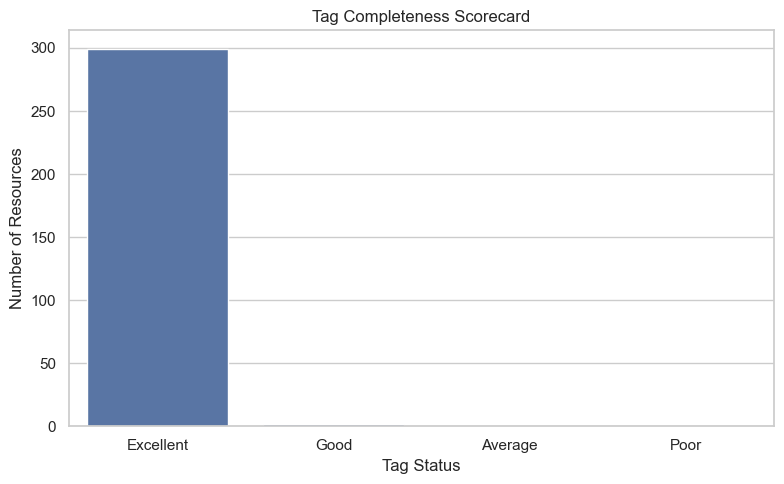

In [128]:
# Tag Score Distribution
plt.figure(figsize=(8,5))

sns.countplot( data=resource, x="Tag_Status",
    order=["Excellent", "Good", "Average", "Poor"]
)

plt.title("Tag Completeness Scorecard")

plt.xlabel("Tag Status")

plt.ylabel("Number of Resources")

plt.tight_layout()

plt.show()

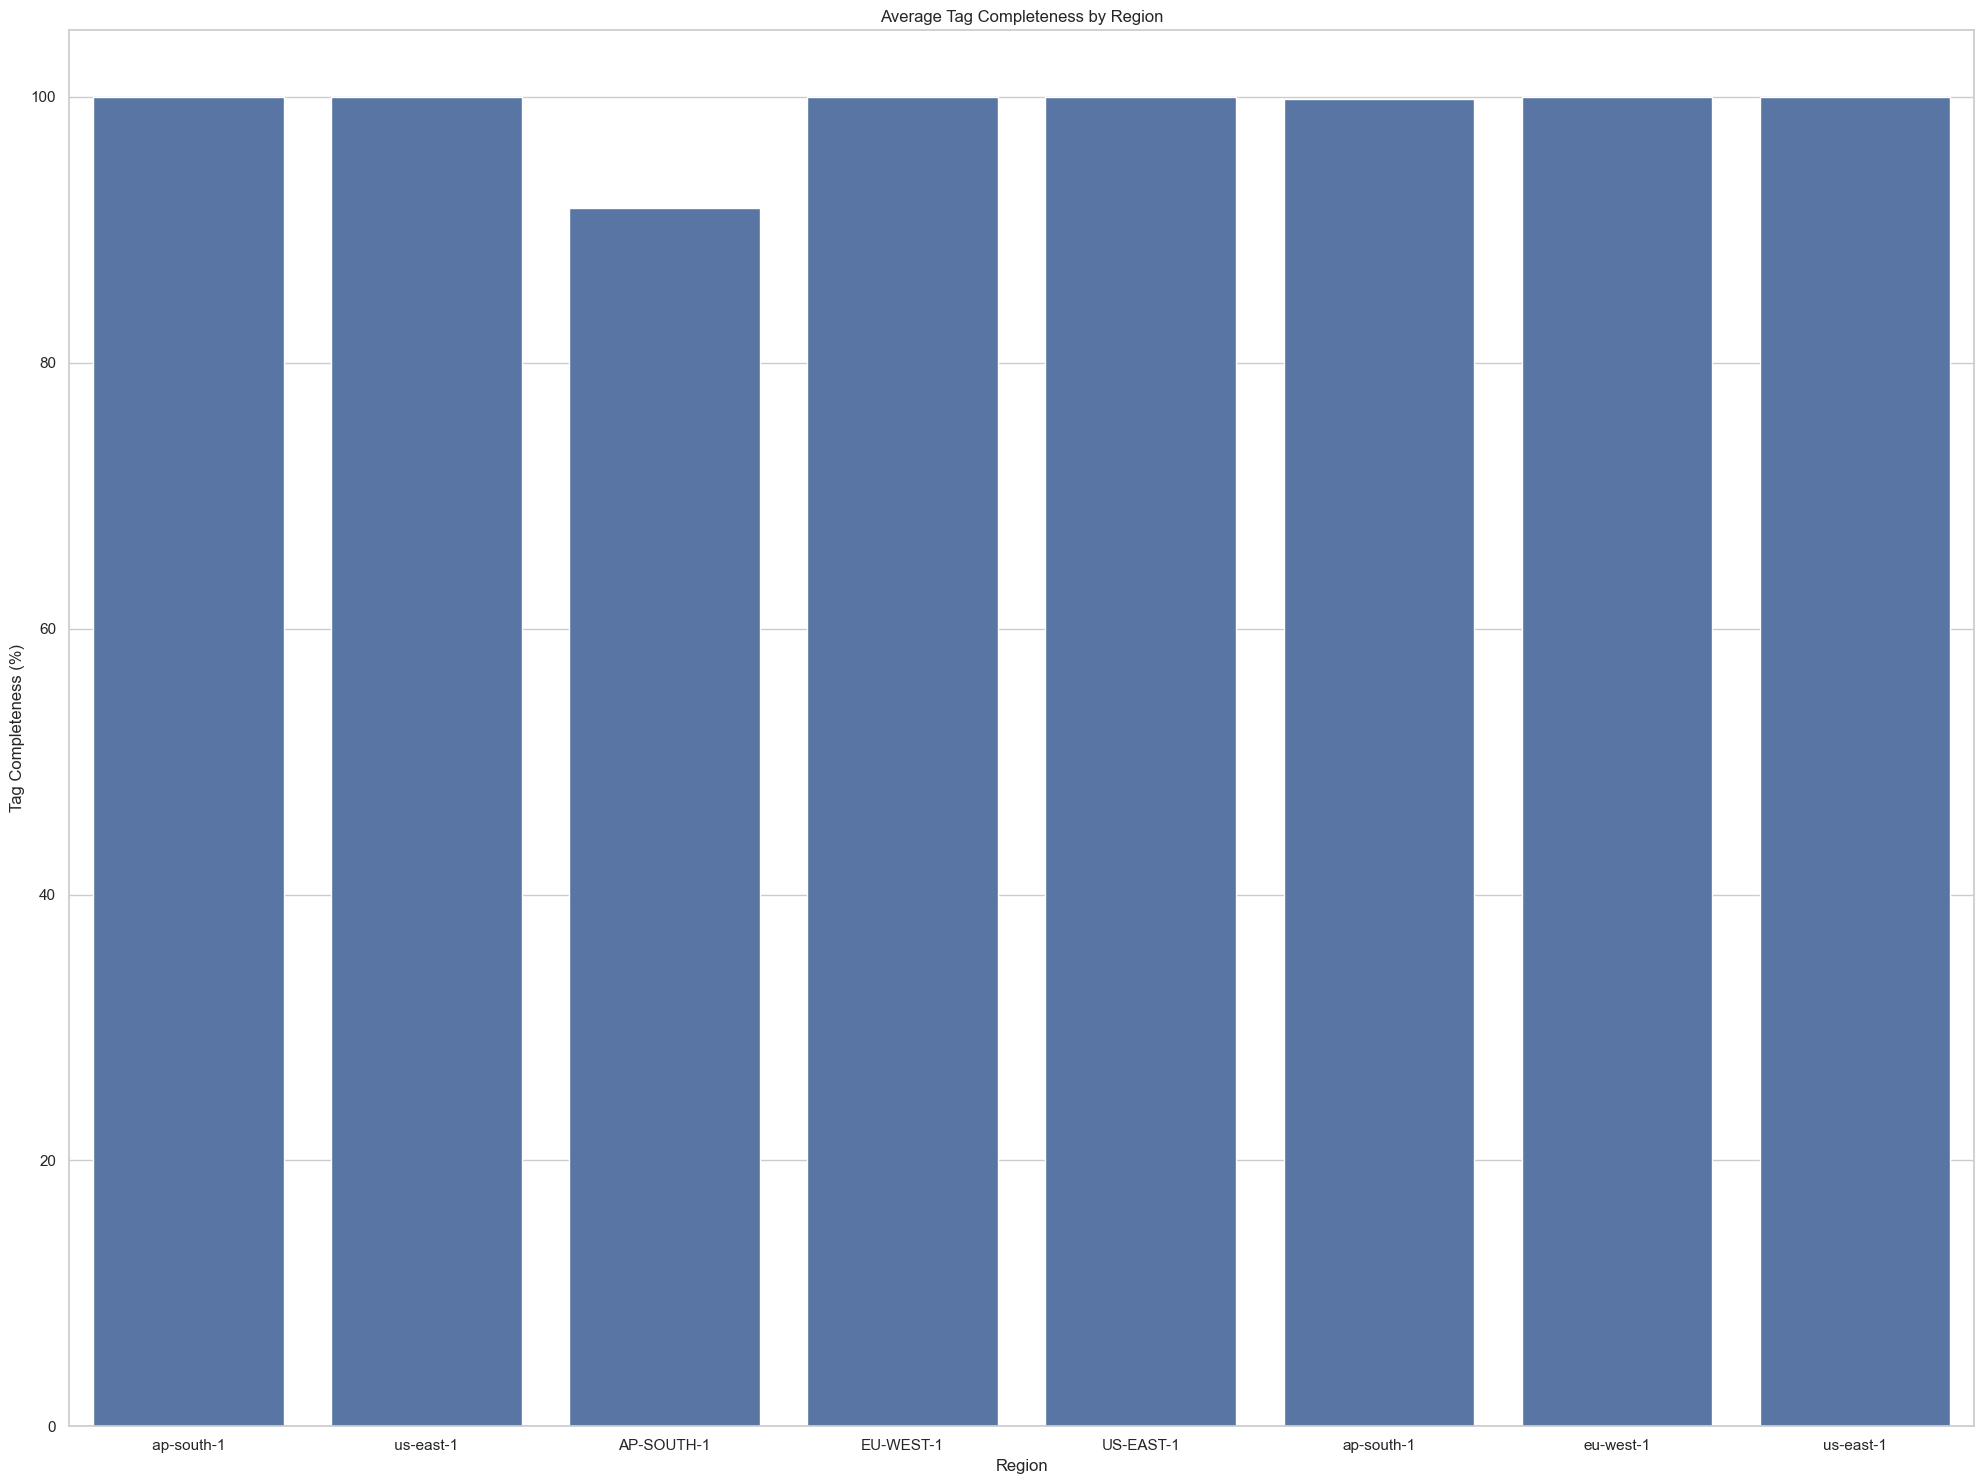

In [130]:
# Average Tag Score by Region
plt.figure(figsize=(20,15))

sns.barplot(
    data=region_score,
    x="Region",
    y="Average_Tag_Score"
)

plt.title("Average Tag Completeness by Region")

plt.ylabel("Tag Completeness (%)")

plt.tight_layout()

plt.show()

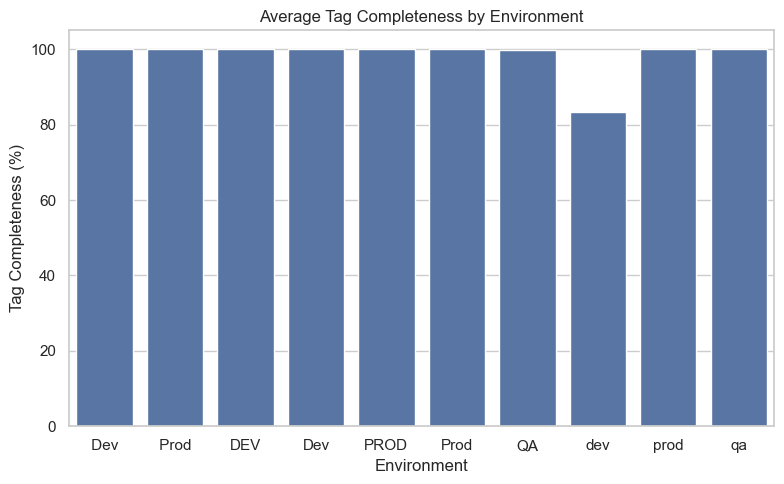

In [133]:
# Average Tag Score by Environment
plt.figure(figsize=(8,5))

sns.barplot(
    data=environment_score,
    x="Environment",
    y="Average_Tag_Score"
)

plt.title("Average Tag Completeness by Environment")

plt.ylabel("Tag Completeness (%)")

plt.tight_layout()

plt.show()

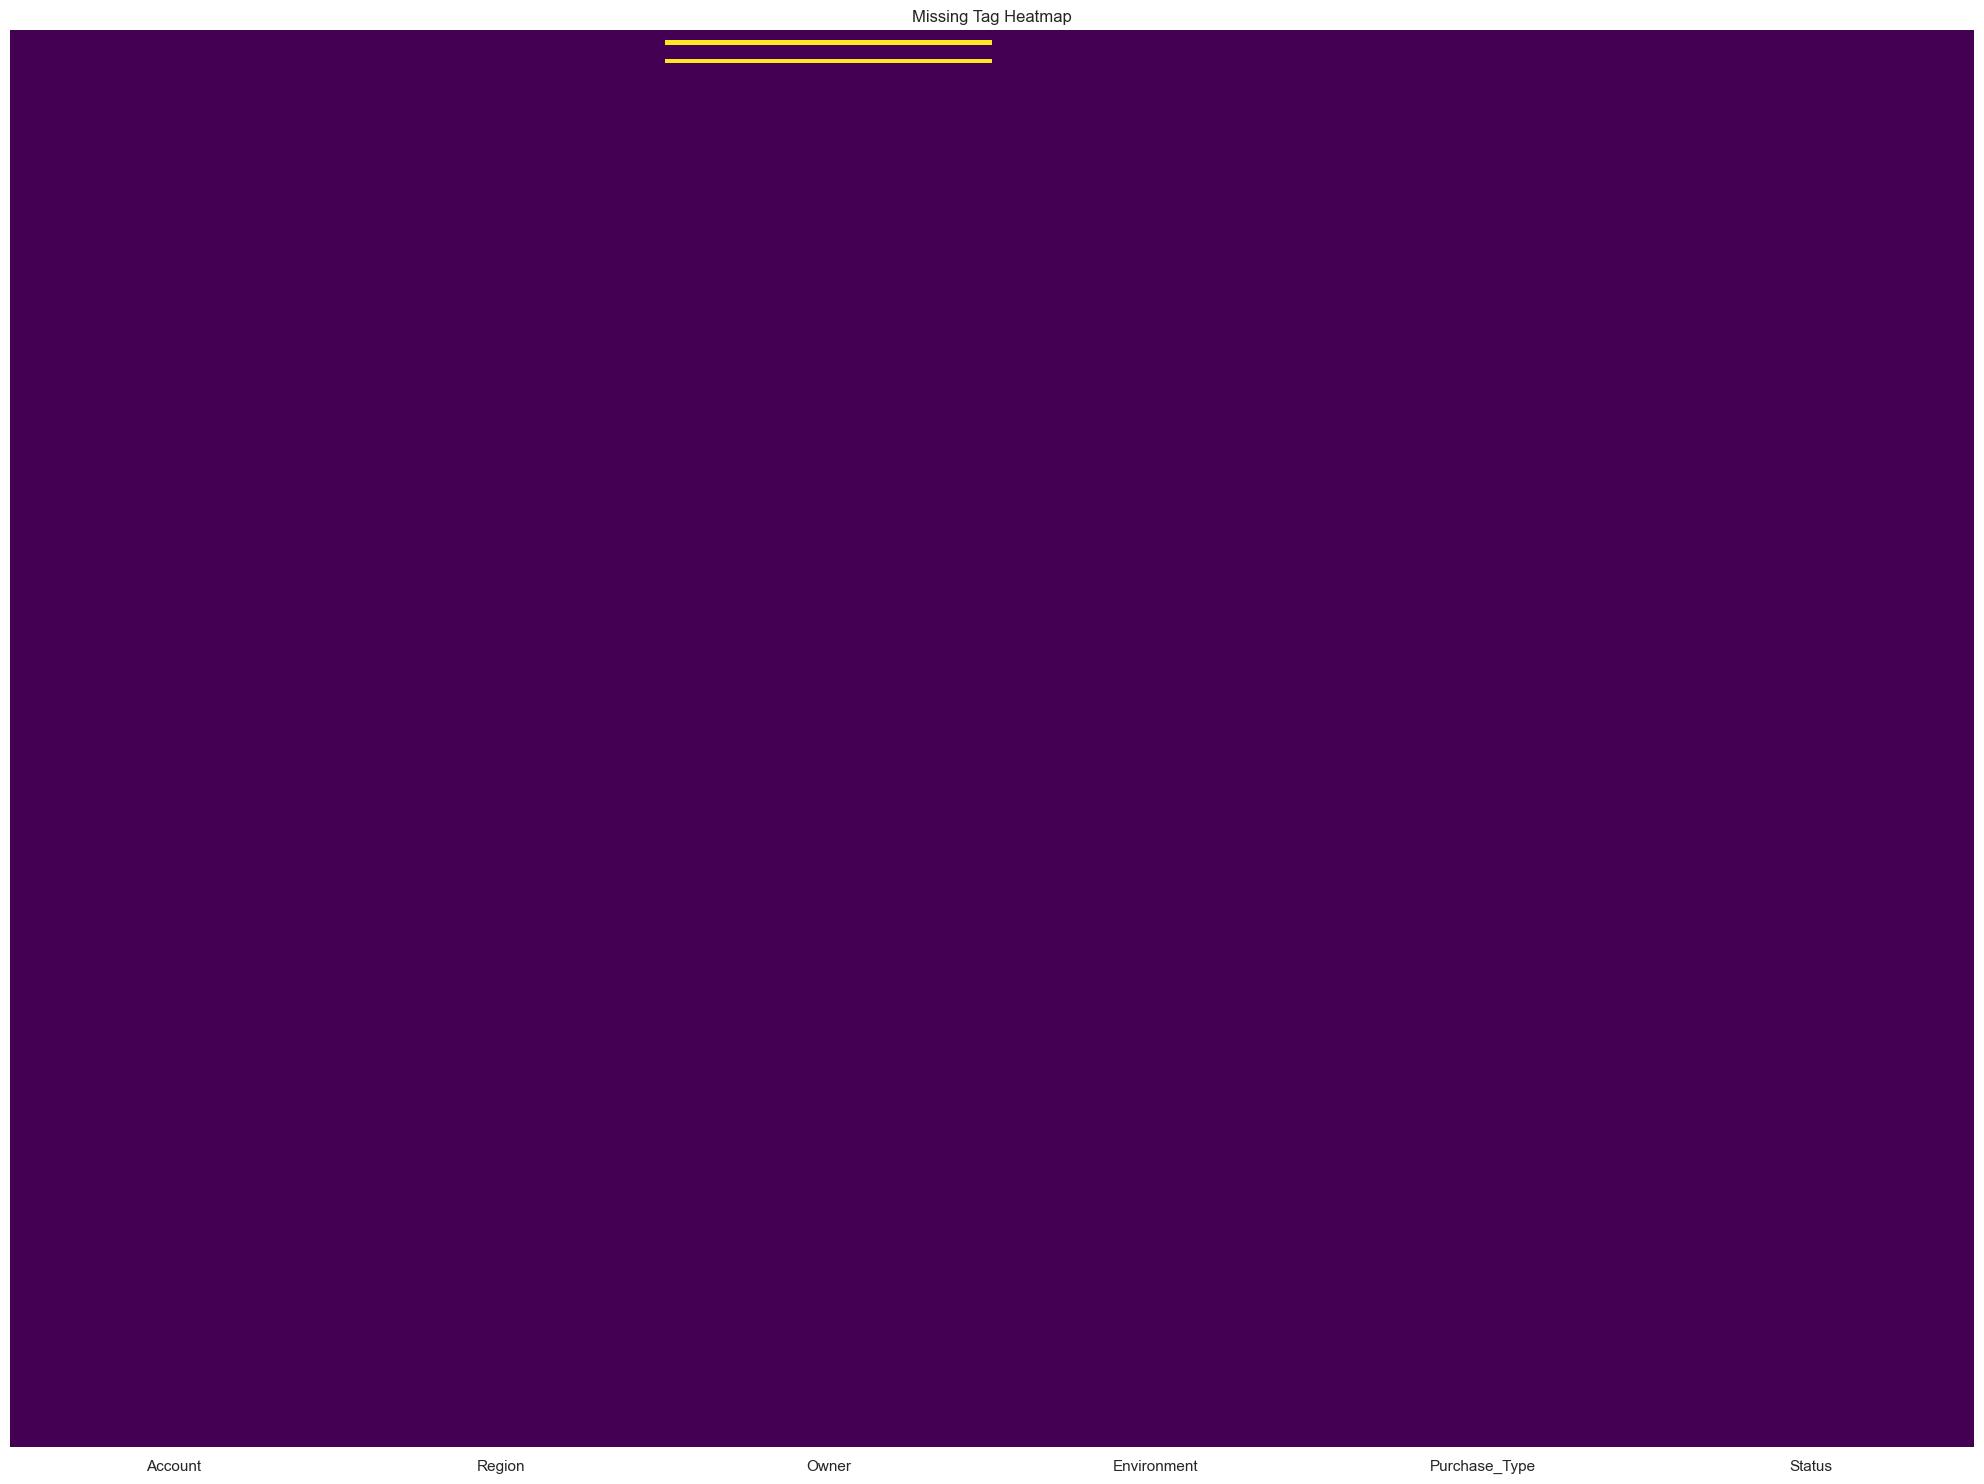

In [135]:
# Heatmap of Missing Values
plt.figure(figsize=(20,15))

sns.heatmap(
    resource[tag_columns].isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Tag Heatmap")

plt.tight_layout()

plt.show()

In [136]:
resource.to_csv(
    "Tag_Completeness_Report.csv",
    index=False
)

scorecard_summary.to_csv(
    "Tag_Scorecard_Summary.csv",
    index=False
)

region_score.to_csv(
    "Region_Tag_Score.csv",
    index=False
)

TC : 12 FinOps KPIs (Blended rate, Effective discounts).
----------------------------------------------------------

In [180]:
billing["TS"] = pd.to_datetime(billing["TS"])

billing["Month"] = billing["TS"].dt.to_period("M").astype(str)


In [184]:
billing["Cost"] = pd.to_numeric(billing["Cost"], errors="coerce")

billing["Credit_Amount"] = pd.to_numeric(
    billing["Credit_Amount"],
    errors="coerce"
)


billing["Net_Cost"] = (
    billing["Cost"] +
    billing["Credit_Amount"]
)

In [185]:
# Calculate Blended Rate 
billing["Blended_Rate"] = (
    billing["Net_Cost"] /
    billing["Usage"]
)

billing["Blended_Rate"] = (
    billing["Blended_Rate"]
    .replace([np.inf, -np.inf], np.nan)
)

In [188]:
# Effective Discount
billing["Effective_Discount_%"] = ( billing["Credit_Amount"] / billing["Cost"] ) * 100

billing["Effective_Discount_%"] = ( billing["Effective_Discount_%"].fillna(0).round(2) )

# Monthly finOps KPI
monthly_kpi = ( billing.groupby("Month", as_index=False).agg( Total_Cost=("Cost","sum"),
        Net_Cost=("Net_Cost","sum"),
        Total_Credits=("Credit_Amount","sum"),
        Total_Usage=("Usage","sum")
    ) )

monthly_kpi["Blended_Rate"] = ( monthly_kpi["Net_Cost"] / monthly_kpi["Total_Usage"] )

# Servicewisw KPI
service_kpi = ( billing.groupby("Service", as_index=False).agg( Total_Cost=("Cost","sum"),
        Net_Cost=("Net_Cost","sum"),
        Credits=("Credit_Amount","sum"),
        Usage=("Usage","sum")
    ) )

service_kpi["Blended_Rate"] = ( service_kpi["Net_Cost"] / service_kpi["Usage"] )

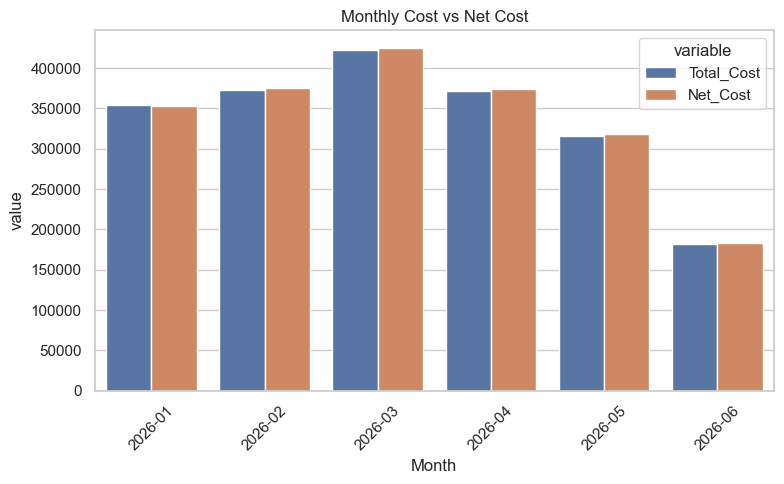

In [191]:
# Monlthly Cost Vs Net Cost
plt.figure(figsize=(8,5))

monthly_plot = monthly_kpi.melt(
    id_vars="Month",
    value_vars=["Total_Cost","Net_Cost"]
)

sns.barplot(
    data=monthly_plot,
    x="Month",
    y="value",
    hue="variable"
)

plt.title("Monthly Cost vs Net Cost")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

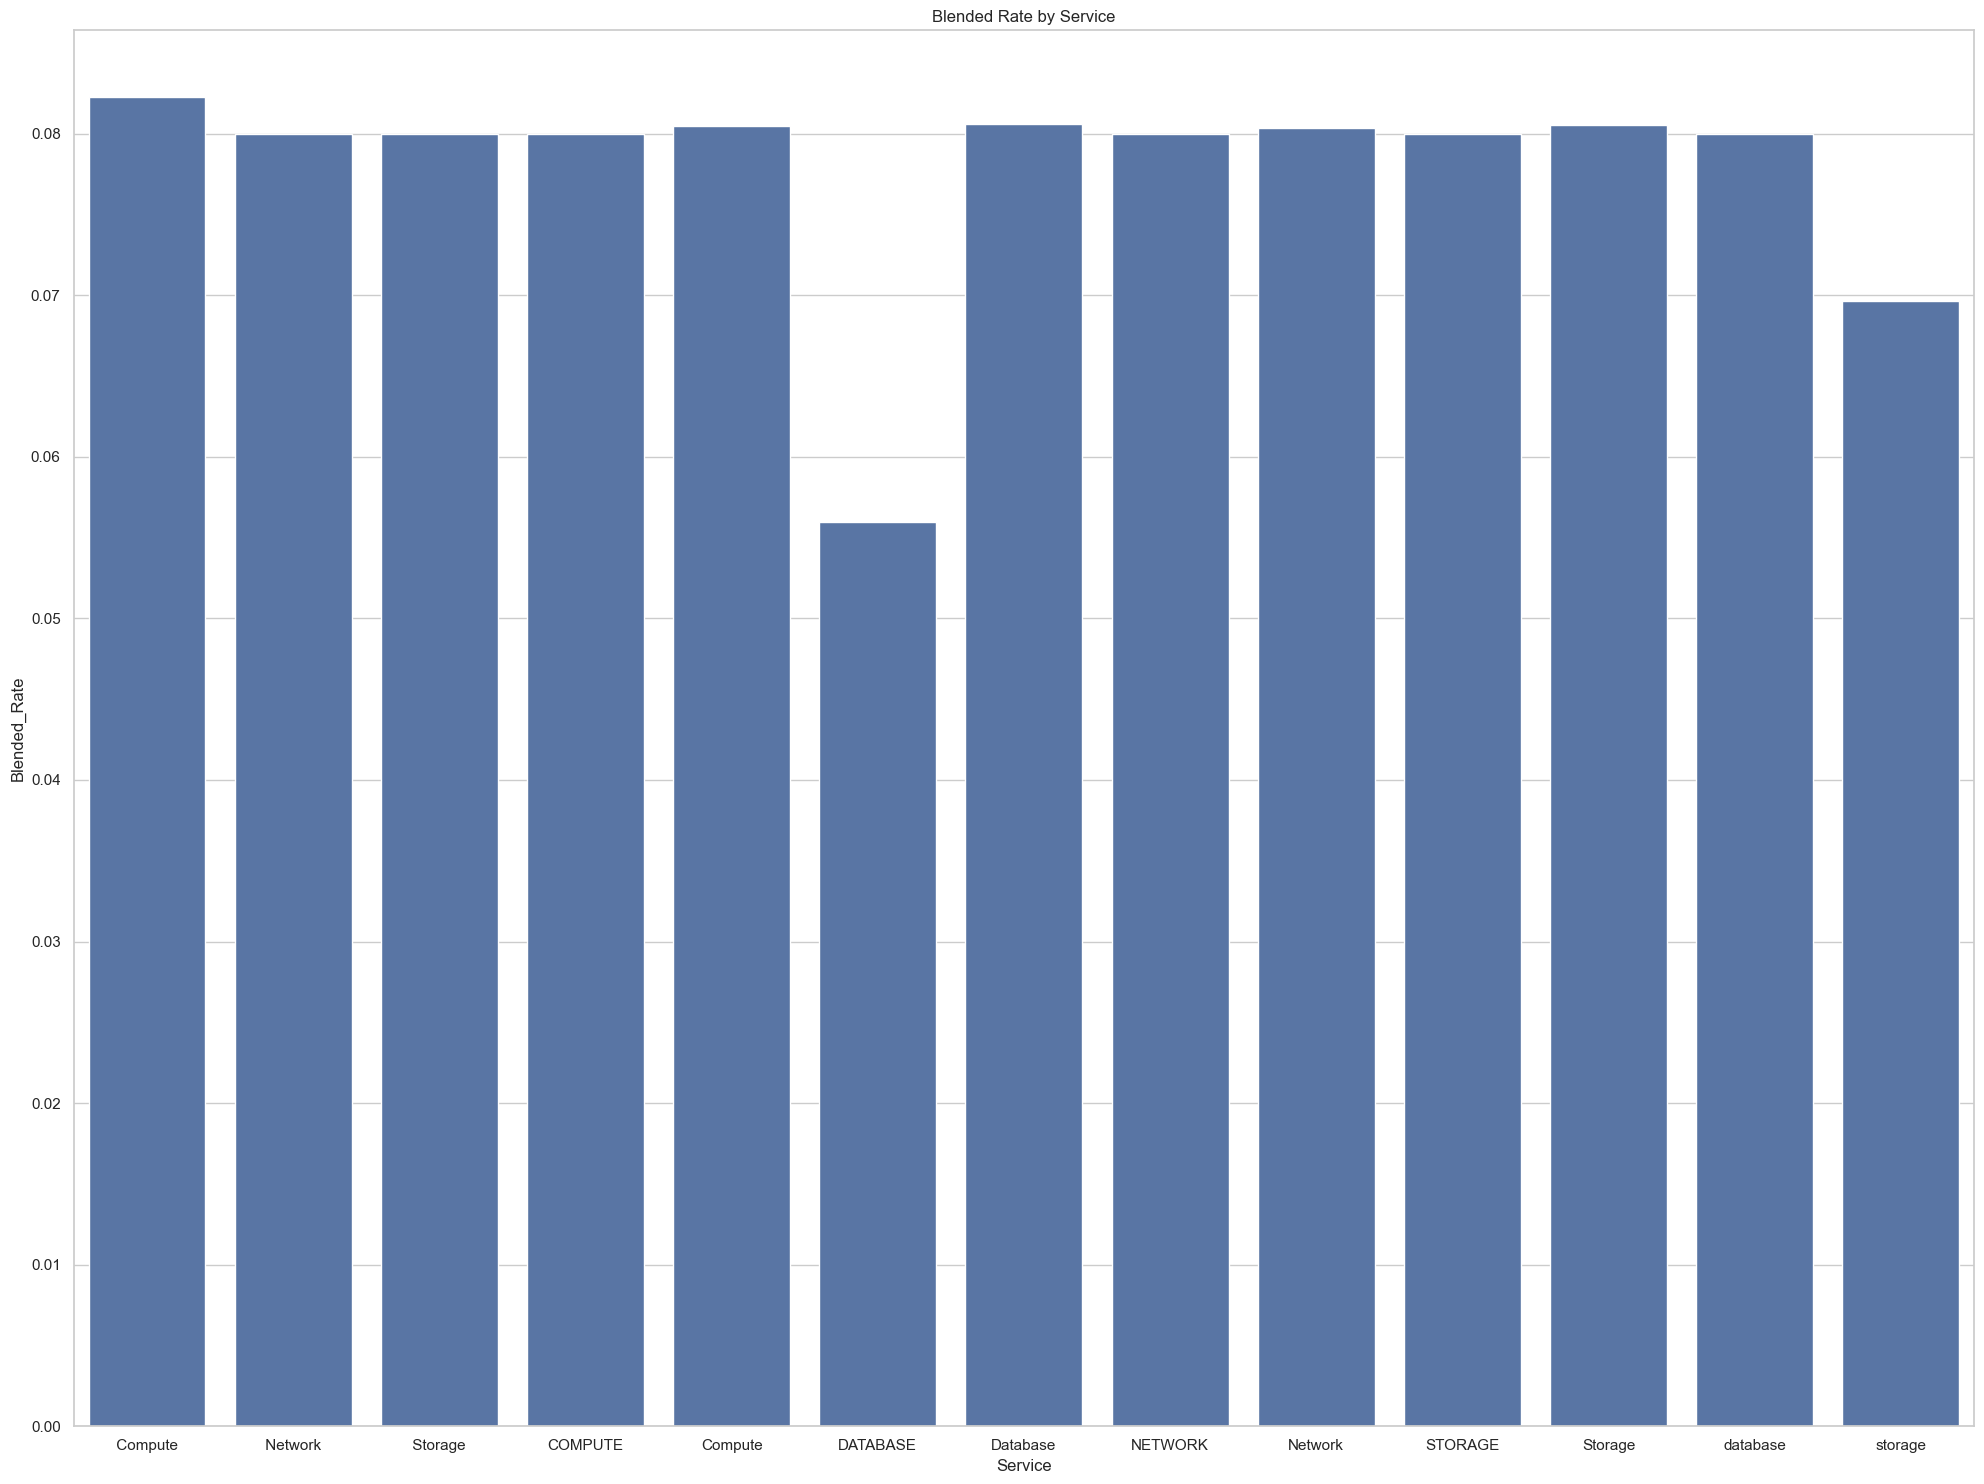

In [193]:
#  Blended rate by service
plt.figure(figsize=(20,15))

sns.barplot( data=service_kpi, x="Service", y="Blended_Rate" )

plt.title("Blended Rate by Service")

plt.tight_layout()

plt.show()

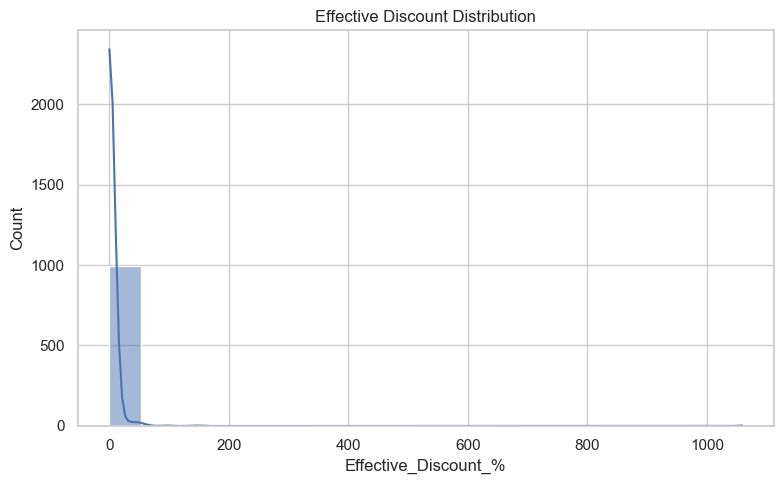

In [ ]:
# Effective Discount Distribution
plt.figure(figsize=(8,5))

sns.histplot( billing["Effective_Discount_%"], bins=20, kde=True )

plt.title("Effective Discount Distribution")

plt.tight_layout()

plt.show()

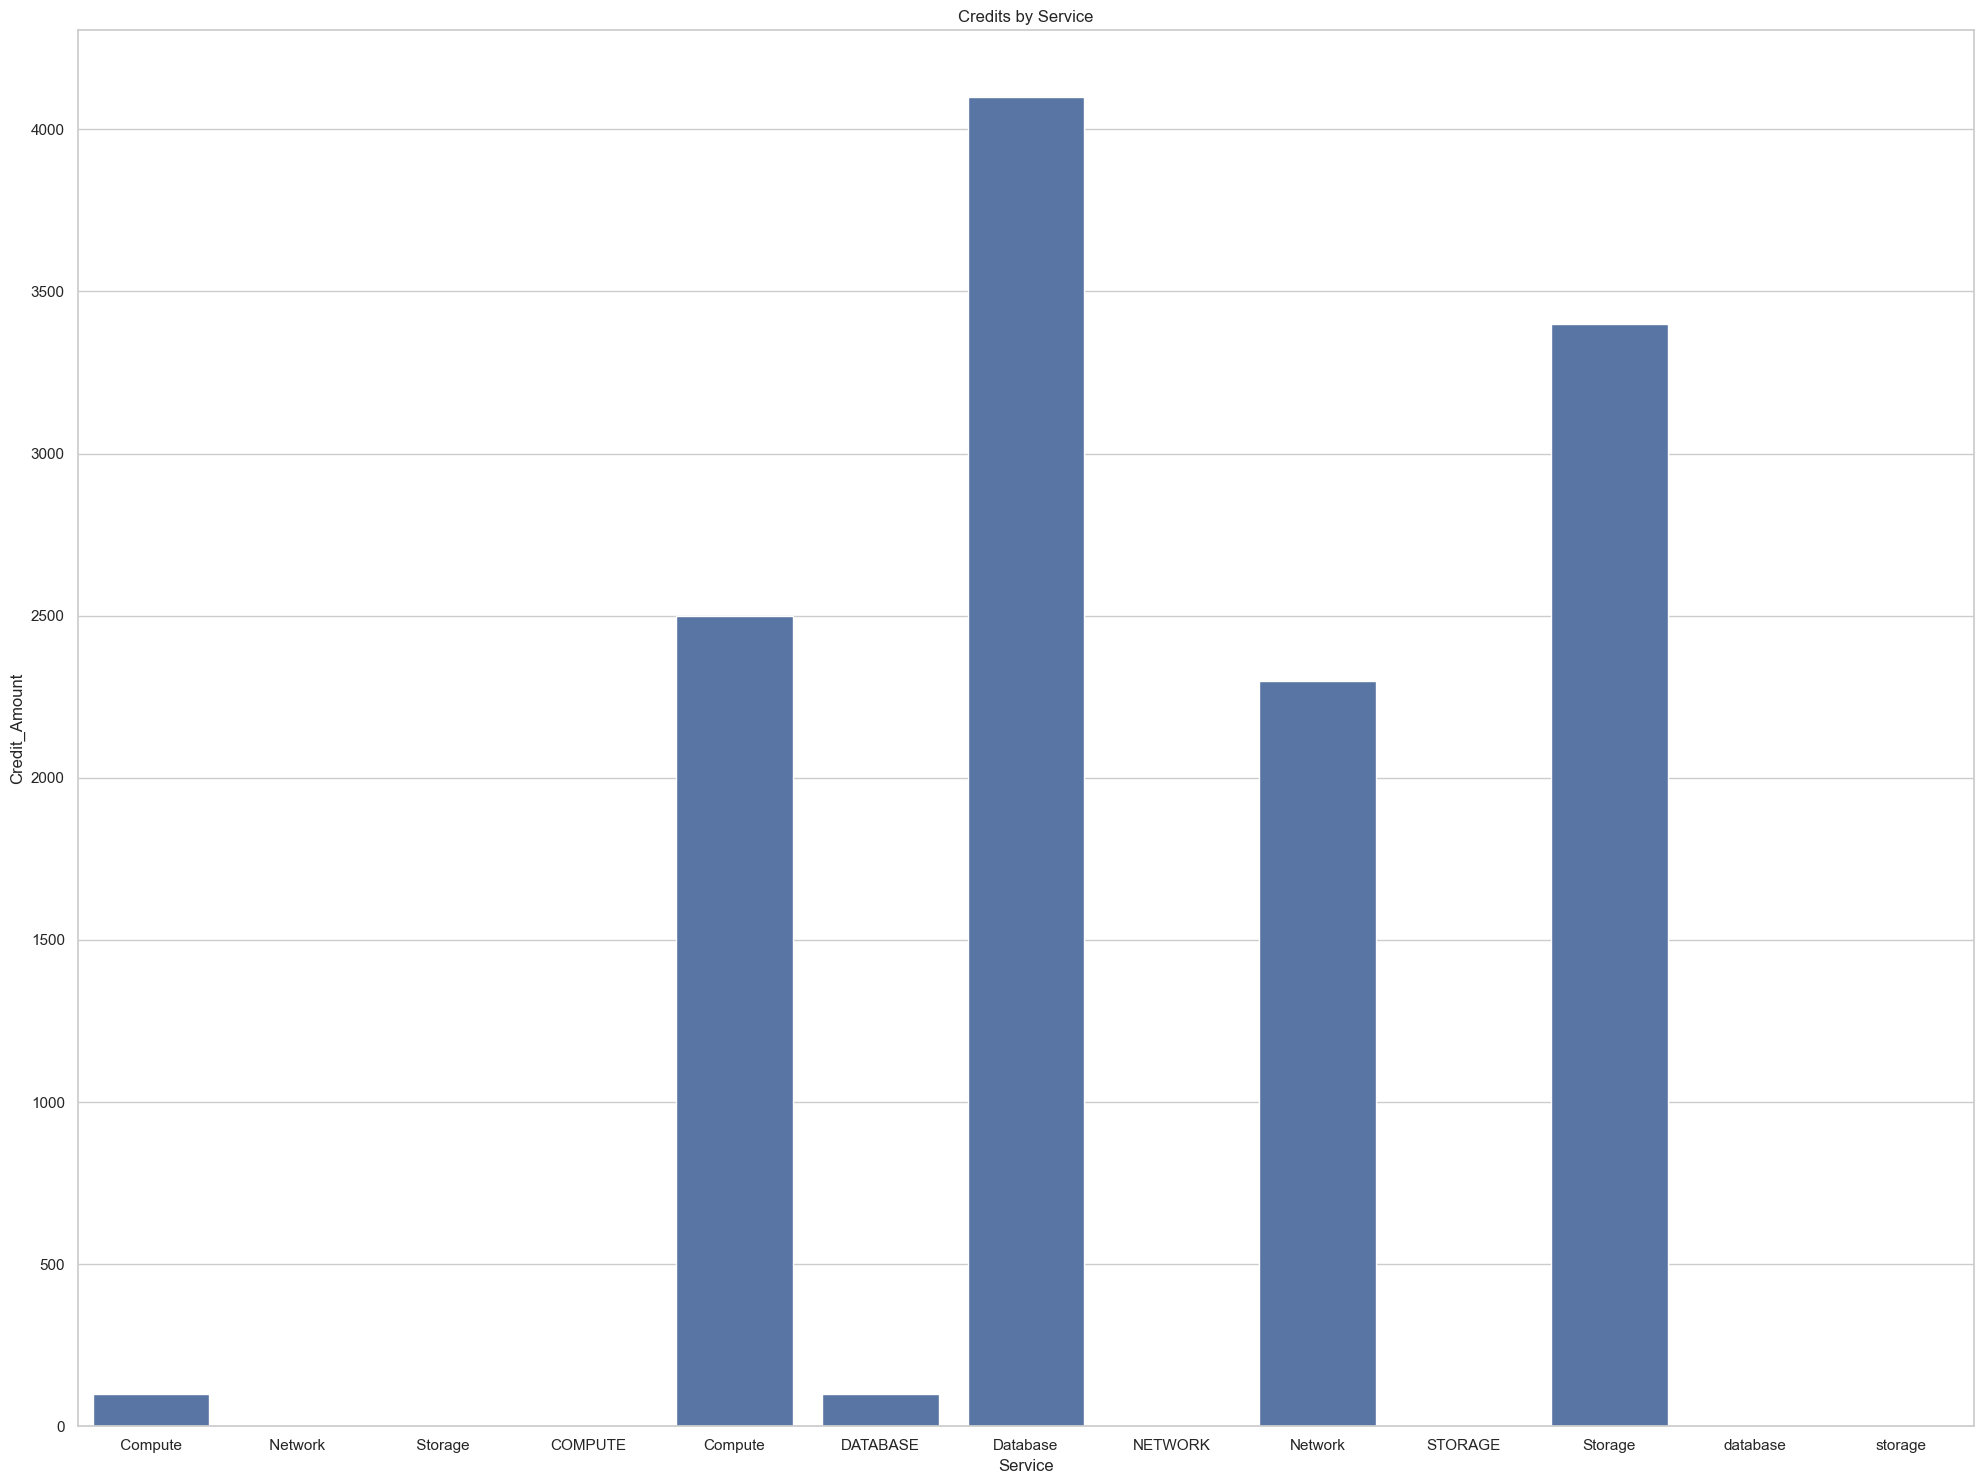

In [196]:
# Credits by service
credit_service = ( billing.groupby("Service")["Credit_Amount"].sum().reset_index() )

plt.figure(figsize=(20,15))

sns.barplot( data=credit_service, x="Service",  y="Credit_Amount" )

plt.title("Credits by Service")

plt.tight_layout()

plt.show()

TC : 13 Optimization opportunity backlog (snooze/commit).
-----------------------------------------------------------

In [197]:
optimization = billing.merge( resource, on=["Resource_ID", "Account"], how="left" )

In [199]:
# Creating Optimization Rules

conditions = [

    (
        (optimization["CPU_Utilization"] < 20) &
        (optimization["Memory_Utilization"] < 20)
    ),

    (
        (optimization["CPU_Utilization"] >= 20) &
        (optimization["CPU_Utilization"] < 40)
    )

]

choices = [
    "Commit",
    "Snooze"
]

optimization["Recommendation"] = np.select(
    conditions,
    choices,
    default="Healthy"
)

In [200]:
# Add Priority
priority_map = {
    "Commit": "High",
    "Snooze": "Medium",
    "Healthy": "Low"
}

optimization["Priority"] = (
    optimization["Recommendation"]
    .map(priority_map)
)


In [201]:
# Monthly Savings
optimization["Estimated_Savings"] = np.select(

    [
        optimization["Recommendation"] == "Commit",
        optimization["Recommendation"] == "Snooze"
    ],

    [
        optimization["Cost"] * 0.30,
        optimization["Cost"] * 0.10
    ],

    default=0
)

In [202]:
# Summery
summary = (

    optimization

    .groupby("Recommendation", as_index=False)

    .agg(

        Resources=("Resource_ID","count"),

        Total_Cost=("Cost","sum"),

        Potential_Savings=("Estimated_Savings","sum")

    )

)

print(summary)

  Recommendation  Resources  Total_Cost  Potential_Savings
0        Healthy        999  2016932.88              0.000
1         Snooze          2     3240.64            324.064


In [204]:
# Service-wise Opportunities
service_summary = (
    optimization.groupby(
        ["Service","Recommendation"],
        as_index=False).agg( Resources=("Resource_ID","count"),Savings=("Estimated_Savings","sum")))

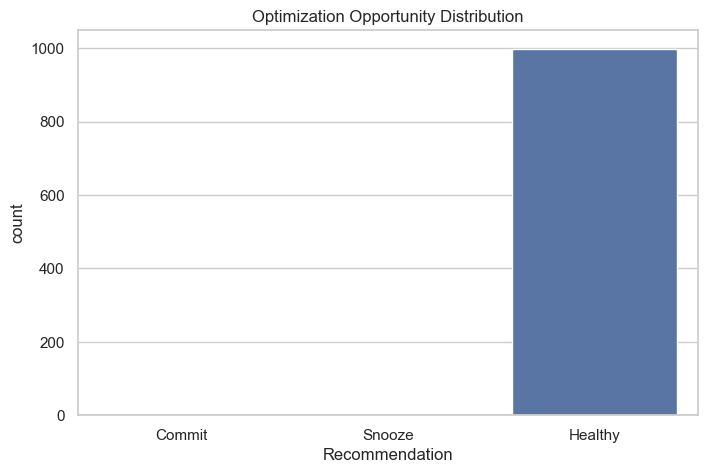

In [205]:
# Distribution
plt.figure(figsize=(8,5))

sns.countplot(data=optimization, x="Recommendation", order=["Commit","Snooze","Healthy"] )

plt.title("Optimization Opportunity Distribution")

plt.show()

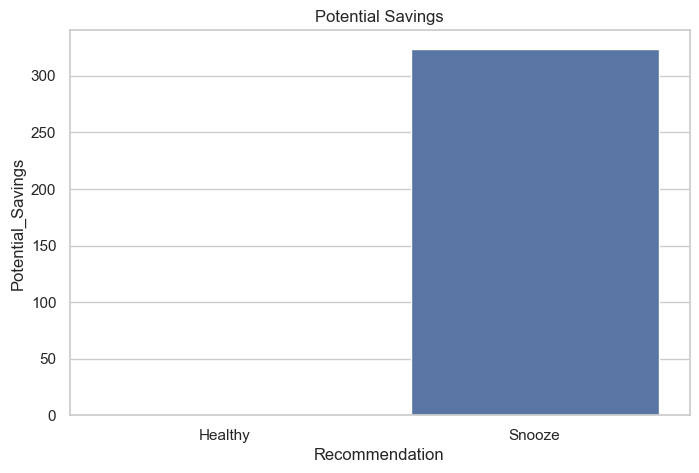

In [206]:
# Estimated Savings
plt.figure(figsize=(8,5))

sns.barplot( data=summary, x="Recommendation", y="Potential_Savings" )

plt.title("Potential Savings")

plt.show()

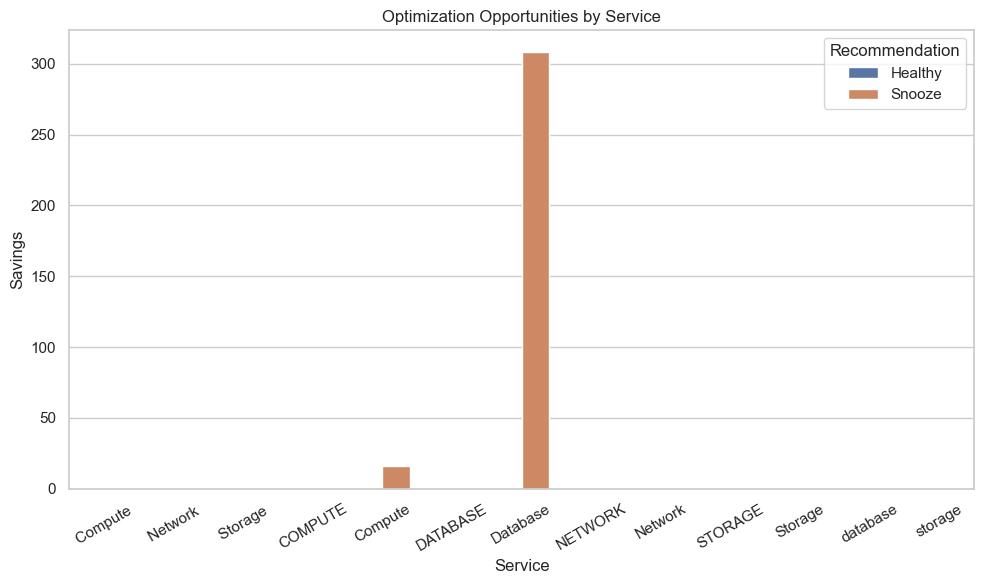

In [207]:
# Opportunities by Service

plt.figure(figsize=(10,6))

sns.barplot( data=service_summary, x="Service", y="Savings", hue="Recommendation")

plt.title("Optimization Opportunities by Service")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

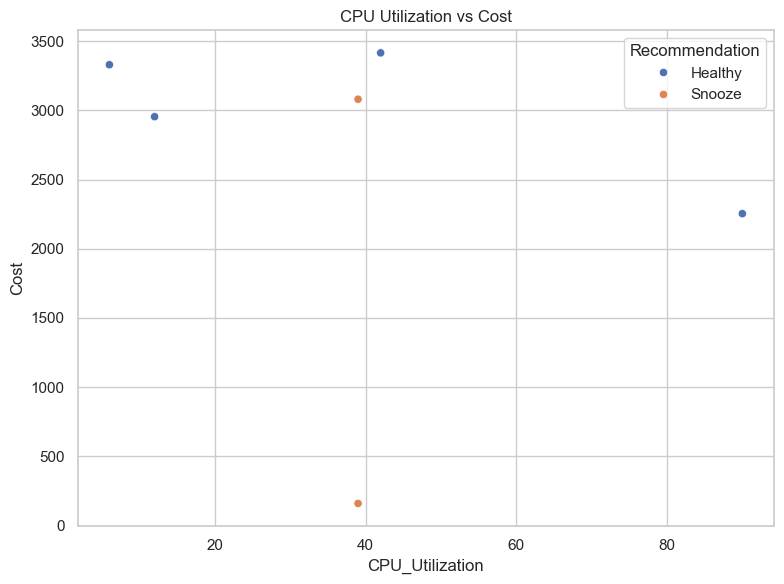

In [208]:
# CPU vs Cost
plt.figure(figsize=(8,6))

sns.scatterplot( data=optimization, x="CPU_Utilization", y="Cost", hue="Recommendation" )

plt.title("CPU Utilization vs Cost")

plt.tight_layout()

plt.show()

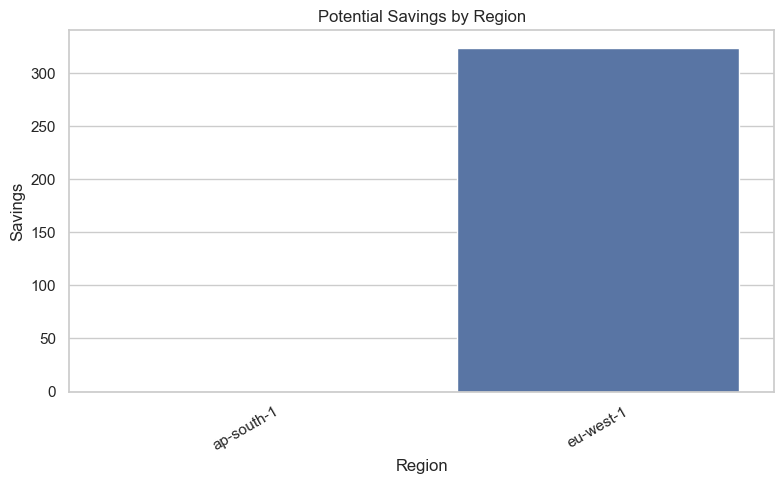

In [209]:
# Region-wise Savings
region_summary = (optimization.groupby("Region", as_index=False).agg( Savings=("Estimated_Savings","sum") ))

plt.figure(figsize=(8,5))

sns.barplot( data=region_summary, x="Region", y="Savings" )

plt.title("Potential Savings by Region")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

In [210]:
optimization.to_csv(
    "Optimization_Backlog.csv",
    index=False
)

summary.to_csv(
    "Optimization_Summary.csv",
    index=False
)

service_summary.to_csv(
    "Service_Optimization.csv",
    index=False
)

TS : 14. Benchmarks vs industry peers (if dataset available).
=============================================================

In [139]:
# Convert Cost into Numeric
billing["Cost"] = ( billing["Cost"].astype(str).str.replace(",", "", regex=False)
                    .str.replace("₹", "", regex=False)
                    .str.replace("$", "", regex=False)
                    .str.strip() )

billing["Cost"] = pd.to_numeric( billing["Cost"], errors="coerce" )
print(billing["Cost"].dtype)

# Calculate Your Company's Average Cost
company = (
    billing.groupby("Service", as_index=False)["Cost"]
    .mean()
)

company.rename(
    columns={"Cost": "Company_Avg_Cost"},
    inplace=True
)

print(company)

float64
      Service  Company_Avg_Cost
0    Compute        1169.120000
1    Network         537.520000
2    Storage        1936.360000
3     COMPUTE       3591.680000
4     Compute       1955.081629
5    DATABASE       1987.386667
6    Database       2104.579124
7     NETWORK       1050.480000
8     Network       2124.228300
9     STORAGE       3474.880000
10    Storage       1892.557838
11   database       2129.813333
12    storage       1931.320000


In [140]:
# Create Industry Benchmark Table
industry = pd.DataFrame({

    "Service": [
        "Compute",
        "Storage",
        "Database",
        "Network"
    ],

    "Industry_Avg_Cost": [
        1200,
        900,
        1500,
        700
    ]
})

print(industry)

    Service  Industry_Avg_Cost
0   Compute               1200
1   Storage                900
2  Database               1500
3   Network                700


In [141]:
# Create Benchmark DataFrame
benchmark = pd.merge(
    company,
    industry,
    on="Service",
    how="left"
)

benchmark["Difference"] = (
    benchmark["Company_Avg_Cost"]
    - benchmark["Industry_Avg_Cost"]
)

benchmark["Performance"] = benchmark["Difference"].apply(
    lambda x: "Above Benchmark" if x > 0 else "Below Benchmark"
)

print(benchmark)

      Service  Company_Avg_Cost  Industry_Avg_Cost   Difference  \
0    Compute        1169.120000                NaN          NaN   
1    Network         537.520000                NaN          NaN   
2    Storage        1936.360000                NaN          NaN   
3     COMPUTE       3591.680000                NaN          NaN   
4     Compute       1955.081629             1200.0   755.081629   
5    DATABASE       1987.386667                NaN          NaN   
6    Database       2104.579124             1500.0   604.579124   
7     NETWORK       1050.480000                NaN          NaN   
8     Network       2124.228300              700.0  1424.228300   
9     STORAGE       3474.880000                NaN          NaN   
10    Storage       1892.557838              900.0   992.557838   
11   database       2129.813333                NaN          NaN   
12    storage       1931.320000                NaN          NaN   

        Performance  
0   Below Benchmark  
1   Below Benchma

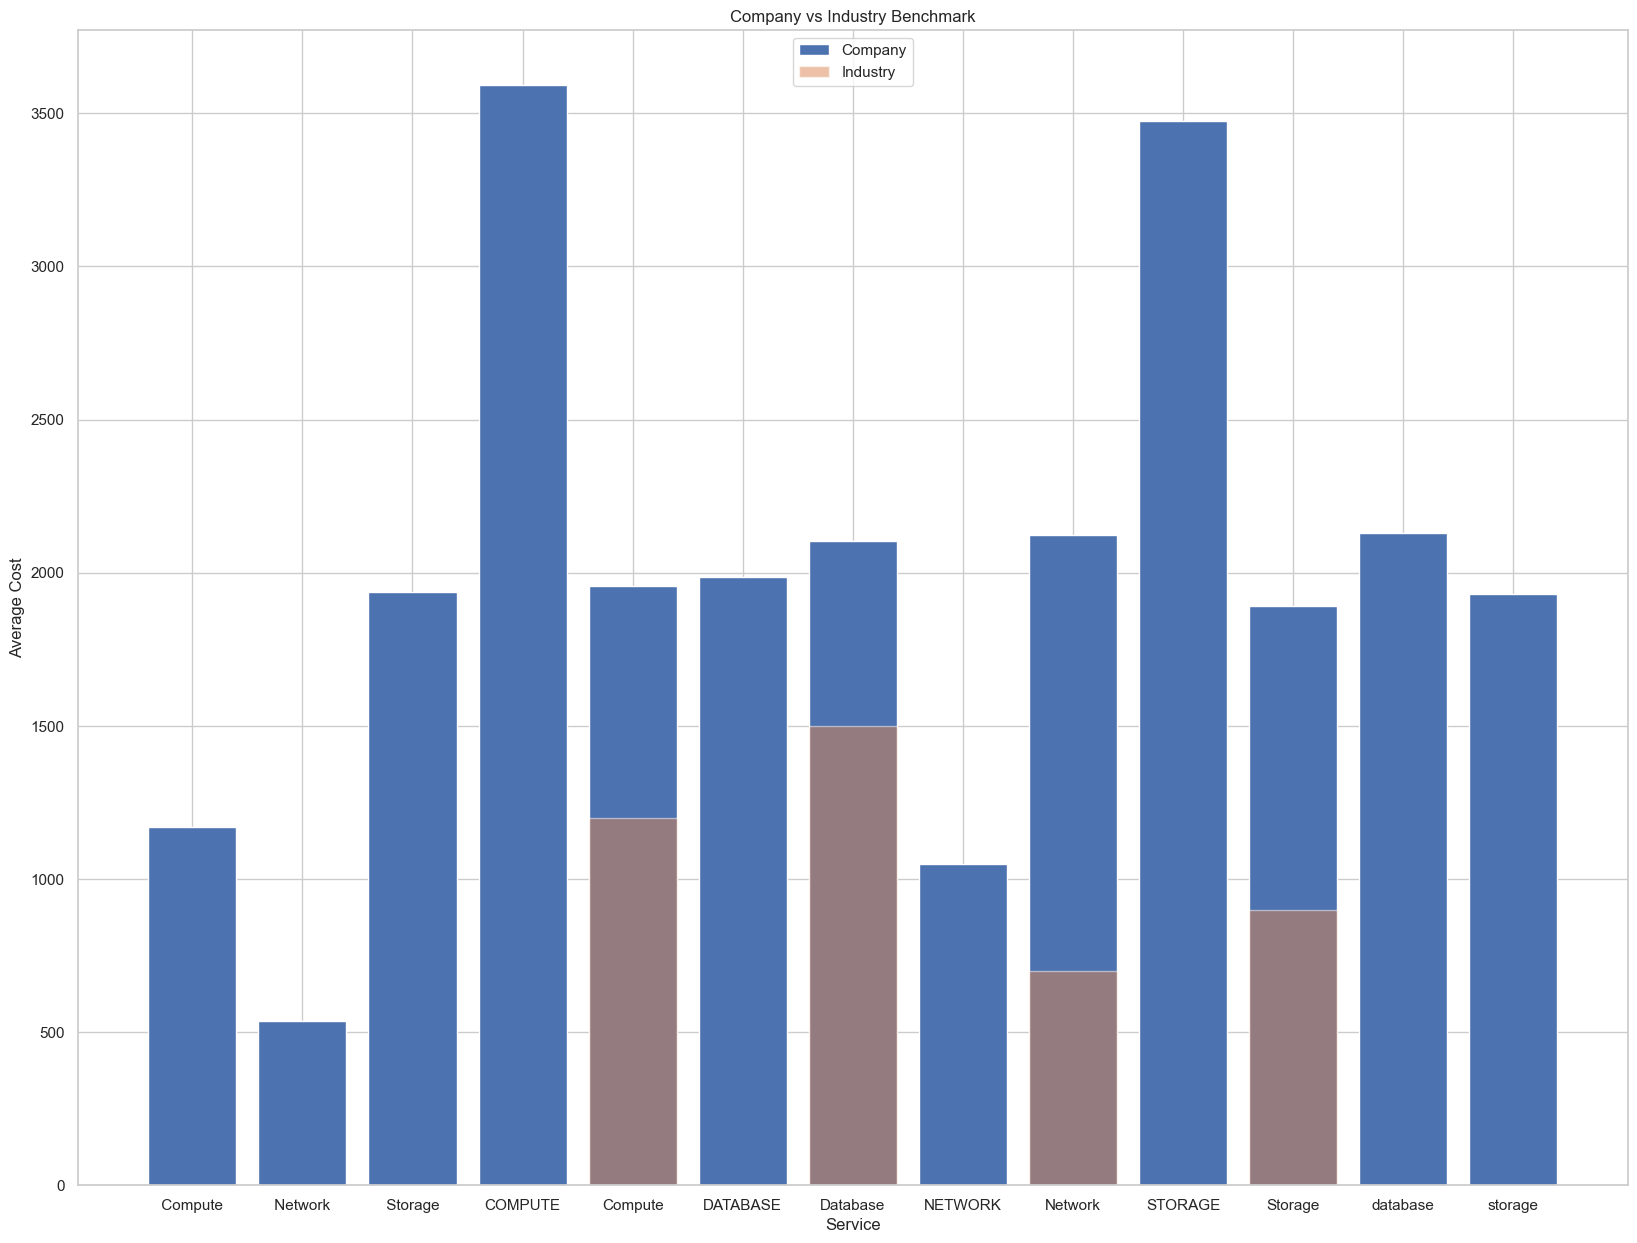

In [143]:
# Matplotlib Visualization
plt.figure(figsize=(20,15))

plt.bar( benchmark["Service"], benchmark["Company_Avg_Cost"], label="Company" )

plt.bar(
    benchmark["Service"],
    benchmark["Industry_Avg_Cost"],
    alpha=0.5,
    label="Industry"
)

plt.xlabel("Service")
plt.ylabel("Average Cost")
plt.title("Company vs Industry Benchmark")
plt.legend()

plt.show()

TC : 15. Support ticket topic clustering and deflection rate.
=================================================================

In [144]:
# Topic Clustering
topic_summary = ( tickets.groupby("Category").size().reset_index(name="Total_Tickets")
           .sort_values("Total_Tickets", ascending=False) )

print(topic_summary)

       Category  Total_Tickets
4         Login             75
6   Performance             71
8       Storage             71
2       Billing             67
0      Storage               6
1       BILLING              2
11      storage              2
7       STORAGE              2
10  performance              2
3         LOGIN              1
5   PERFORMANCE              1
9       billing              1


In [150]:
tickets["Status"] = np.random.choice( ["Self-Service", "Agent"], size=len(tickets),
    p=[0.3, 0.7] )     # 30% self-service, 70% agent)

In [151]:
total_tickets = len(tickets)

deflected = len( tickets[ tickets["Status"] == "Self-Service" ] )

deflection_rate = (
    deflected / total_tickets
) * 100

print(f"Deflection Rate : {deflection_rate:.2f}%")

Deflection Rate : 29.24%


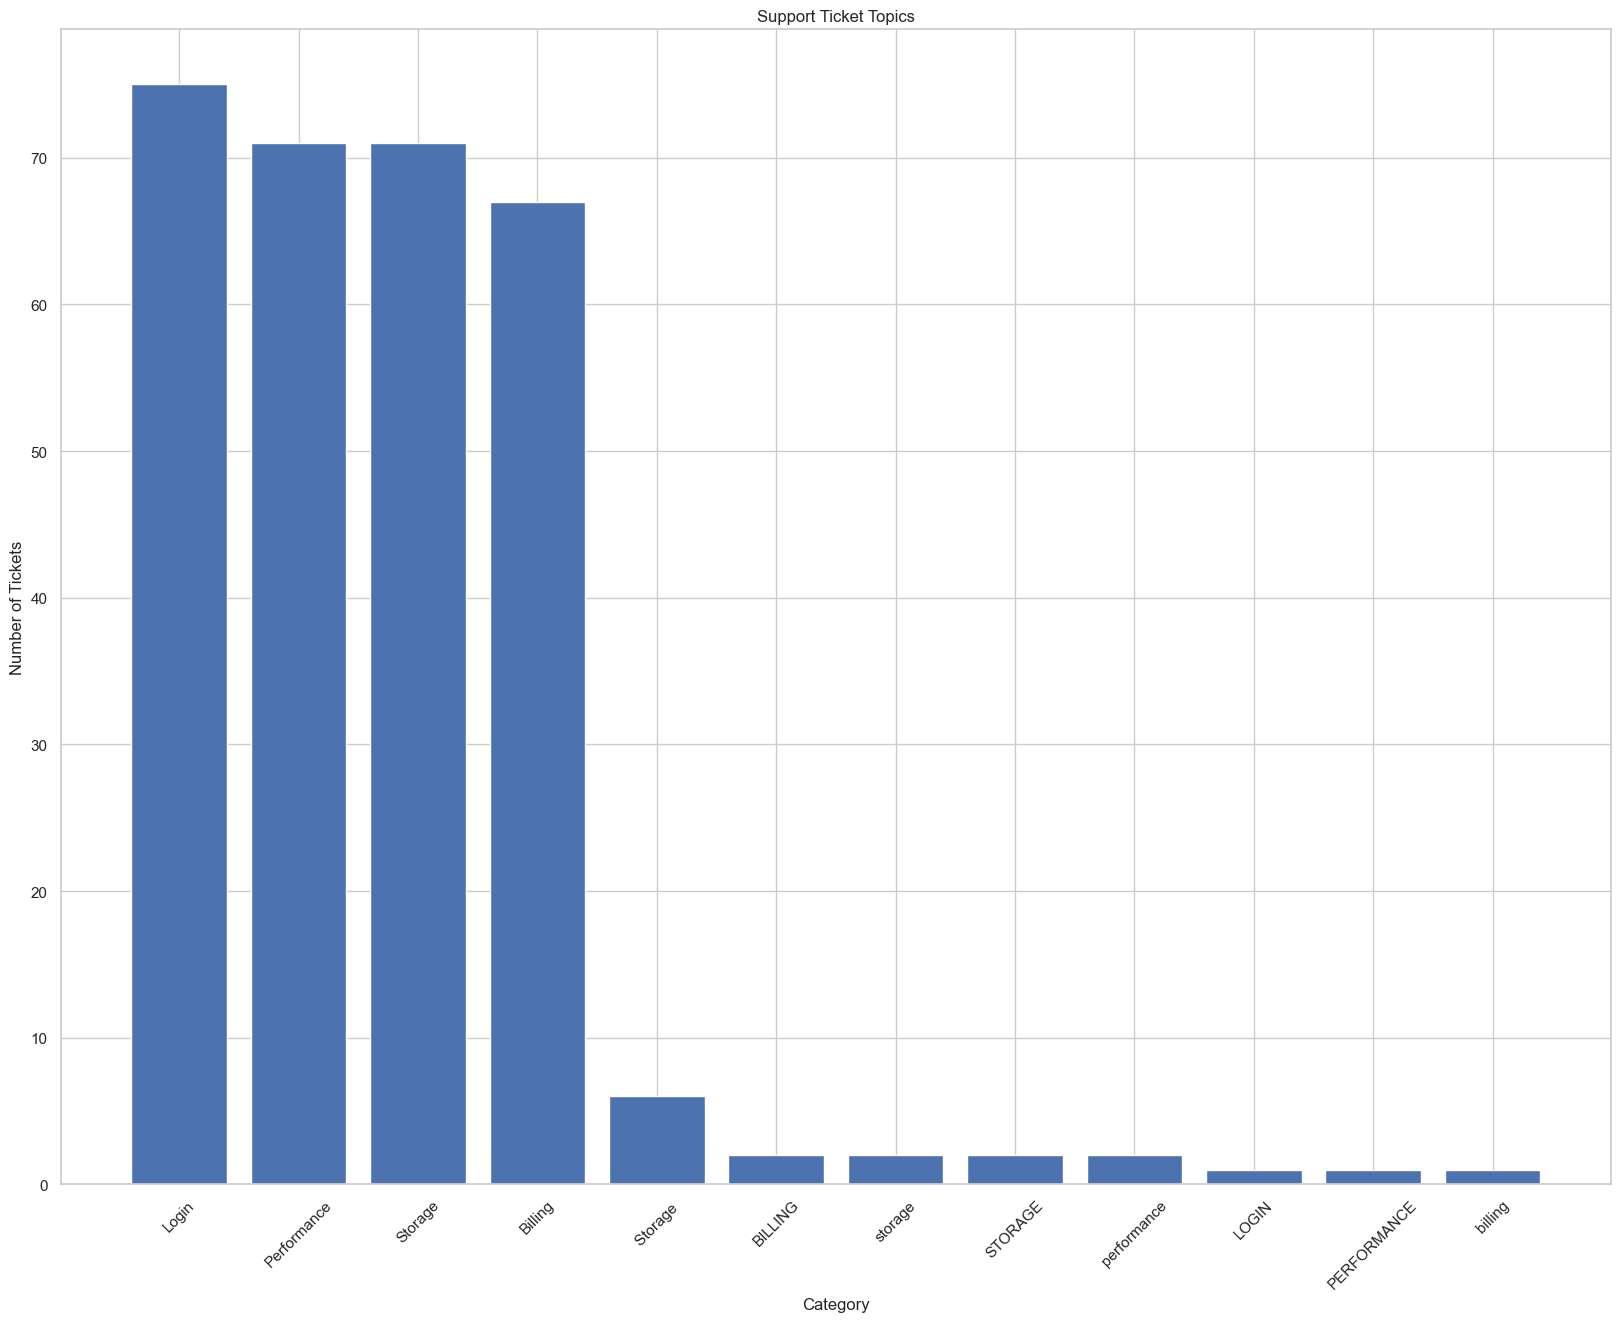

In [152]:
# Plot Topic Distribution (Matplotlib)
plt.figure(figsize=(20,15))

plt.bar( topic_summary["Category"], topic_summary["Total_Tickets"] )

plt.title("Support Ticket Topics")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)

plt.show()

TC : 16. Churn risk signals for SaaS (usage decay).
=========================================================

In [153]:
# Convert Timestamp
billing["TS"] = pd.to_datetime(billing["TS"])

In [154]:
# Calculate Average Usage per Customer
usage_summary = (
    billing.groupby("Account", as_index=False)
           .agg(
               Average_Usage=("Usage", "mean"),
               Total_Cost=("Cost", "sum")
           )
)

print(usage_summary.head())

      Account  Average_Usage  Total_Cost
0   ACCT1011          6719.0      537.52
1   ACCT1029          6817.0     1090.72
2   ACCT1034         30208.0     2416.64
3   ACCT1058           525.0       42.00
4   ACCT1082         47884.0     3830.72


In [155]:
# Create Churn Risk Label
def churn_risk(usage):

    if usage < 100:
        return "High Risk"

    elif usage < 300:
        return "Medium Risk"

    else:
        return "Low Risk"
# Apply the Rule
usage_summary["Churn_Risk"] = (
    usage_summary["Average_Usage"]
    .apply(churn_risk)
)

print(usage_summary.head())

      Account  Average_Usage  Total_Cost Churn_Risk
0   ACCT1011          6719.0      537.52   Low Risk
1   ACCT1029          6817.0     1090.72   Low Risk
2   ACCT1034         30208.0     2416.64   Low Risk
3   ACCT1058           525.0       42.00   Low Risk
4   ACCT1082         47884.0     3830.72   Low Risk


In [156]:
# Count Customers in Each Risk Group
risk_summary = (
    usage_summary["Churn_Risk"]
    .value_counts()
)

print(risk_summary)

Churn_Risk
Low Risk    110
Name: count, dtype: int64


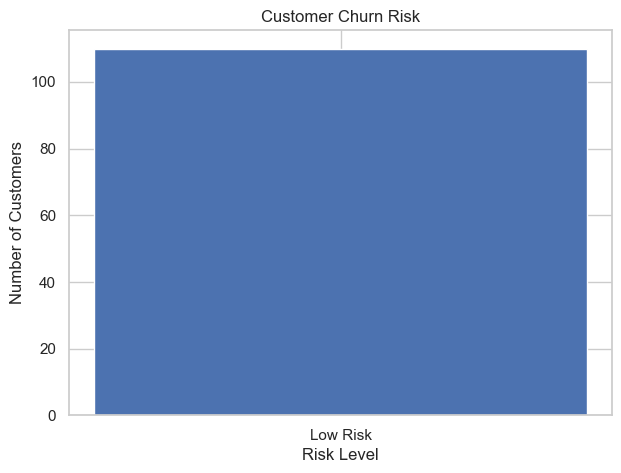

In [157]:
# Visualization
plt.figure(figsize=(7,5))

plt.bar(
    risk_summary.index,
    risk_summary.values
)

plt.title("Customer Churn Risk")

plt.xlabel("Risk Level")

plt.ylabel("Number of Customers")

plt.show()

TF : 17. Unit economics per product (gross margin proxy).
===============================================================

In [158]:
billing["Cost"] = (
    billing["Cost"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("$", "", regex=False)
)

billing["Cost"] = pd.to_numeric(
    billing["Cost"],
    errors="coerce"
)

In [159]:
service_summary = (
    billing.groupby("Service", as_index=False)
           .agg(
               Revenue=("Cost", "sum"),
               Total_Usage=("Usage", "sum")
           )
)

print(service_summary)

      Service    Revenue  Total_Usage
0    Compute     3507.36        43842
1    Network      537.52         6719
2    Storage     3872.72        48409
3     COMPUTE    3591.68        44896
4     Compute  432073.04      5400913
5    DATABASE    5962.16        74527
6    Database  528249.36      6603117
7     NETWORK    1050.48        13131
8     Network  537429.76      6717872
9     STORAGE    3474.88        43436
10    Storage  490172.48      6127156
11   database    6389.44        79868
12    storage    3862.64        48283


In [ ]:
service_summary["Operating_Cost"] = (
    service_summary["Revenue"] * 0.70
)

service_summary["Gross_Margin"] = (
    service_summary["Revenue"] - service_summary["Operating_Cost"] )

In [162]:
service_summary["Gross_Margin_%"] = (
    service_summary["Gross_Margin"]
    / service_summary["Revenue"]
) * 100

service_summary["Gross_Margin_%"] = (
    service_summary["Gross_Margin_%"]
    .round(2)
)

print(service_summary)

      Service    Revenue  Total_Usage  Operating_Cost  Gross_Margin  \
0    Compute     3507.36        43842        2455.152      1052.208   
1    Network      537.52         6719         376.264       161.256   
2    Storage     3872.72        48409        2710.904      1161.816   
3     COMPUTE    3591.68        44896        2514.176      1077.504   
4     Compute  432073.04      5400913      302451.128    129621.912   
5    DATABASE    5962.16        74527        4173.512      1788.648   
6    Database  528249.36      6603117      369774.552    158474.808   
7     NETWORK    1050.48        13131         735.336       315.144   
8     Network  537429.76      6717872      376200.832    161228.928   
9     STORAGE    3474.88        43436        2432.416      1042.464   
10    Storage  490172.48      6127156      343120.736    147051.744   
11   database    6389.44        79868        4472.608      1916.832   
12    storage    3862.64        48283        2703.848      1158.792   

    G

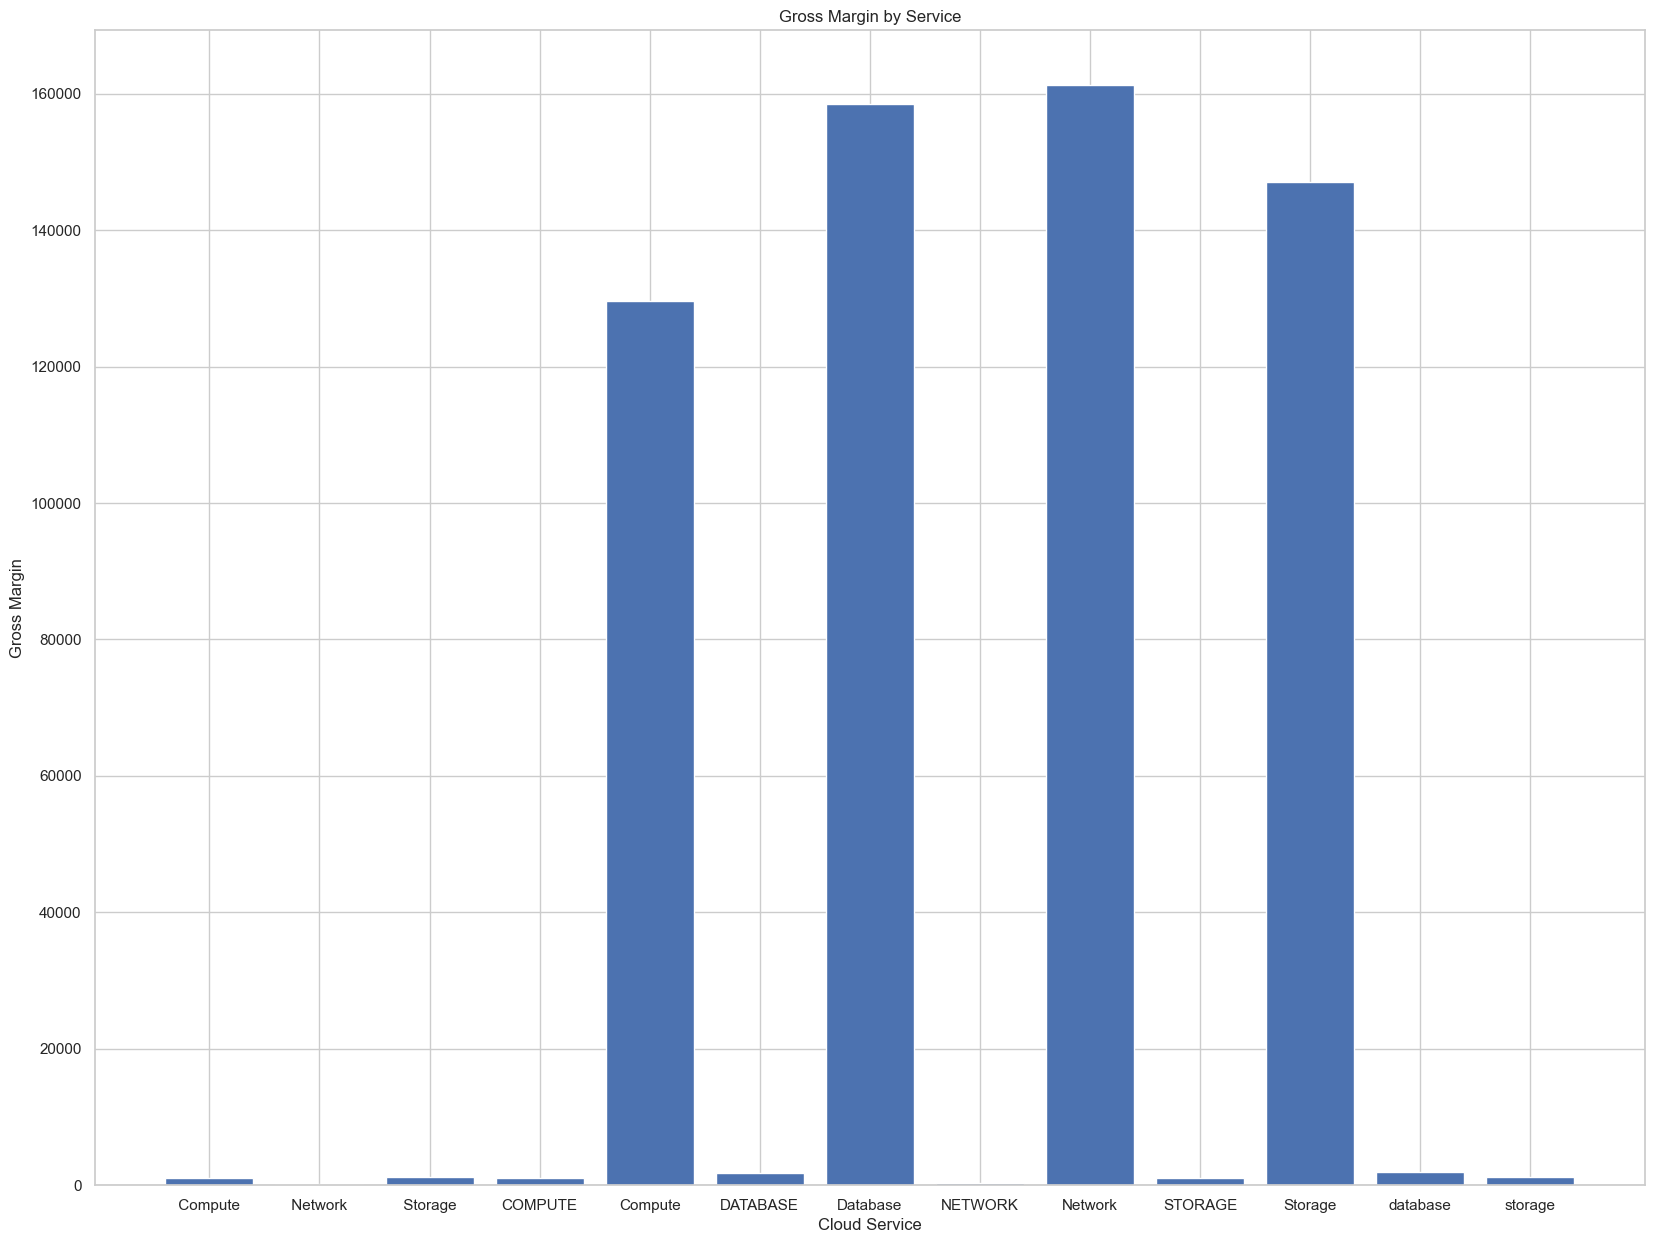

In [164]:
plt.figure(figsize=(20,15))

plt.bar(
    service_summary["Service"],
    service_summary["Gross_Margin"]
)

plt.title("Gross Margin by Service")

plt.xlabel("Cloud Service")

plt.ylabel("Gross Margin")

plt.show()

TF : 18. Multi‑cloud consolidation view.
========================================

In [165]:
providers = ["AWS", "Azure", "GCP"]

billing["Cloud_Provider"] = np.random.choice(
    providers,
    size=len(billing)
)

print(billing[["Account","Cloud_Provider"]].head())

      Account Cloud_Provider
0    ACCT1082            AWS
1   ACCT1029             GCP
2    acct1055            AWS
3    ACCT1065            AWS
4   ACCT1058           Azure


In [166]:
cloud_summary = (
    billing.groupby("Cloud_Provider", as_index=False)
           .agg(
               Total_Cost=("Cost","sum"),
               Total_Usage=("Usage","sum"),
               Total_Accounts=("Account","nunique")
           )
)

print(cloud_summary)

  Cloud_Provider  Total_Cost  Total_Usage  Total_Accounts
0            AWS   698775.28      8734691              98
1          Azure   686786.48      8584831             102
2            GCP   634611.76      7932647              96


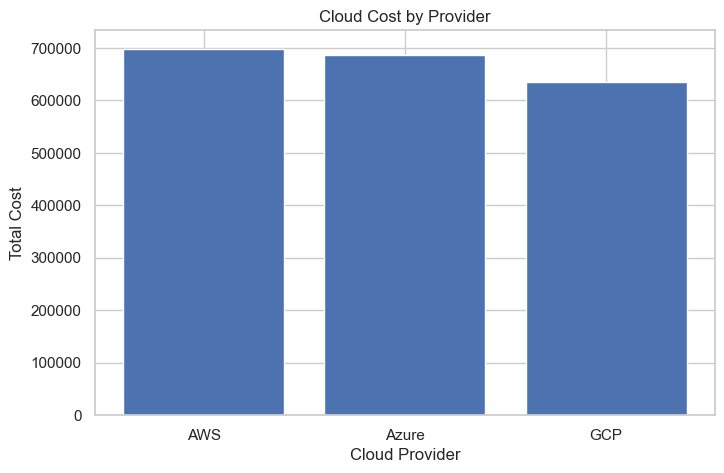

In [167]:
plt.figure(figsize=(8,5))

plt.bar(
    cloud_summary["Cloud_Provider"],
    cloud_summary["Total_Cost"]
)

plt.title("Cloud Cost by Provider")

plt.xlabel("Cloud Provider")

plt.ylabel("Total Cost")

plt.show()

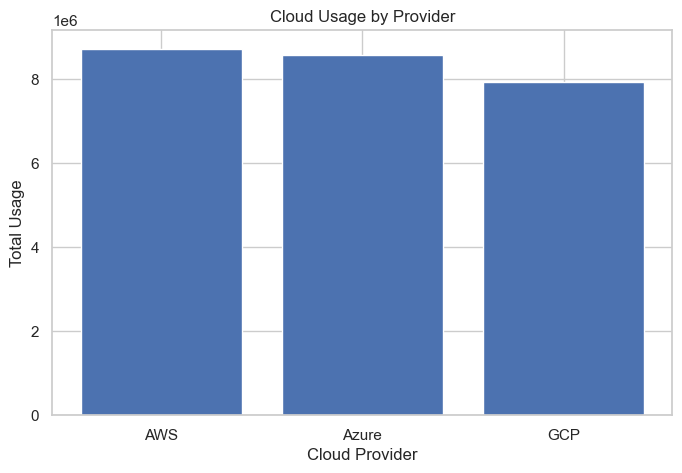

In [168]:
plt.figure(figsize=(8,5))

plt.bar(
    cloud_summary["Cloud_Provider"],
    cloud_summary["Total_Usage"]
)

plt.title("Cloud Usage by Provider")

plt.xlabel("Cloud Provider")

plt.ylabel("Total Usage")

plt.show()

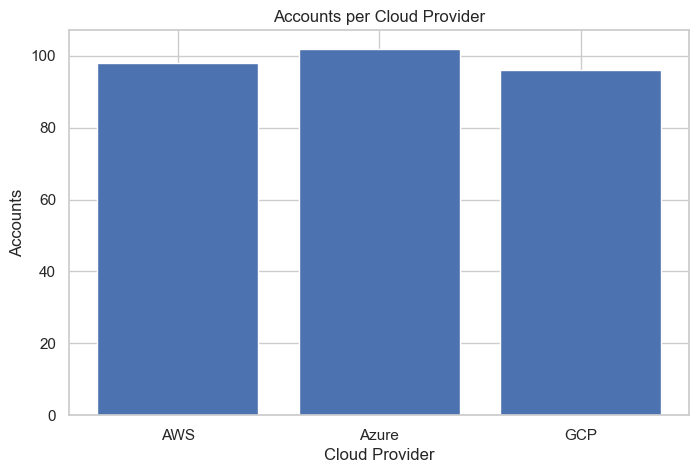

In [169]:
plt.figure(figsize=(8,5))

plt.bar(
    cloud_summary["Cloud_Provider"],
    cloud_summary["Total_Accounts"]
)

plt.title("Accounts per Cloud Provider")

plt.xlabel("Cloud Provider")

plt.ylabel("Accounts")

plt.show()

TF : 19. Security event correlation counts (from SIEM) joined to costs.
=============================================================================

In [170]:
security_count = (
    security.groupby("Resource_ID")
            .size()
            .reset_index(name="Security_Events")
)

print(security_count.head())

  Resource_ID  Security_Events
0    VM100001                1
1    VM100002                2
2    VM100003                1
3    VM100004                2
4    VM100005                5


In [171]:
cost_summary = (
    billing.groupby("Resource_ID", as_index=False)
           .agg(
               Total_Cost=("Cost", "sum")
           )
)

print(cost_summary.head())

  Resource_ID  Total_Cost
0    VM100001    13560.96
1    VM100003     8236.72
2    VM100004    11652.00
3    VM100005     5363.44
4    VM100006     2367.68


In [172]:
# Merge Billing and Security Logs
security_cost = pd.merge(
    cost_summary,
    security_count,
    on="Resource_ID",
    how="left"
)

security_cost["Security_Events"] = security_cost["Security_Events"].fillna(0)

print(security_cost.head())

  Resource_ID  Total_Cost  Security_Events
0    VM100001    13560.96              1.0
1    VM100003     8236.72              1.0
2    VM100004    11652.00              2.0
3    VM100005     5363.44              5.0
4    VM100006     2367.68              2.0


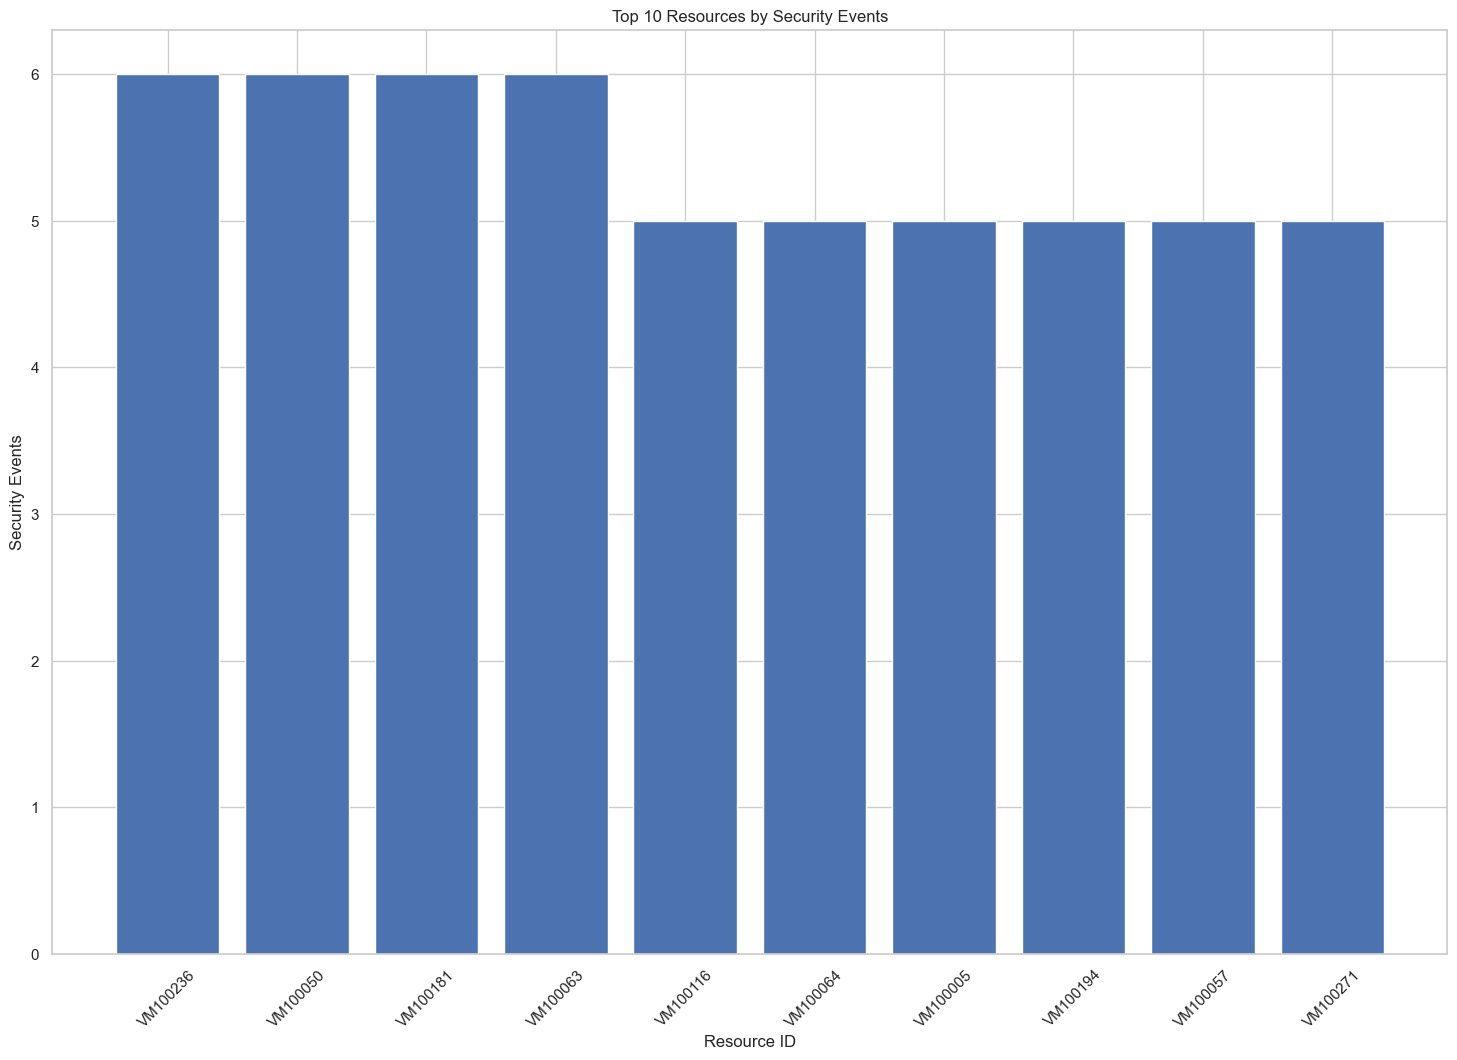

In [174]:
# Security Events by Resource

# Top 10 resources
top10 = security_cost.sort_values(
    by="Security_Events",
    ascending=False
).head(10)

plt.figure(figsize=(18,12))

plt.bar(top10["Resource_ID"], top10["Security_Events"])

plt.title("Top 10 Resources by Security Events")
plt.xlabel("Resource ID")
plt.ylabel("Security Events")

plt.xticks(rotation=45)

plt.show()

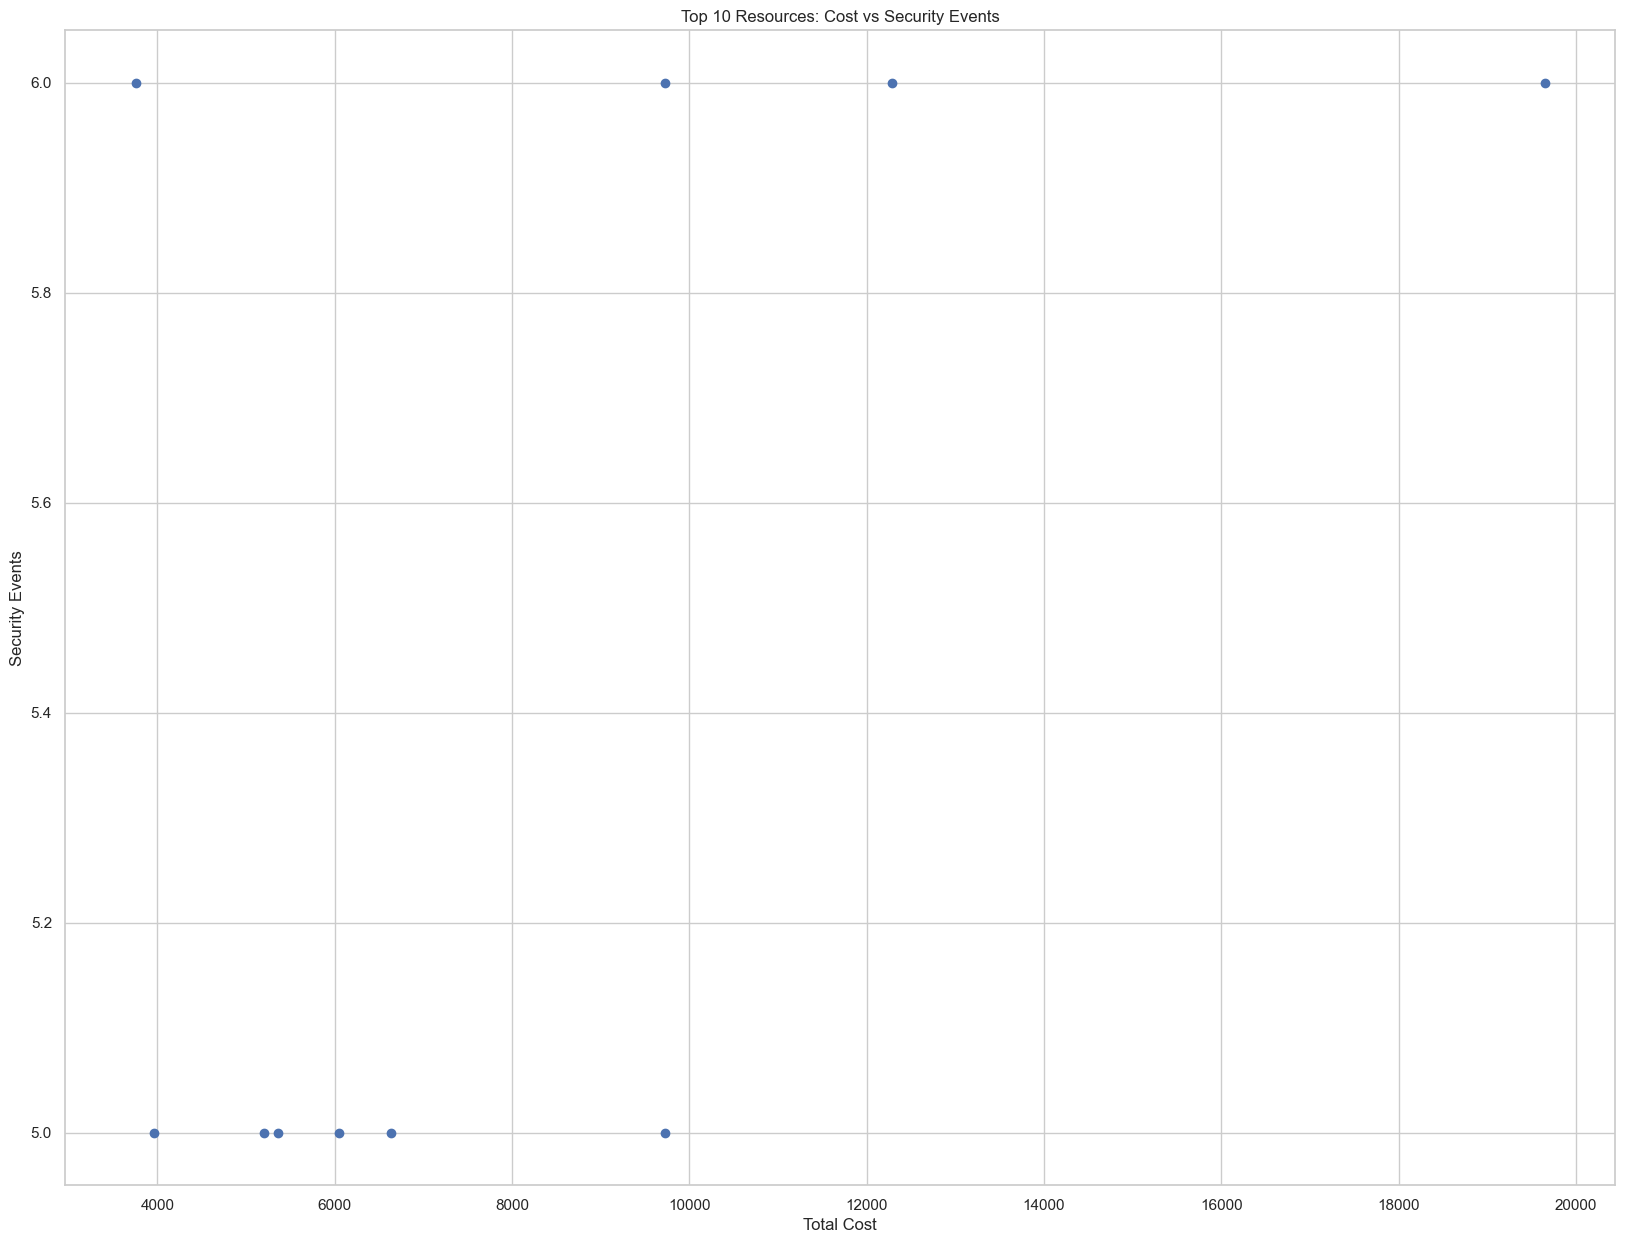

In [175]:
# Cost vs Security Events

# Top 10 resources by Security Events
top10 = security_cost.nlargest(10, "Security_Events")

plt.figure(figsize=(20,15))

plt.scatter(
    top10["Total_Cost"],
    top10["Security_Events"]
)

plt.title("Top 10 Resources: Cost vs Security Events")
plt.xlabel("Total Cost")
plt.ylabel("Security Events")

plt.show()

TF : 20. Public dashboard extracts (privacy‑safe).
====================================================

In [176]:
# Create Public Dashboard Dataset
public_dashboard = (
    billing.groupby("Service", as_index=False)
           .agg(
               Total_Usage=("Usage", "sum"),
               Total_Cost=("Cost", "sum")
           )
)

print(public_dashboard.head())

     Service  Total_Usage  Total_Cost
0   Compute         43842     3507.36
1   Network          6719      537.52
2   Storage         48409     3872.72
3    COMPUTE        44896     3591.68
4    Compute      5400913   432073.04


In [177]:
public_dashboard.to_csv(
    "Public_Dashboard.csv",
    index=False
)

In [178]:
top10 = (
    public_dashboard
    .sort_values("Total_Cost", ascending=False)
    .head(10)
)

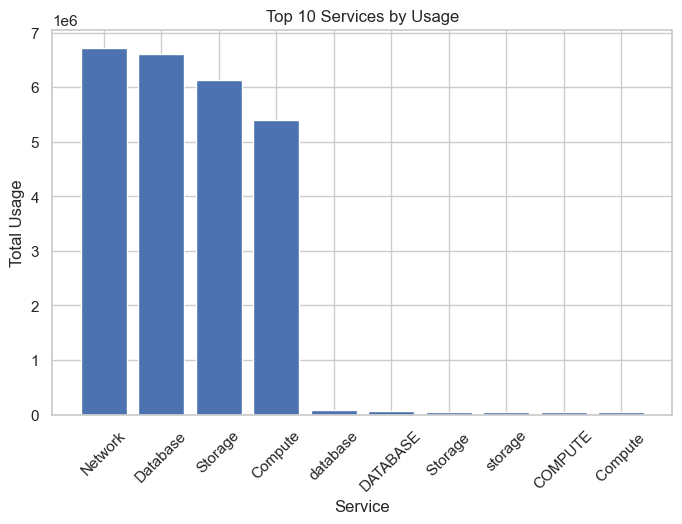

In [179]:
top10_service = (
    public_dashboard
    .sort_values(by="Total_Usage", ascending=False)
    .head(10)
)

plt.figure(figsize=(8,5))

plt.bar(
    top10_service["Service"],
    top10_service["Total_Usage"]
)

plt.title("Top 10 Services by Usage")
plt.xlabel("Service")
plt.ylabel("Total Usage")

plt.xticks(rotation=45)

plt.show()